In [1]:
import pandas as pd

# CSVファイルをインポート
df = pd.read_csv('data/20250208_FSW_GT86/20250208_FSW(mts)_GT86.csv')
df.head()

,Corr Dist,Corr Dist (Unstretched),Corr Speed,ABS Active,ABS Enabled,AID Allow Tire Blankets,AID Auto Blip,AID Auto Clutch,AID Auto Shift,AID Fuel Rate,...,Toe In FR,Toe In RL,Toe In RR,Turbo Boost,Wheel Angular Speed FL,Wheel Angular Speed FR,Wheel Angular Speed RL,Wheel Angular Speed RR,Wind Direction,Wind Speed
0,0,0,185.9,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,0.016,0.2691,0.2712,0.0,164.27,164.24,167.20,167.20,-158,0
1,1,1,186.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,0.018,0.2565,0.2630,0.0,164.30,164.28,167.08,167.08,-158,0
2,2,2,186.1,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,0.061,0.2532,0.2607,0.0,164.34,164.30,167.21,167.21,-158,0
3,3,3,186.1,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,0.082,0.2609,0.2601,0.0,164.39,164.35,167.50,167.50,-158,0
4,3,3,186.2,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,0.086,0.2712,0.2631,0.0,164.42,164.40,167.76,167.76,-158,0


In [2]:
df.columns.tolist()

['Corr Dist',
 'Corr Dist (Unstretched)',
 'Corr Speed',
 'ABS Active',
 'ABS Enabled',
 'AID Allow Tire Blankets',
 'AID Auto Blip',
 'AID Auto Clutch',
 'AID Auto Shift',
 'AID Fuel Rate',
 'AID Ideal Line',
 'AID Mech Damage',
 'AID Stability',
 'AID Tire Wear Rate',
 'Air Density',
 'Air Temp',
 'Ballast',
 'Best Lap Delta',
 'Best Lap Time',
 'Brake Bias',
 'Brake Pos',
 'Brake Temp FL',
 'Brake Temp FR',
 'Brake Temp RL',
 'Brake Temp RR',
 'CG Accel Lateral',
 'CG Accel Longitudinal',
 'CG Accel Vertical',
 'CG Height',
 'Camber FL',
 'Camber FR',
 'Camber RL',
 'Camber RR',
 'Car Coord X',
 'Car Coord Y',
 'Car Coord Z',
 'Car Damage Front',
 'Car Damage Left',
 'Car Damage Rear',
 'Car Damage Right',
 'Car Pos Norm',
 'Caster FL',
 'Caster FR',
 'Chassis Pitch Angle',
 'Chassis Pitch Rate',
 'Chassis Roll Angle',
 'Chassis Roll Rate',
 'Chassis Velocity X',
 'Chassis Velocity Y',
 'Chassis Velocity Z',
 'Chassis Yaw Rate',
 'Clutch Pos',
 'DRS Active',
 'DRS Available',
 'Driv

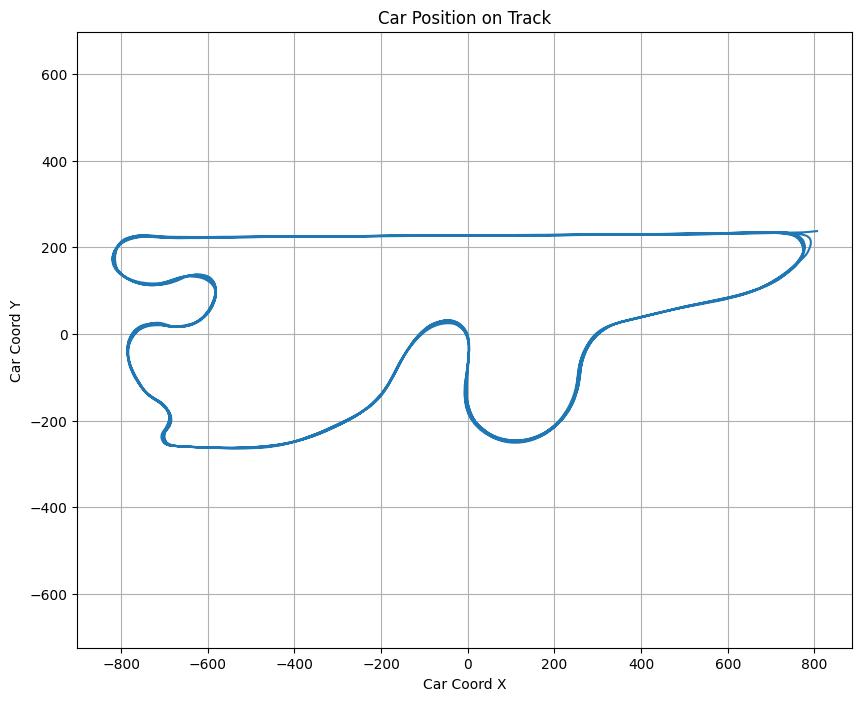

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
plt.plot(df['Car Coord X'], df['Car Coord Y'])
plt.xlabel('Car Coord X')
plt.ylabel('Car Coord Y')
plt.title('Car Position on Track')
plt.axis('equal')
plt.grid(True)
plt.show()

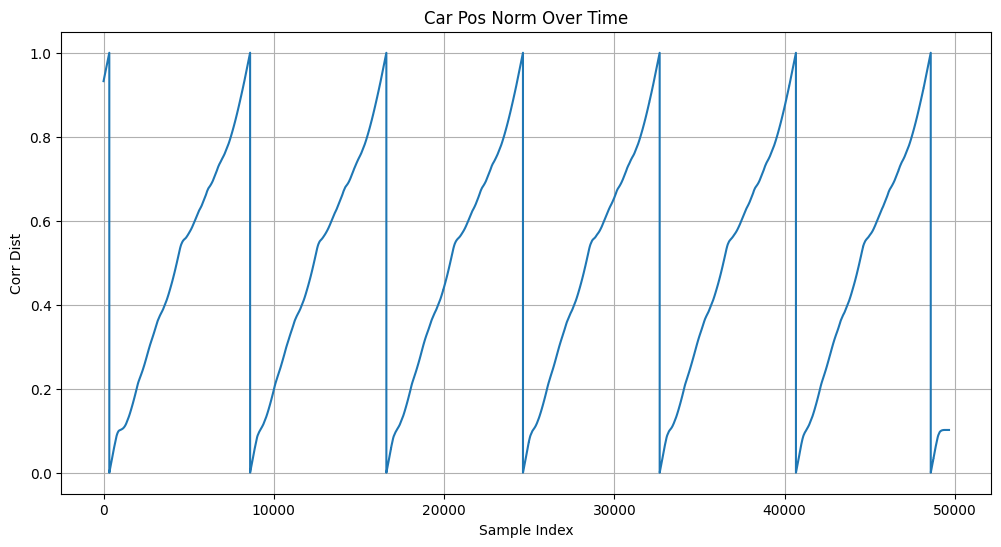

In [4]:
plt.figure(figsize=(12, 6))
plt.plot(df['Car Pos Norm'])
plt.xlabel('Sample Index')
plt.ylabel('Corr Dist')
plt.title('Car Pos Norm Over Time')
plt.grid(True)
plt.show()

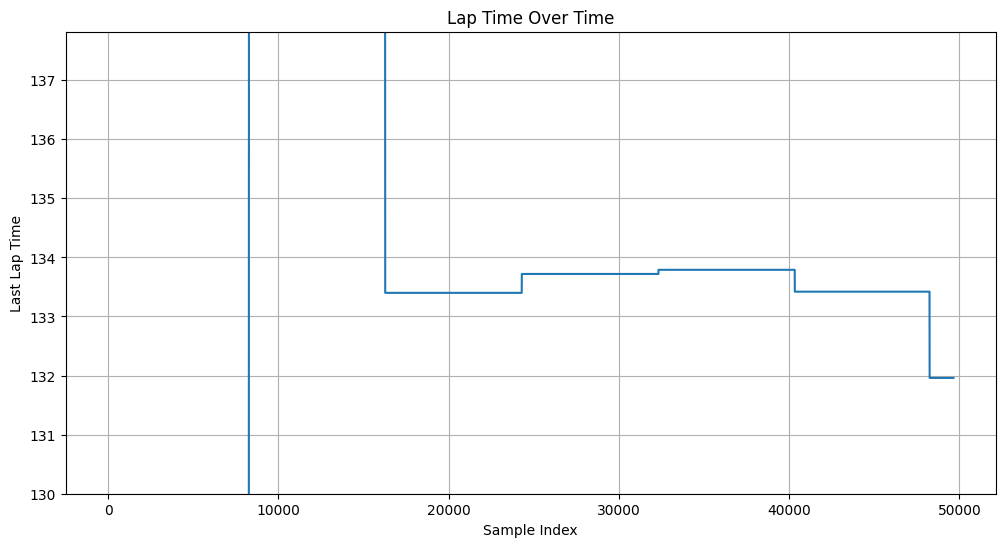

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(df["Last Lap Time"])
plt.xlabel("Sample Index")
plt.ylabel("Last Lap Time")
plt.ylim(130, df["Last Lap Time"].max())
plt.title("Lap Time Over Time")
plt.grid(True)
plt.show()

In [6]:
# Get unique values from Last Lap Time column and display them
unique_lap_times = df['Last Lap Time'].unique()
print(f"Number of unique lap times: {len(unique_lap_times)}")
print("\nUnique lap times:")
print(sorted(unique_lap_times))

Number of unique lap times: 8

Unique lap times:
[np.float64(0.0), np.float64(131.96), np.float64(133.4), np.float64(133.42), np.float64(133.72), np.float64(133.79), np.float64(137.82), np.float64(nan)]


In [7]:
# Last Lap Timeの変化点でラップ境界を検出し、ラップごとに分割
lap_change = df['Last Lap Time'].ne(df['Last Lap Time'].shift()).cumsum()
laps = {f"Lap {i}": group.reset_index(drop=True) for i, (_, group) in enumerate(df.groupby(lap_change), 1)}

print(f"ラップ数: {len(laps)}")
for name, lap_df in laps.items():
    lap_time = lap_df['Last Lap Time'].iloc[-1]
    print(f"  {name}: {len(lap_df)} rows, Last Lap Time = {lap_time}")

ラップ数: 8
  Lap 1: 8268 rows, Last Lap Time = 0.0
  Lap 2: 8005 rows, Last Lap Time = 137.82
  Lap 3: 8022 rows, Last Lap Time = 133.4
  Lap 4: 8028 rows, Last Lap Time = 133.72
  Lap 5: 8005 rows, Last Lap Time = 133.79
  Lap 6: 7917 rows, Last Lap Time = 133.42
  Lap 7: 1409 rows, Last Lap Time = 131.96
  Lap 8: 1 rows, Last Lap Time = nan


In [8]:
df = laps["Lap 6"][200:2200]

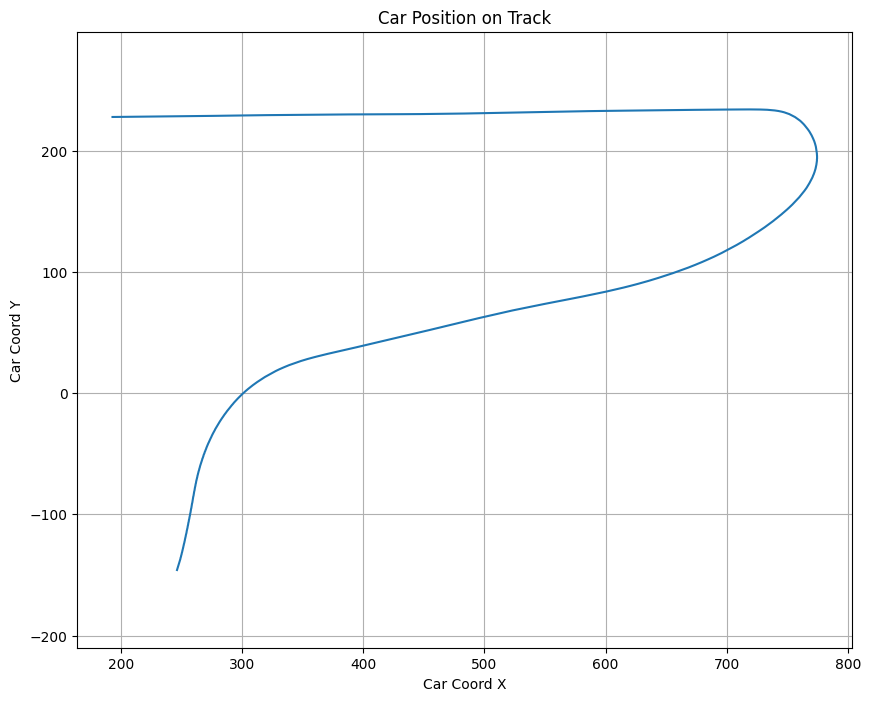

In [9]:
plt.figure(figsize=(10, 8))
plt.plot(df['Car Coord X'], df['Car Coord Y'])
plt.xlabel('Car Coord X')
plt.ylabel('Car Coord Y')
plt.title('Car Position on Track')
plt.axis('equal')
plt.grid(True)
plt.show()

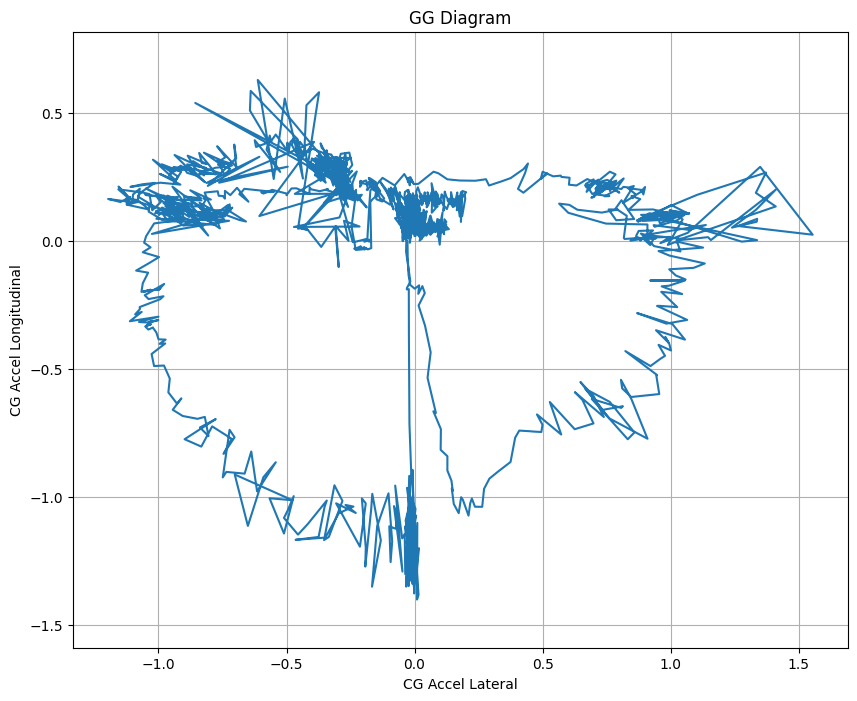

In [10]:
plt.figure(figsize=(10, 8))
plt.plot(df['CG Accel Lateral'], df['CG Accel Longitudinal'])
plt.xlabel('CG Accel Lateral')
plt.ylabel('CG Accel Longitudinal')
plt.title('GG Diagram')
plt.axis('equal')
plt.grid(True)
plt.show()

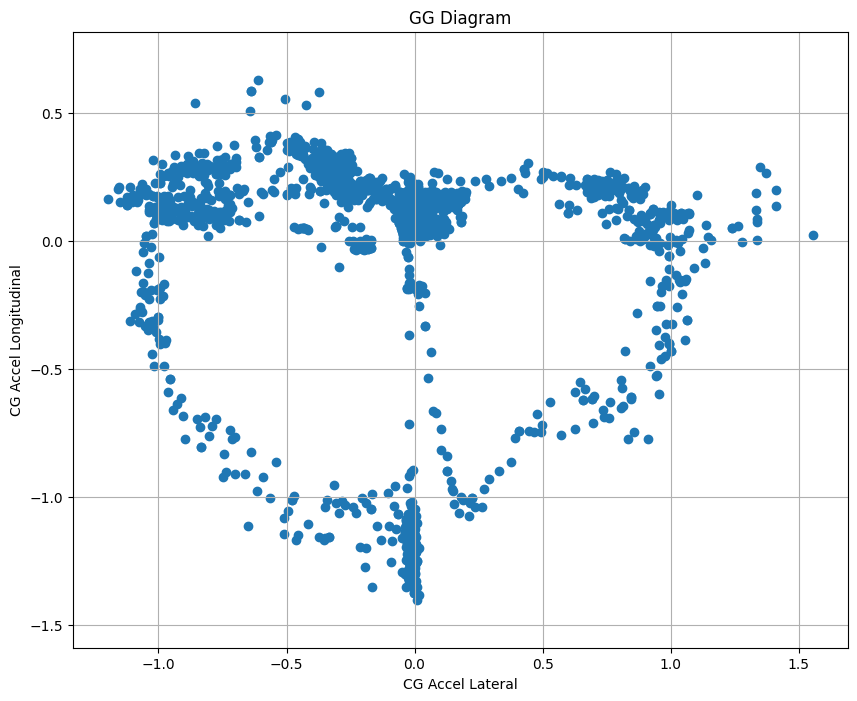

In [11]:
plt.figure(figsize=(10, 8))
plt.scatter(df['CG Accel Lateral'], df['CG Accel Longitudinal'])
plt.xlabel('CG Accel Lateral')
plt.ylabel('CG Accel Longitudinal')
plt.title('GG Diagram')
plt.axis('equal')
plt.grid(True)
plt.show()

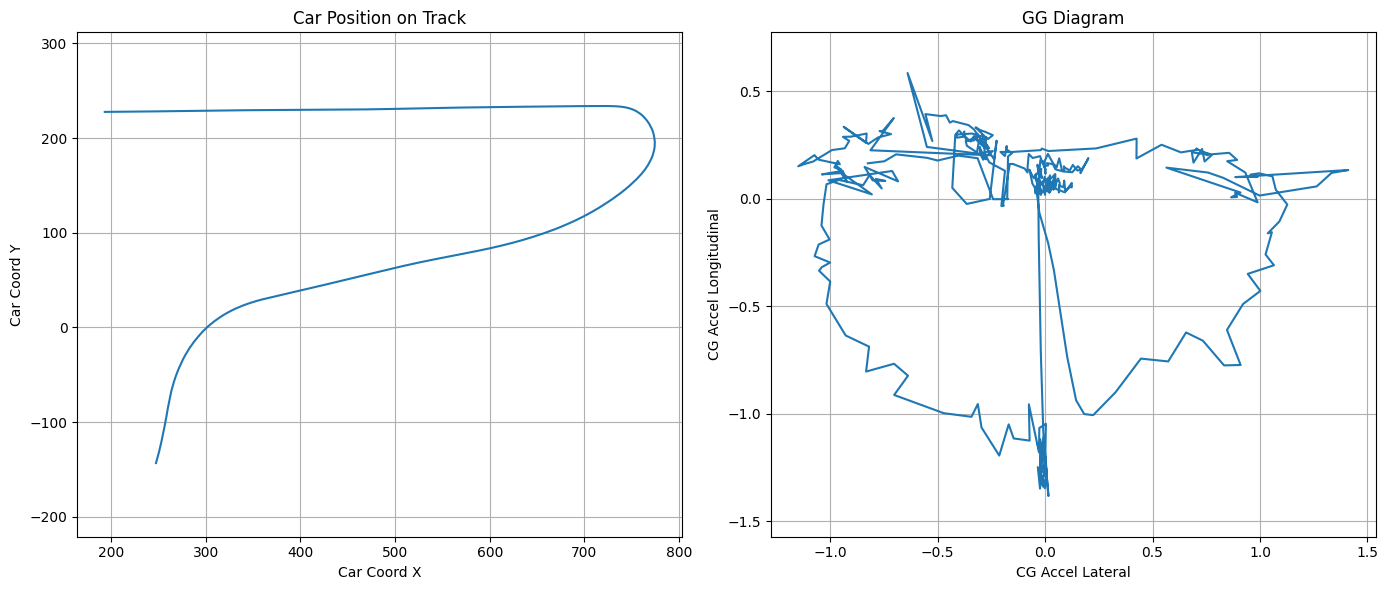

In [12]:
df = laps["Lap 6"][200:2200:5]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(df['Car Coord X'], df['Car Coord Y'])
axes[0].set_xlabel('Car Coord X')
axes[0].set_ylabel('Car Coord Y')
axes[0].set_title('Car Position on Track')
axes[0].axis('equal')
axes[0].grid(True)

axes[1].plot(df['CG Accel Lateral'], df['CG Accel Longitudinal'])
axes[1].set_xlabel('CG Accel Lateral')
axes[1].set_ylabel('CG Accel Longitudinal')
axes[1].set_title('GG Diagram')
axes[1].axis('equal')
axes[1].grid(True)

plt.tight_layout()
plt.show()

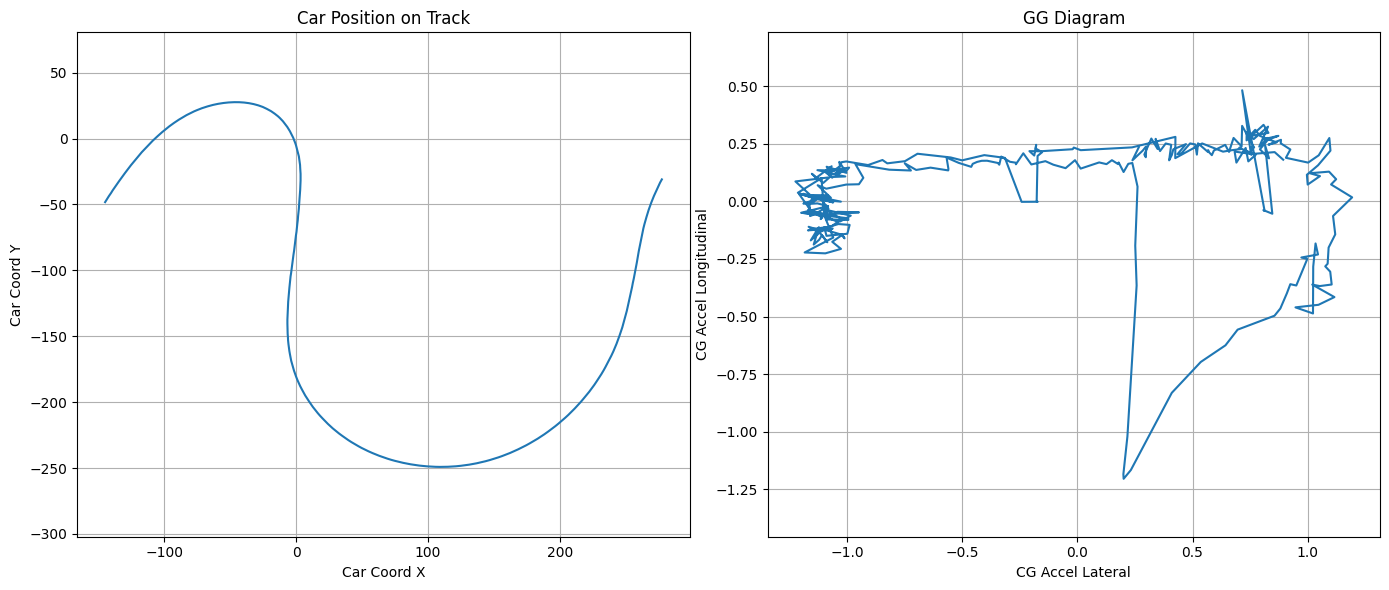

In [13]:
df = laps["Lap 6"][2000:3500:5]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(df['Car Coord X'], df['Car Coord Y'])
axes[0].set_xlabel('Car Coord X')
axes[0].set_ylabel('Car Coord Y')
axes[0].set_title('Car Position on Track')
axes[0].axis('equal')
axes[0].grid(True)

axes[1].plot(df['CG Accel Lateral'], df['CG Accel Longitudinal'])
axes[1].set_xlabel('CG Accel Lateral')
axes[1].set_ylabel('CG Accel Longitudinal')
axes[1].set_title('GG Diagram')
axes[1].axis('equal')
axes[1].grid(True)

plt.tight_layout()
plt.show()

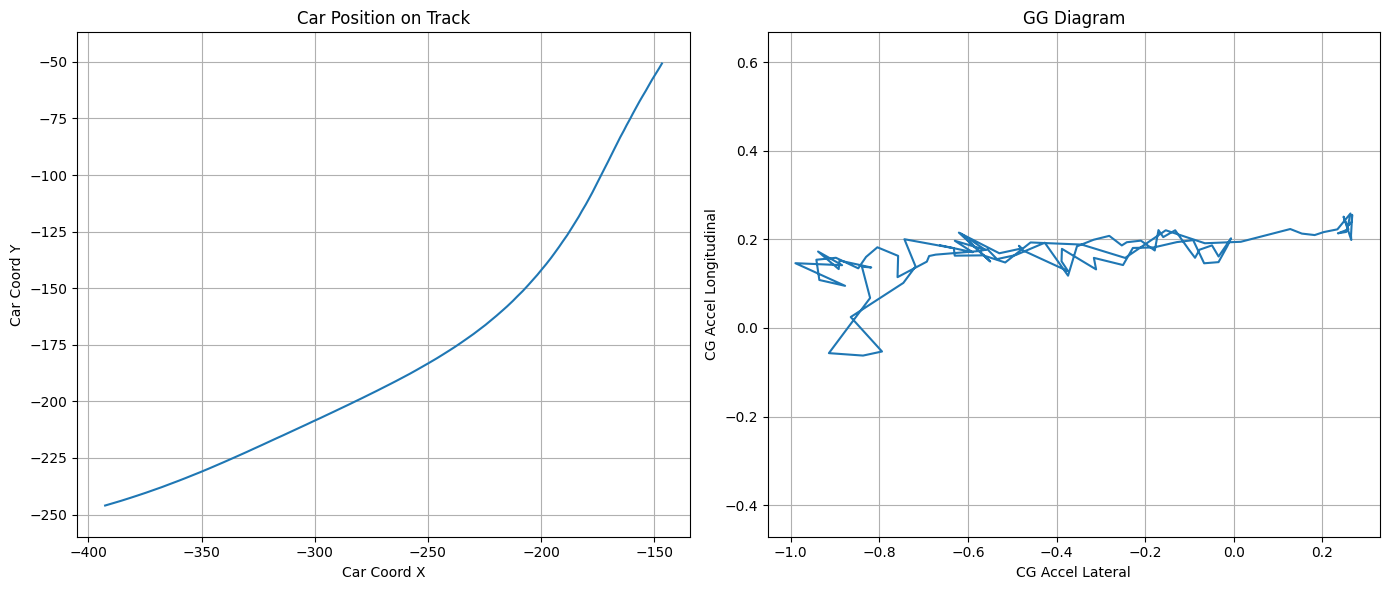

In [14]:
df = laps["Lap 6"][3500:4000:5]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(df['Car Coord X'], df['Car Coord Y'])
axes[0].set_xlabel('Car Coord X')
axes[0].set_ylabel('Car Coord Y')
axes[0].set_title('Car Position on Track')
axes[0].axis('equal')
axes[0].grid(True)

axes[1].plot(df['CG Accel Lateral'], df['CG Accel Longitudinal'])
axes[1].set_xlabel('CG Accel Lateral')
axes[1].set_ylabel('CG Accel Longitudinal')
axes[1].set_title('GG Diagram')
axes[1].axis('equal')
axes[1].grid(True)

plt.tight_layout()
plt.show()

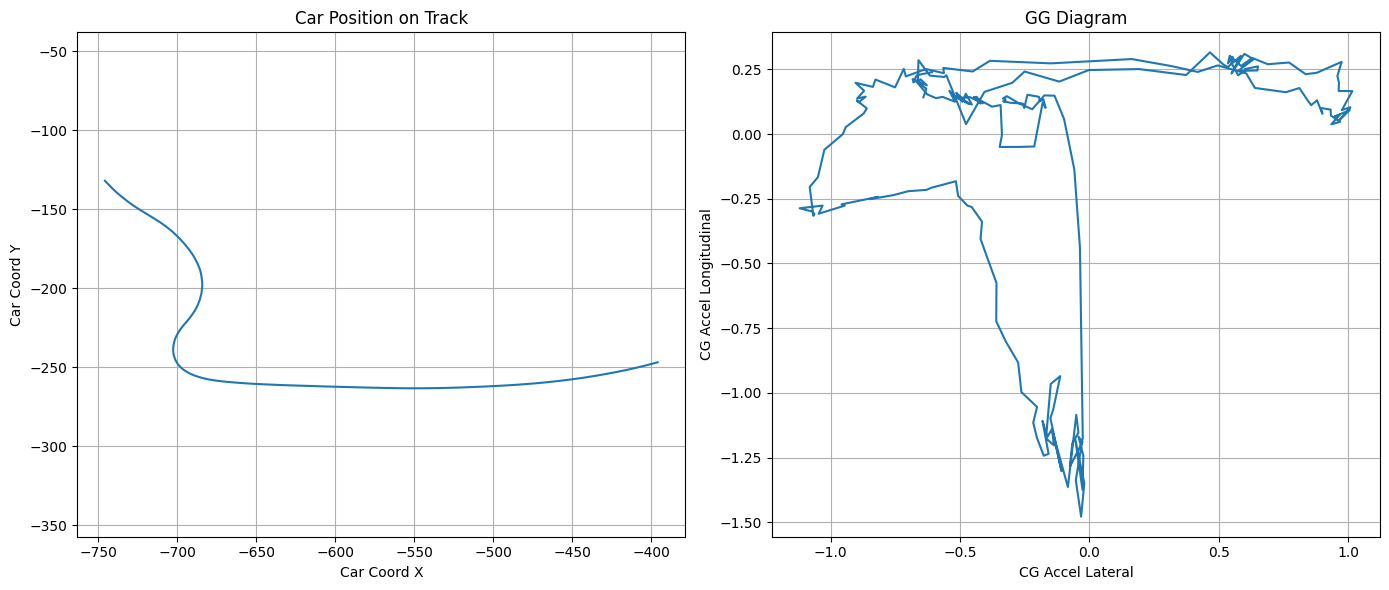

In [15]:
df = laps["Lap 6"][4000:5000:5]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(df['Car Coord X'], df['Car Coord Y'])
axes[0].set_xlabel('Car Coord X')
axes[0].set_ylabel('Car Coord Y')
axes[0].set_title('Car Position on Track')
axes[0].axis('equal')
axes[0].grid(True)

axes[1].plot(df['CG Accel Lateral'], df['CG Accel Longitudinal'])
axes[1].set_xlabel('CG Accel Lateral')
axes[1].set_ylabel('CG Accel Longitudinal')
axes[1].set_title('GG Diagram')
axes[1].axis('equal')
axes[1].grid(True)

plt.tight_layout()
plt.show()

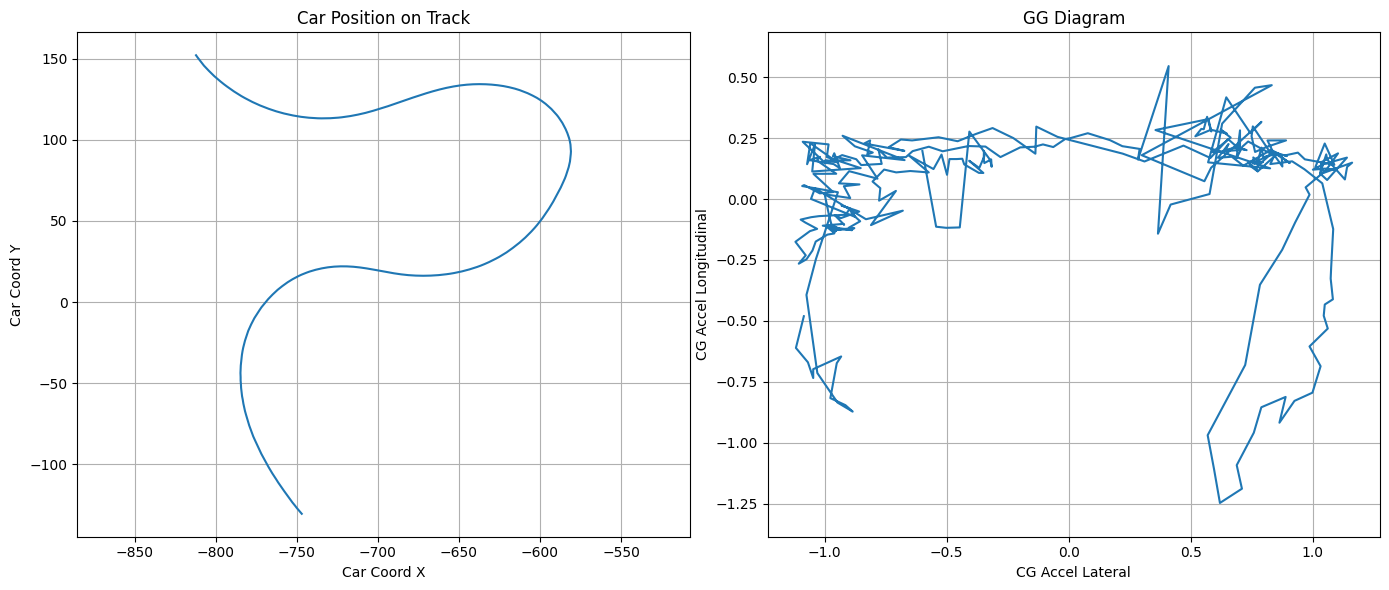

In [16]:
df = laps["Lap 6"][5000:6500:5]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(df['Car Coord X'], df['Car Coord Y'])
axes[0].set_xlabel('Car Coord X')
axes[0].set_ylabel('Car Coord Y')
axes[0].set_title('Car Position on Track')
axes[0].axis('equal')
axes[0].grid(True)

axes[1].plot(df['CG Accel Lateral'], df['CG Accel Longitudinal'])
axes[1].set_xlabel('CG Accel Lateral')
axes[1].set_ylabel('CG Accel Longitudinal')
axes[1].set_title('GG Diagram')
axes[1].axis('equal')
axes[1].grid(True)

plt.tight_layout()
plt.show()

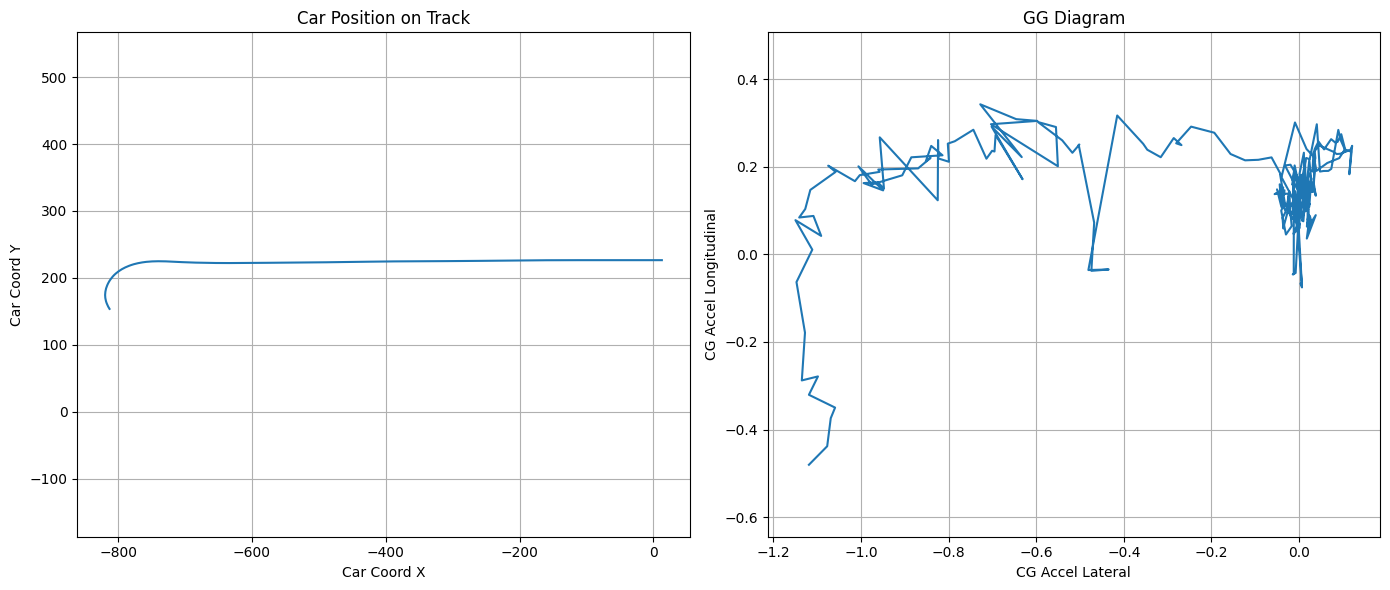

In [17]:
df = laps["Lap 6"][6500:8000:5]
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(df['Car Coord X'], df['Car Coord Y'])
axes[0].set_xlabel('Car Coord X')
axes[0].set_ylabel('Car Coord Y')
axes[0].set_title('Car Position on Track')
axes[0].axis('equal')
axes[0].grid(True)

axes[1].plot(df['CG Accel Lateral'], df['CG Accel Longitudinal'])
axes[1].set_xlabel('CG Accel Lateral')
axes[1].set_ylabel('CG Accel Longitudinal')
axes[1].set_title('GG Diagram')
axes[1].axis('equal')
axes[1].grid(True)

plt.tight_layout()
plt.show()

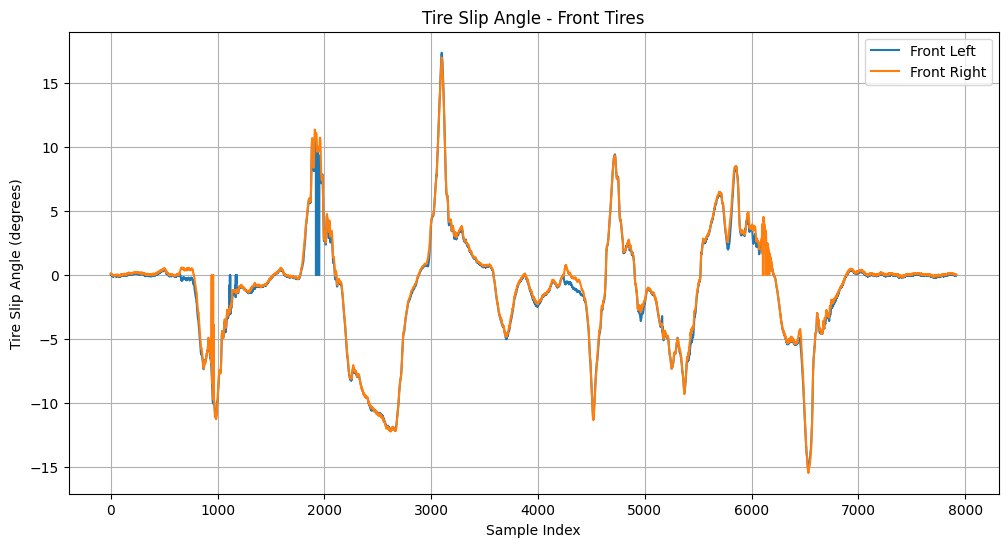

In [18]:
df6 = laps["Lap 6"]
plt.figure(figsize=(12, 6))
plt.plot(df6['Tire Slip Angle FL'], label='Front Left')
plt.plot(df6['Tire Slip Angle FR'], label='Front Right')
plt.xlabel('Sample Index')
plt.ylabel('Tire Slip Angle (degrees)')
plt.title('Tire Slip Angle - Front Tires')
plt.legend()
plt.grid(True)
plt.show()

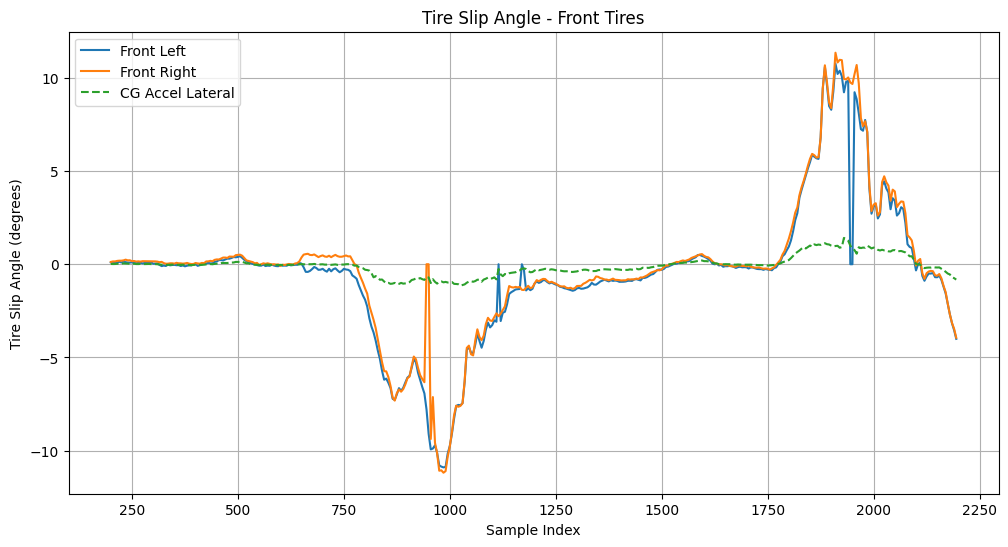

In [19]:
df = laps["Lap 6"][200:2200:5]
plt.figure(figsize=(12, 6))
plt.plot(df['Tire Slip Angle FL'], label='Front Left')
plt.plot(df['Tire Slip Angle FR'], label='Front Right')
plt.plot(df['CG Accel Lateral'], label='CG Accel Lateral', linestyle='--')
plt.xlabel('Sample Index')
plt.ylabel('Tire Slip Angle (degrees)')
plt.title('Tire Slip Angle - Front Tires')
plt.legend()
plt.grid(True)
plt.show()

分析対象: Lap 6 (Time: 133.42s)


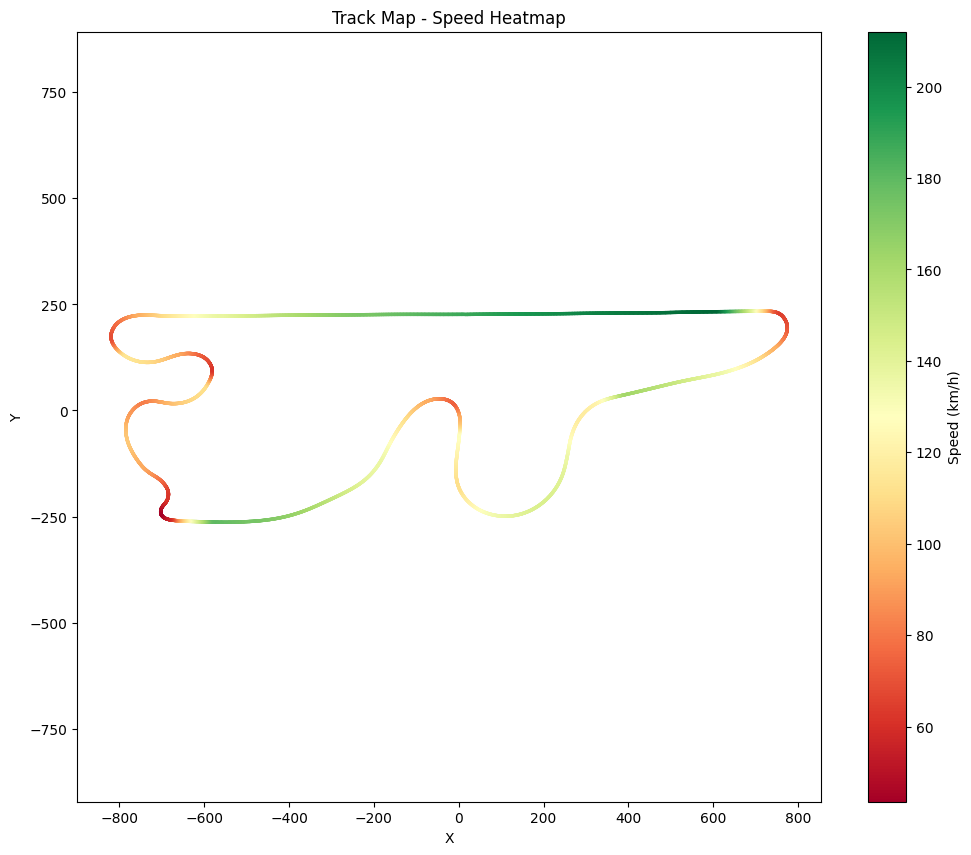

In [20]:
import numpy as np

df6 = laps["Lap 6"]
print(f"分析対象: Lap 6 (Time: {df6['Last Lap Time'].iloc[-1]:.2f}s)")

# トラックマップ + 速度ヒートマップ
fig, ax = plt.subplots(figsize=(12, 10))
scatter = ax.scatter(df6['Car Coord X'], df6['Car Coord Y'],
                     c=df6['Corr Speed'], cmap='RdYlGn', s=2)
plt.colorbar(scatter, label='Speed (km/h)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Track Map - Speed Heatmap')
ax.axis('equal')
plt.show()

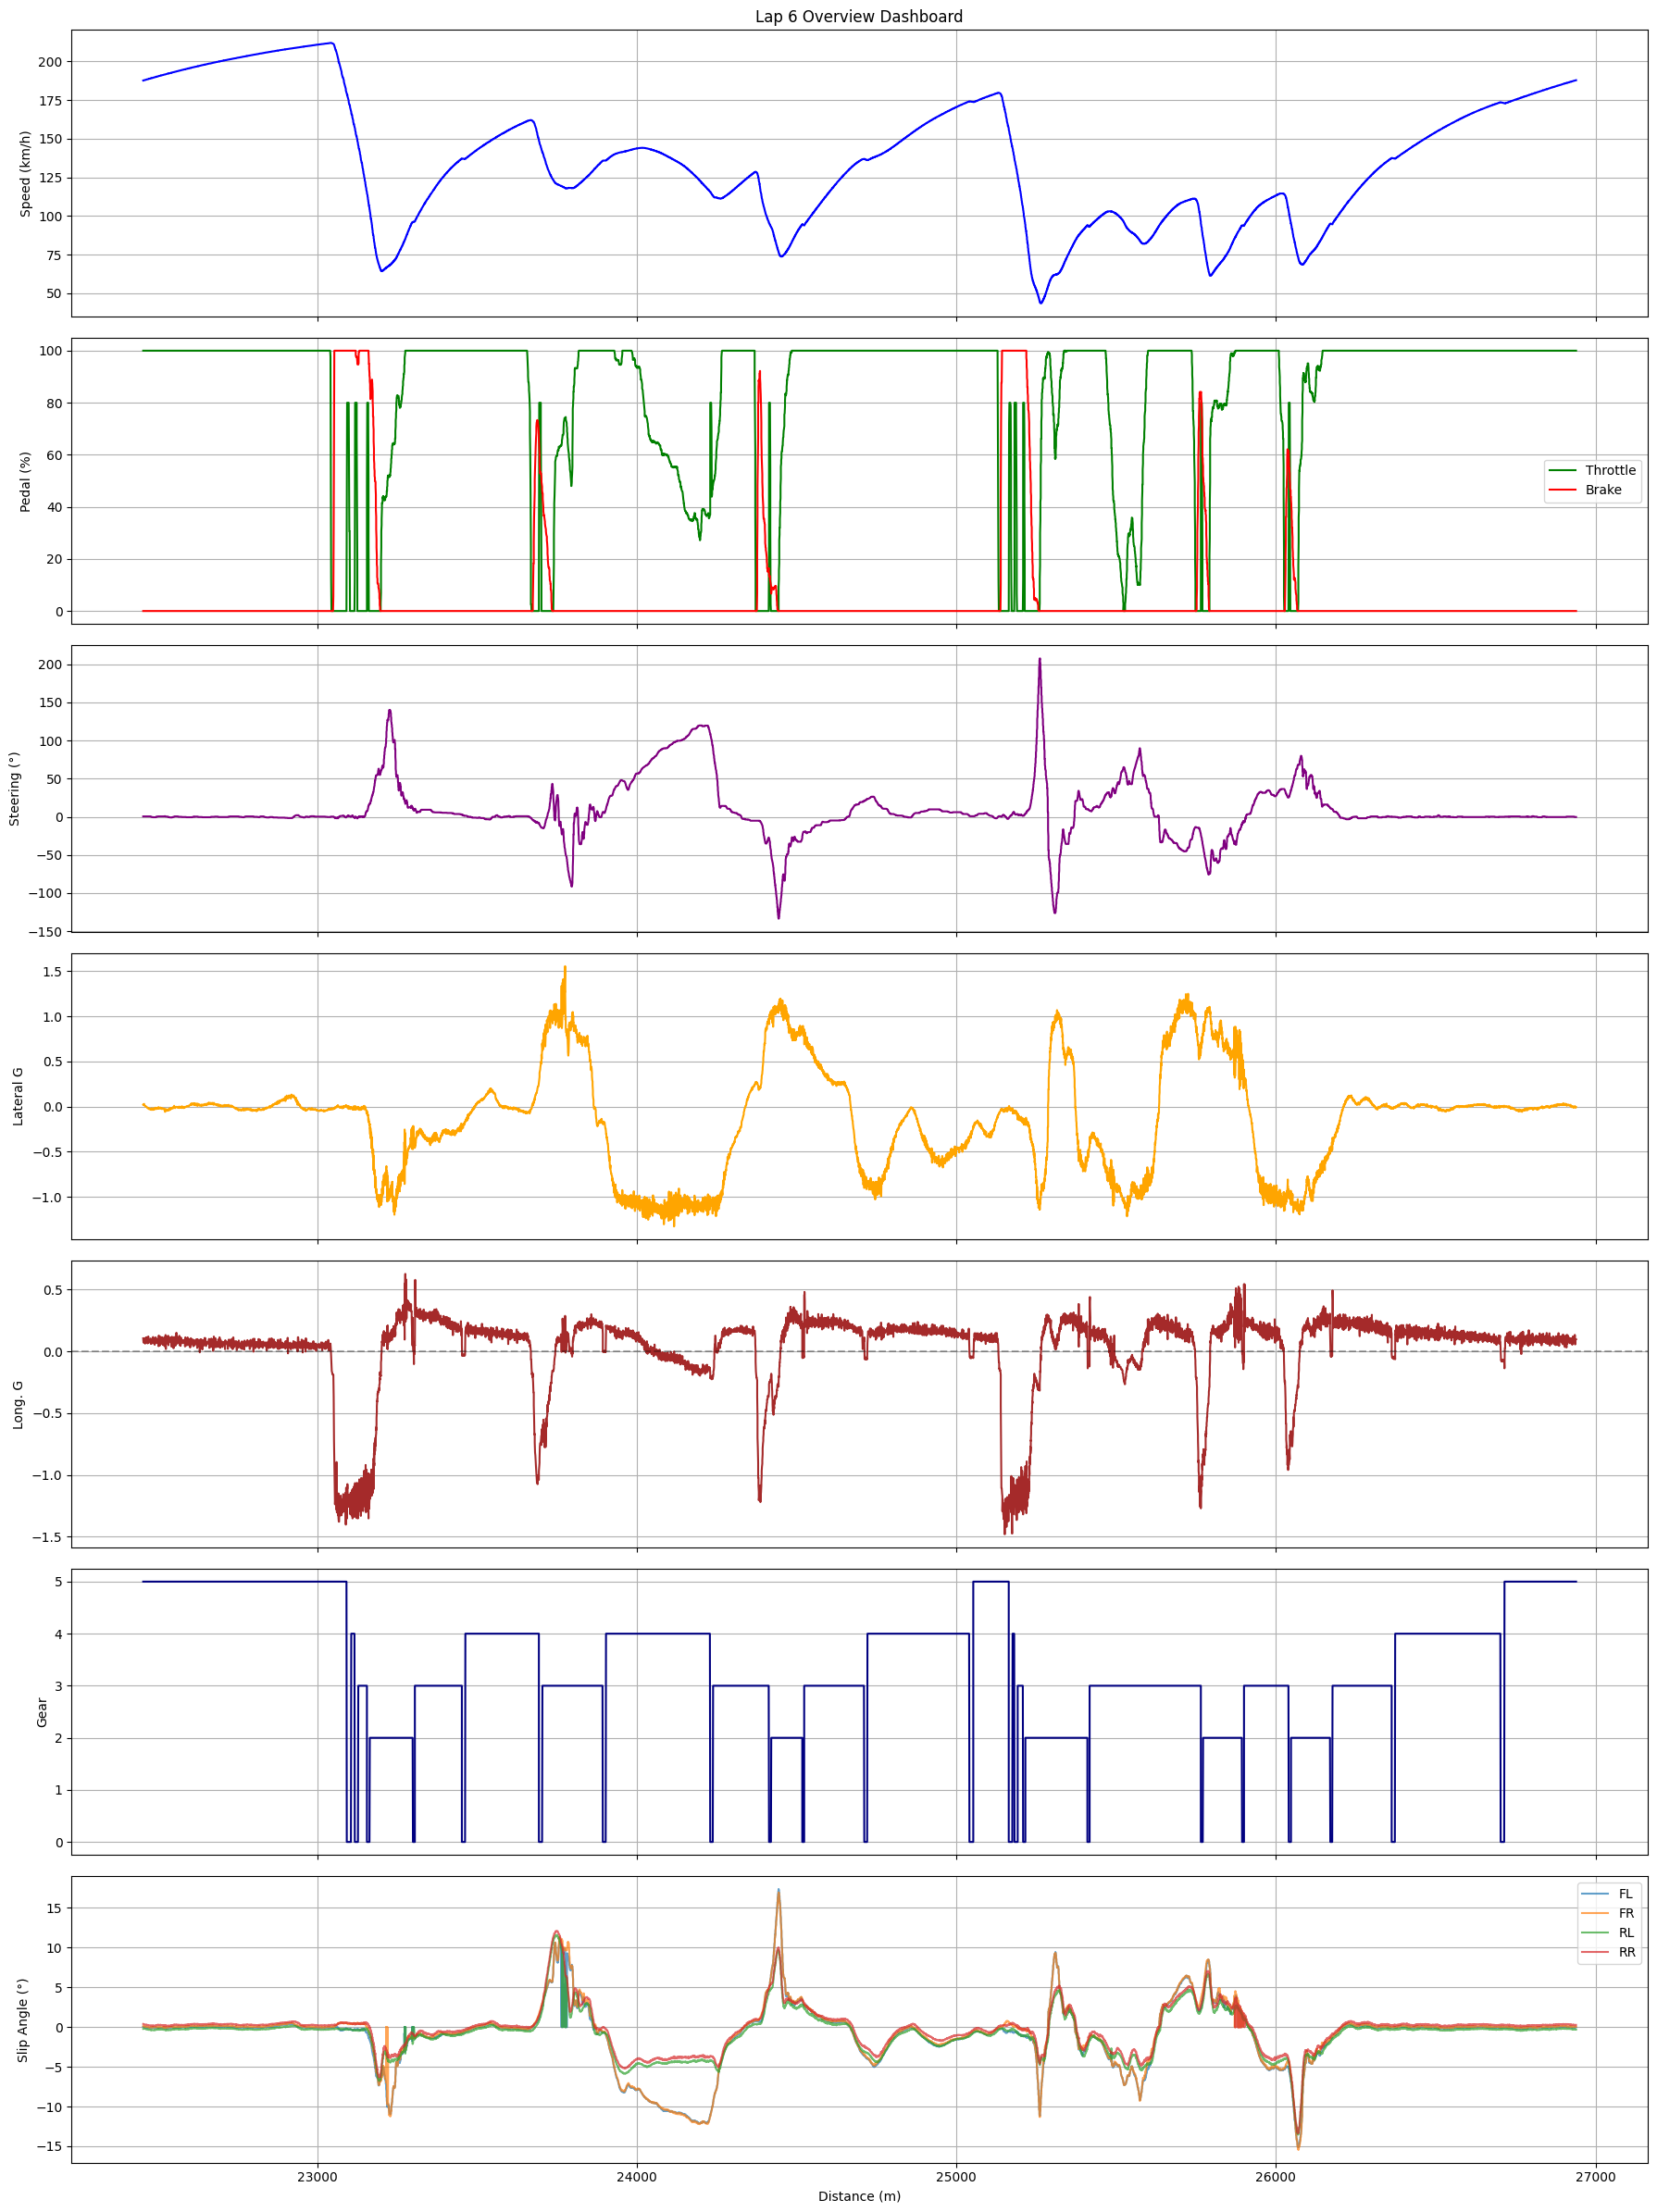

In [21]:
# === 総合ダッシュボード ===
fig, axes = plt.subplots(7, 1, figsize=(18, 24), sharex=True)

axes[0].plot(df6['Corr Dist'], df6['Corr Speed'], color='blue')
axes[0].set_ylabel('Speed (km/h)')
axes[0].set_title('Lap 6 Overview Dashboard')

axes[1].plot(df6['Corr Dist'], df6['Throttle Pos'], color='green', label='Throttle')
axes[1].plot(df6['Corr Dist'], df6['Brake Pos'], color='red', label='Brake')
axes[1].set_ylabel('Pedal (%)')
axes[1].legend()

axes[2].plot(df6['Corr Dist'], df6['Steering Angle'], color='purple')
axes[2].set_ylabel('Steering (°)')

axes[3].plot(df6['Corr Dist'], df6['CG Accel Lateral'], color='orange')
axes[3].set_ylabel('Lateral G')

axes[4].plot(df6['Corr Dist'], df6['CG Accel Longitudinal'], color='brown')
axes[4].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[4].set_ylabel('Long. G')

axes[5].plot(df6['Corr Dist'], df6['Gear'], color='navy')
axes[5].set_ylabel('Gear')

axes[6].plot(df6['Corr Dist'], df6['Tire Slip Angle FL'], label='FL', alpha=0.7)
axes[6].plot(df6['Corr Dist'], df6['Tire Slip Angle FR'], label='FR', alpha=0.7)
axes[6].plot(df6['Corr Dist'], df6['Tire Slip Angle RL'], label='RL', alpha=0.7)
axes[6].plot(df6['Corr Dist'], df6['Tire Slip Angle RR'], label='RR', alpha=0.7)
axes[6].set_ylabel('Slip Angle (°)')
axes[6].set_xlabel('Distance (m)')
axes[6].legend()

for ax in axes:
    ax.grid(True)

plt.tight_layout()
plt.show()

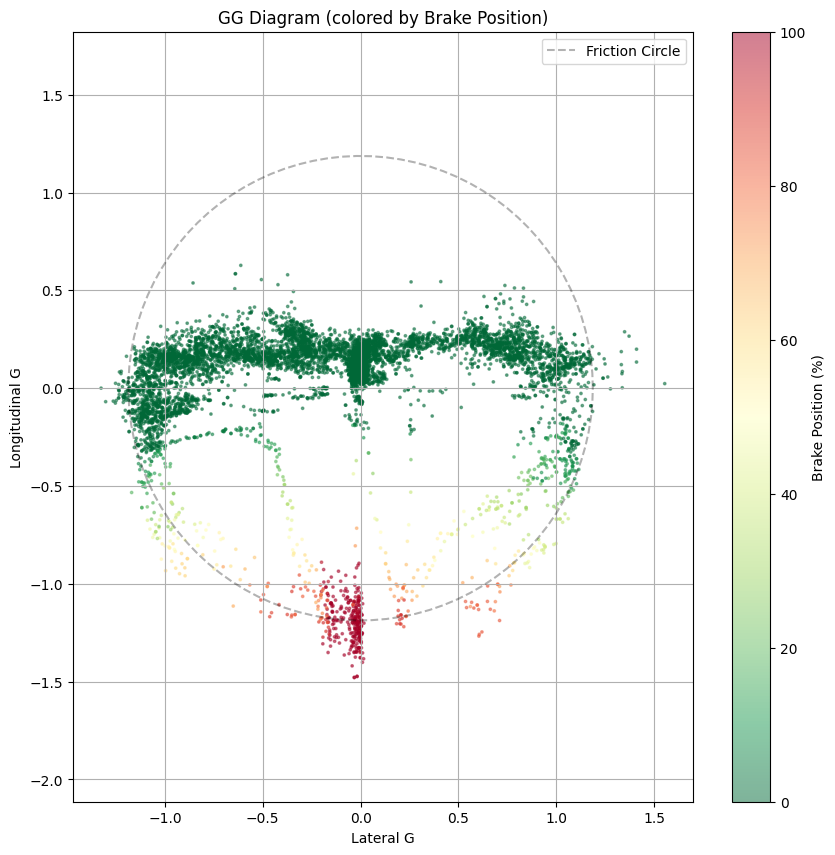

In [22]:
# === GGダイアグラム（ブレーキ位置カラー + フリクションサークル）===
fig, ax = plt.subplots(figsize=(10, 10))
scatter = ax.scatter(df6['CG Accel Lateral'], df6['CG Accel Longitudinal'],
                     c=df6['Brake Pos'], cmap='RdYlGn_r', s=3, alpha=0.5)
plt.colorbar(scatter, label='Brake Position (%)')

theta = np.linspace(0, 2*np.pi, 100)
max_g = max(abs(df6['CG Accel Lateral']).quantile(0.98),
            abs(df6['CG Accel Longitudinal']).quantile(0.98))
ax.plot(max_g * np.cos(theta), max_g * np.sin(theta), 'k--', alpha=0.3, label='Friction Circle')

ax.set_xlabel('Lateral G')
ax.set_ylabel('Longitudinal G')
ax.set_title('GG Diagram (colored by Brake Position)')
ax.axis('equal')
ax.grid(True)
ax.legend()
plt.show()

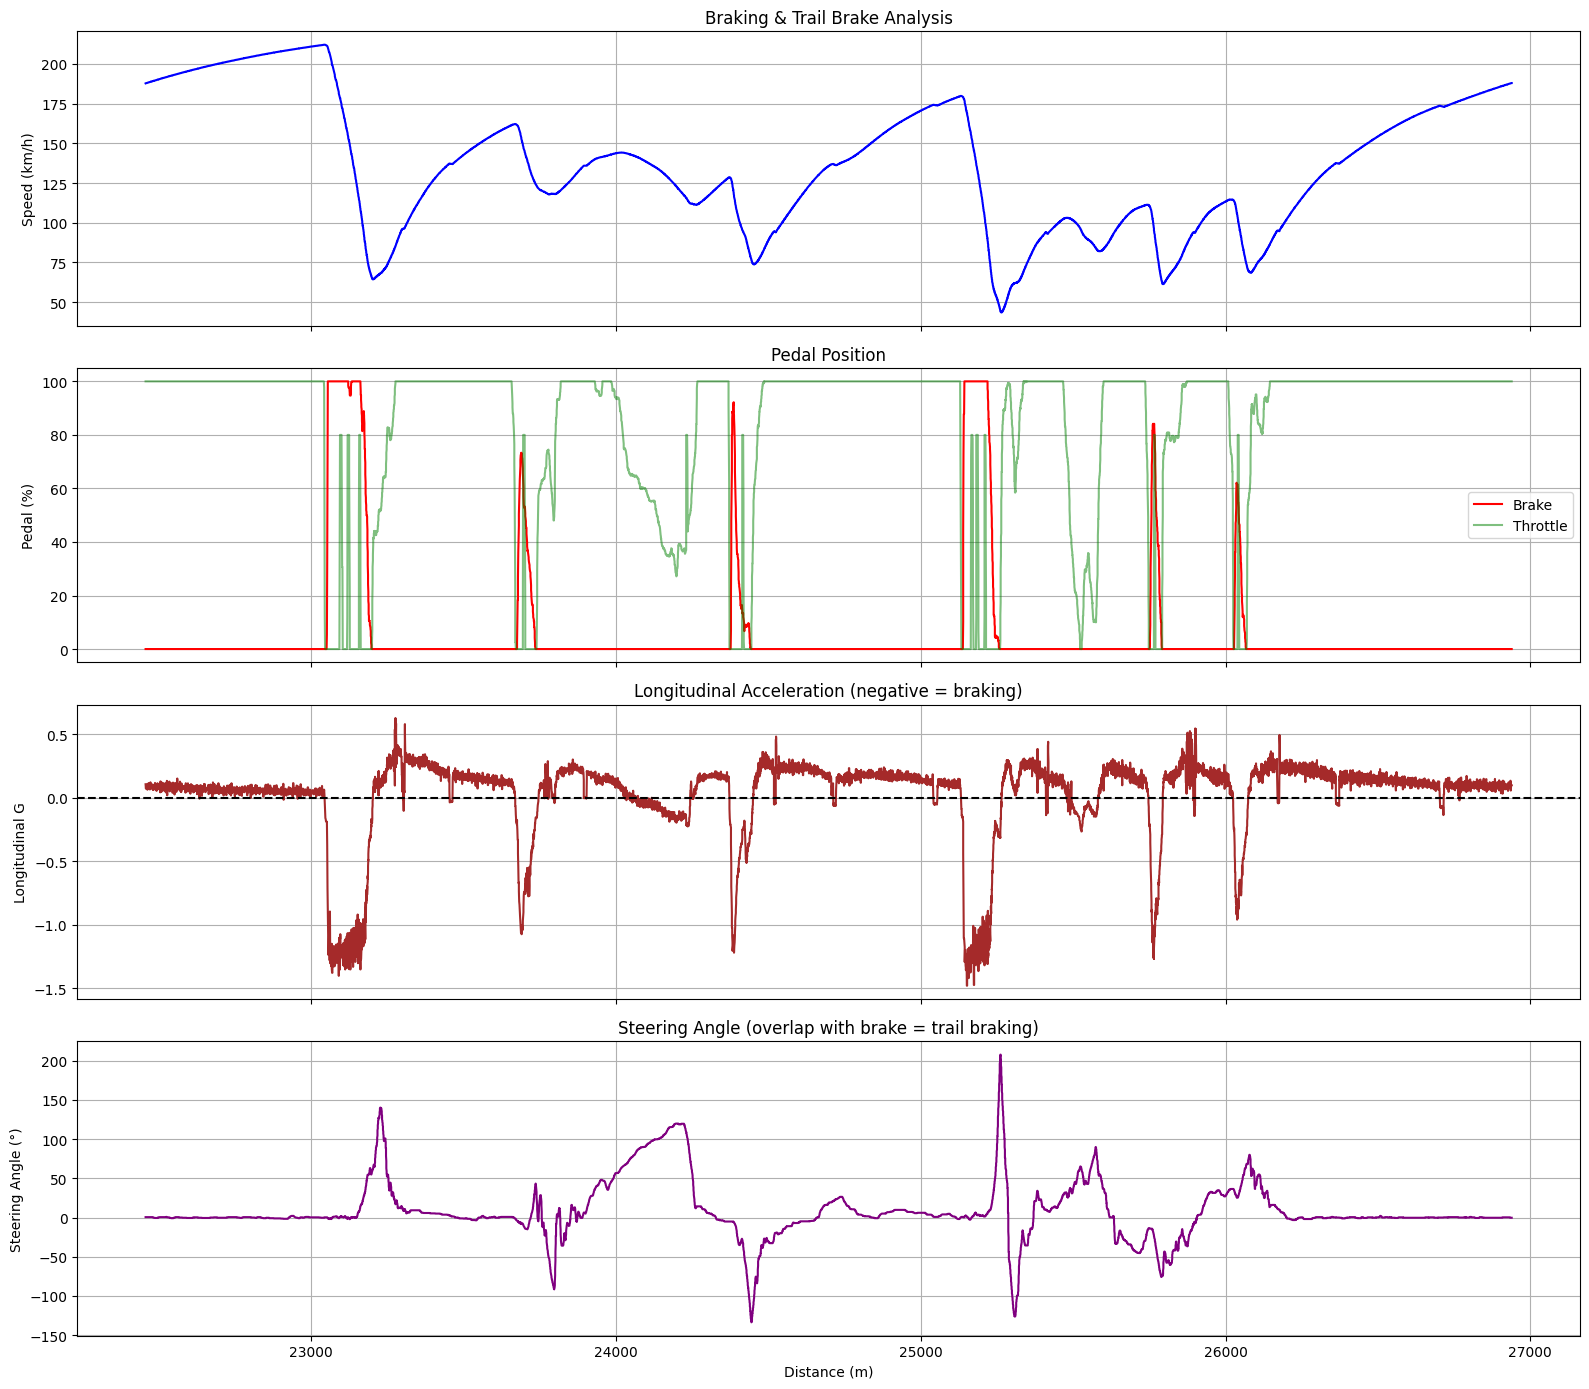

In [23]:
# === ブレーキング・トレイルブレーキ分析 ===
fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

axes[0].plot(df6['Corr Dist'], df6['Corr Speed'], color='blue')
axes[0].set_ylabel('Speed (km/h)')
axes[0].set_title('Braking & Trail Brake Analysis')
axes[0].grid(True)

axes[1].plot(df6['Corr Dist'], df6['Brake Pos'], color='red', label='Brake')
axes[1].plot(df6['Corr Dist'], df6['Throttle Pos'], color='green', alpha=0.5, label='Throttle')
axes[1].set_ylabel('Pedal (%)')
axes[1].set_title('Pedal Position')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(df6['Corr Dist'], df6['CG Accel Longitudinal'], color='brown')
axes[2].axhline(y=0, color='black', linestyle='--')
axes[2].set_ylabel('Longitudinal G')
axes[2].set_title('Longitudinal Acceleration (negative = braking)')
axes[2].grid(True)

axes[3].plot(df6['Corr Dist'], df6['Steering Angle'], color='purple')
axes[3].set_ylabel('Steering Angle (°)')
axes[3].set_title('Steering Angle (overlap with brake = trail braking)')
axes[3].set_xlabel('Distance (m)')
axes[3].grid(True)

plt.tight_layout()
plt.show()

NameError: name 'df6_copy' is not defined

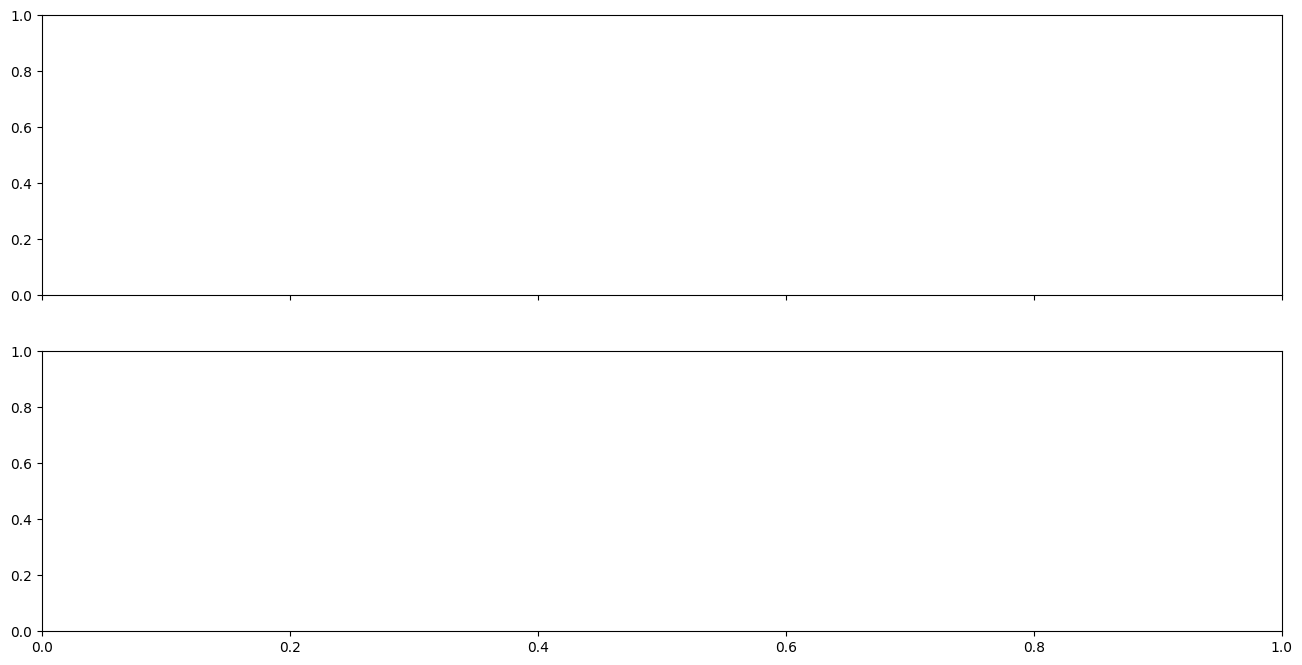

In [24]:

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
axes[0].plot(df6_copy['Corr Dist'], df6_copy['Steering Angle'], color='purple')
axes[0].set_ylabel('Steering Angle (°)')
axes[0].set_title('Steering Input')
axes[0].grid(True)

axes[1].plot(df6_copy['Corr Dist'], df6_copy['Steering_Rate'], color='red')
axes[1].set_ylabel('Steering Rate (°/m)')
axes[1].set_title('Steering Rate (spikes = corrections/slides)')
axes[1].set_ylim(-5, 5)  # 極端な値を除外して見やすくする
axes[1].set_xlabel('Distance (m)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

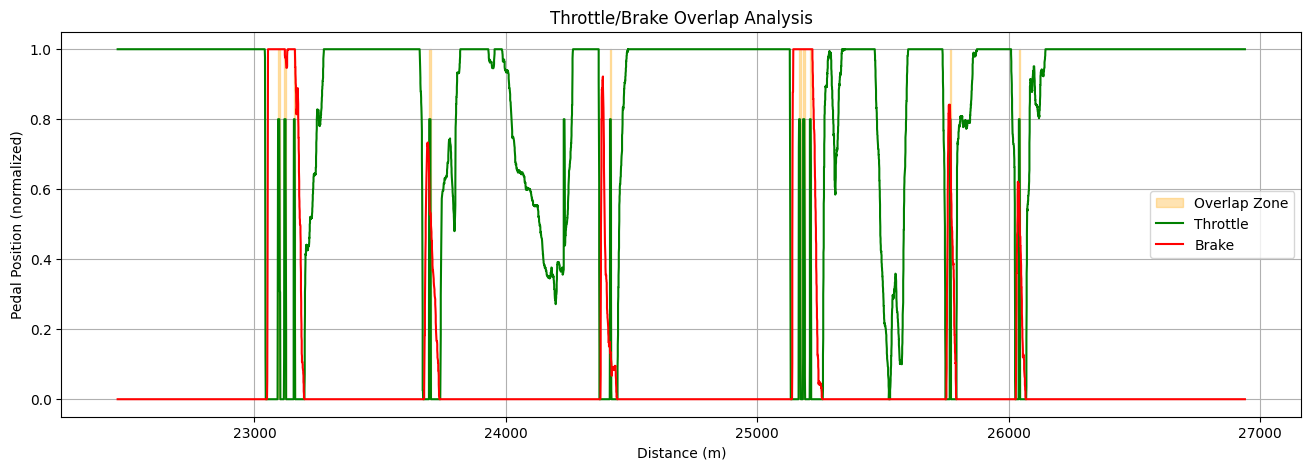

ペダルオーバーラップ率: 1.5%


In [25]:
# === スロットル/ブレーキ オーバーラップ分析 ===
overlap = (df6['Throttle Pos'] > 5) & (df6['Brake Pos'] > 5)

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(df6['Corr Dist'], 0, 1, where=overlap,
                alpha=0.3, color='orange', label='Overlap Zone')
ax.plot(df6['Corr Dist'], df6['Throttle Pos']/100, label='Throttle', color='green')
ax.plot(df6['Corr Dist'], df6['Brake Pos']/100, label='Brake', color='red')
ax.set_xlabel('Distance (m)')
ax.set_ylabel('Pedal Position (normalized)')
ax.set_title('Throttle/Brake Overlap Analysis')
ax.legend()
ax.grid(True)
plt.show()

overlap_pct = overlap.sum() / len(df6) * 100
print(f"ペダルオーバーラップ率: {overlap_pct:.1f}%")

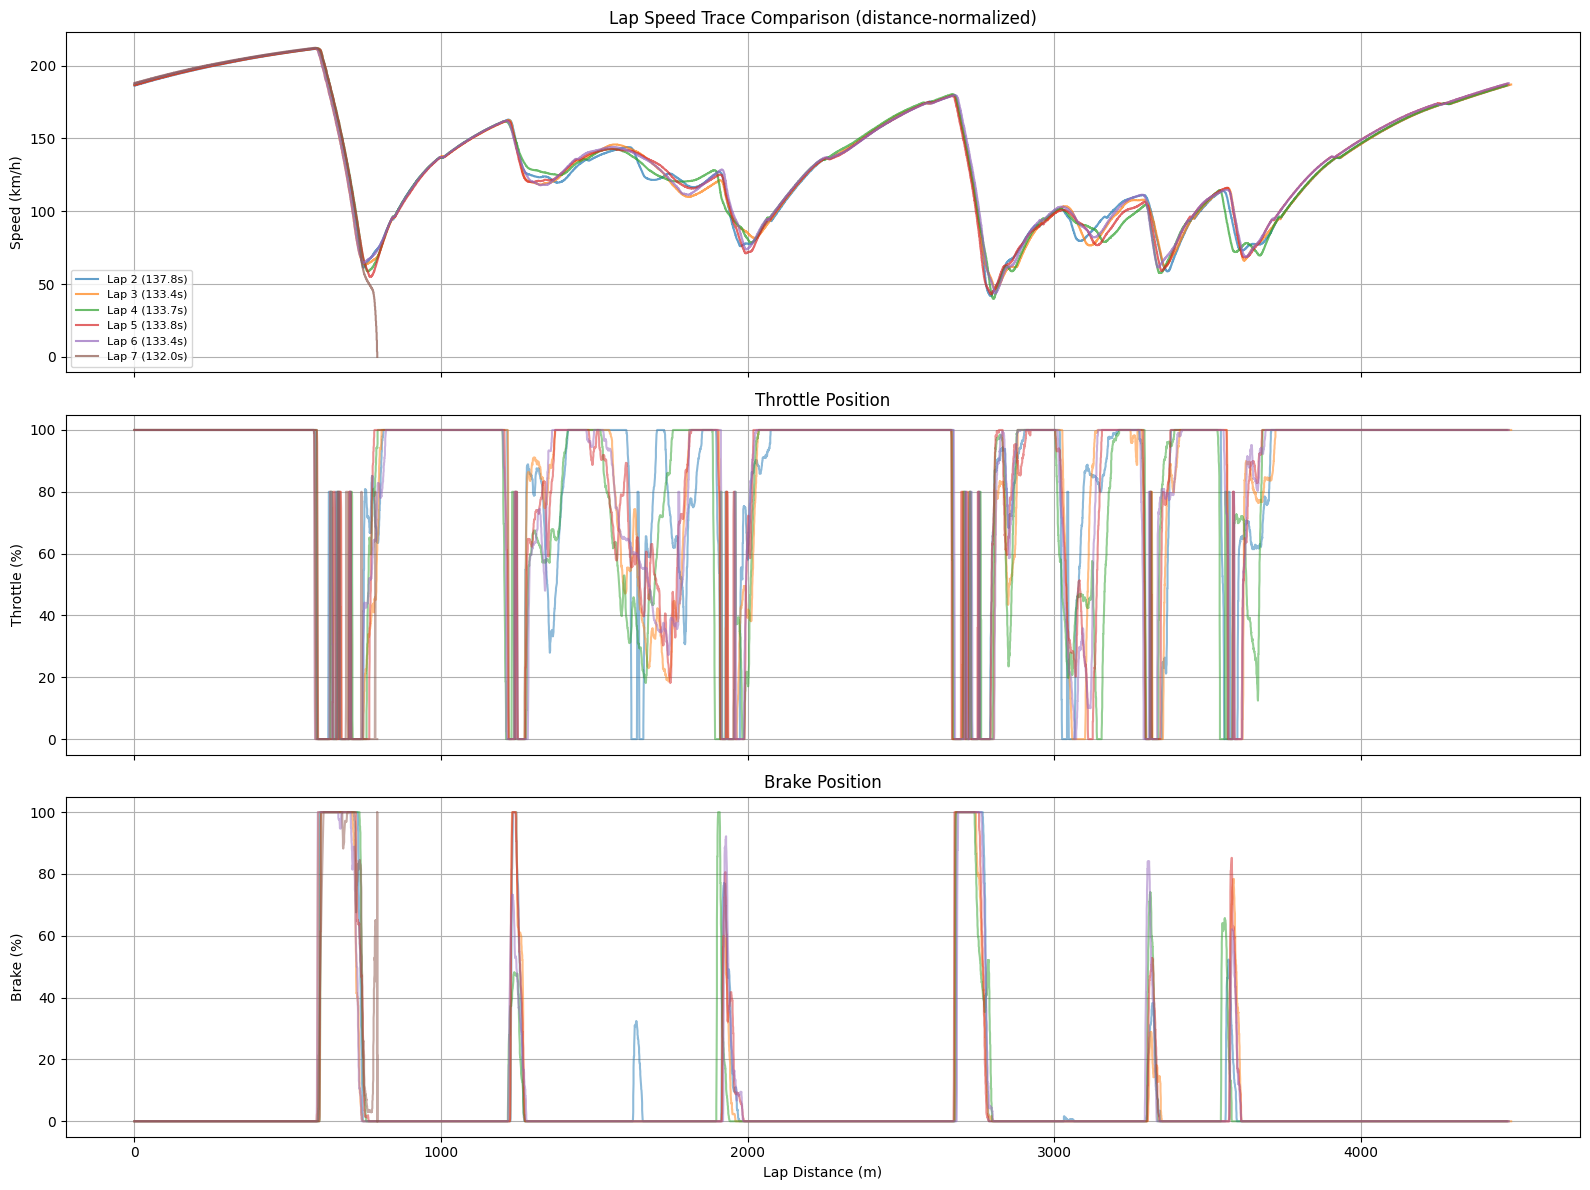

In [26]:
# === ラップ間速度トレース比較（距離を正規化して重ね比較）===
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

for name, lap_df in laps.items():
    lt = lap_df['Last Lap Time'].iloc[-1]
    if lt > 130 and lt < 200:
        # ラップ内の相対距離に変換
        lap_dist = lap_df['Corr Dist'] - lap_df['Corr Dist'].iloc[0]
        axes[0].plot(lap_dist, lap_df['Corr Speed'],
                     label=f"{name} ({lt:.1f}s)", alpha=0.7)
        axes[1].plot(lap_dist, lap_df['Throttle Pos'], label=name, alpha=0.5)
        axes[2].plot(lap_dist, lap_df['Brake Pos'], label=name, alpha=0.5)

axes[0].set_ylabel('Speed (km/h)')
axes[0].set_title('Lap Speed Trace Comparison (distance-normalized)')
axes[0].legend(fontsize=8)
axes[0].grid(True)

axes[1].set_ylabel('Throttle (%)')
axes[1].set_title('Throttle Position')
axes[1].grid(True)

axes[2].set_ylabel('Brake (%)')
axes[2].set_xlabel('Lap Distance (m)')
axes[2].set_title('Brake Position')
axes[2].grid(True)

plt.tight_layout()
plt.show()

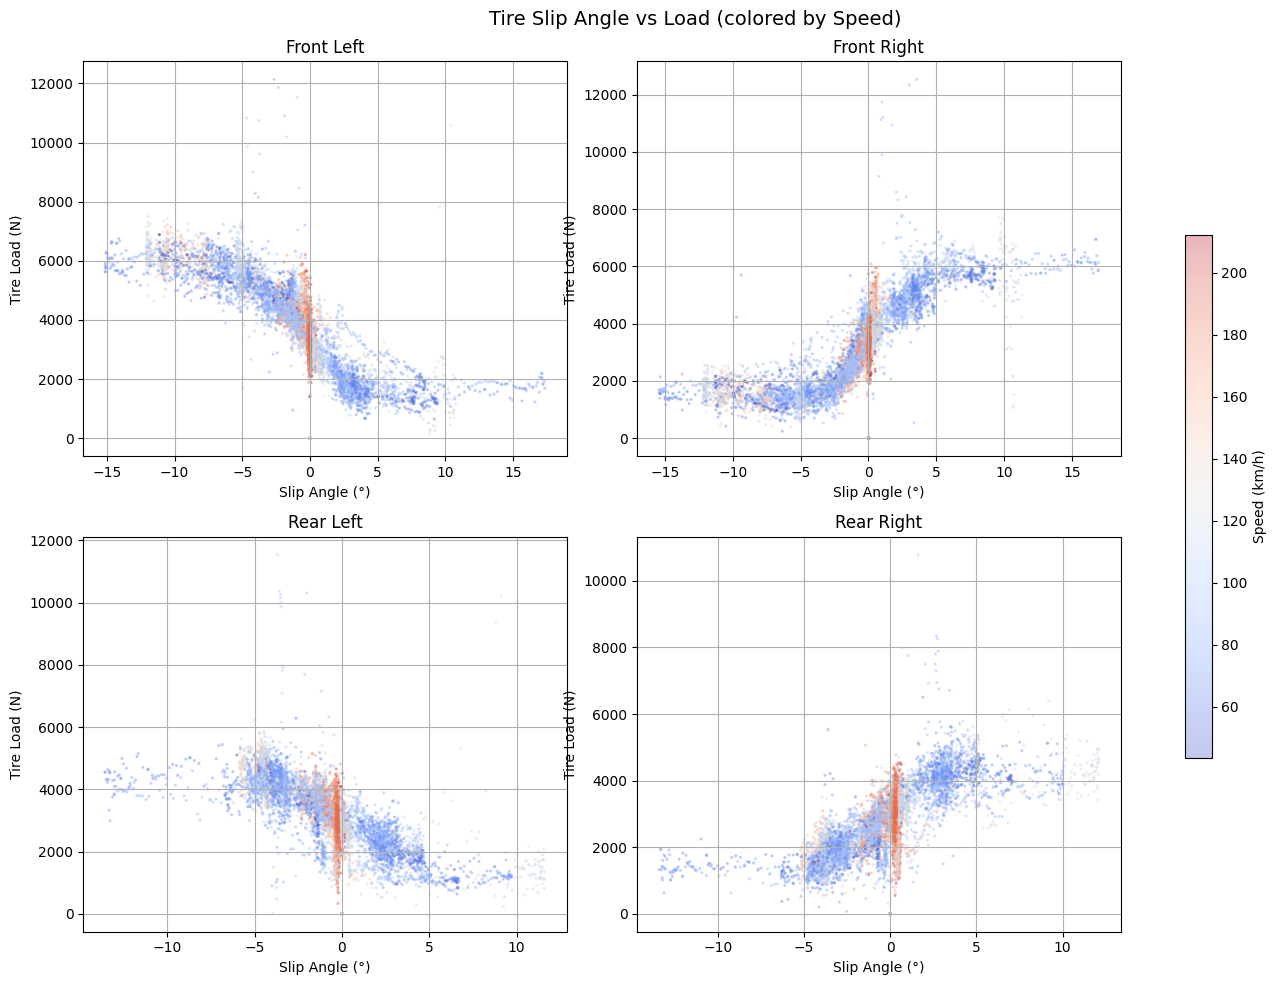

In [27]:
# === タイヤスリップアングル vs 荷重 ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
tires = [('FL', 'Front Left'), ('FR', 'Front Right'), ('RL', 'Rear Left'), ('RR', 'Rear Right')]

for ax, (abbr, name) in zip(axes.flatten(), tires):
    sc = ax.scatter(df6[f'Tire Slip Angle {abbr}'], df6[f'Tire Load {abbr}'],
                    c=df6['Corr Speed'], cmap='coolwarm', s=2, alpha=0.3)
    ax.set_xlabel('Slip Angle (°)')
    ax.set_ylabel('Tire Load (N)')
    ax.set_title(name)
    ax.grid(True)

plt.suptitle('Tire Slip Angle vs Load (colored by Speed)', fontsize=14)
plt.tight_layout()
plt.colorbar(sc, ax=axes, label='Speed (km/h)', shrink=0.6)
plt.show()

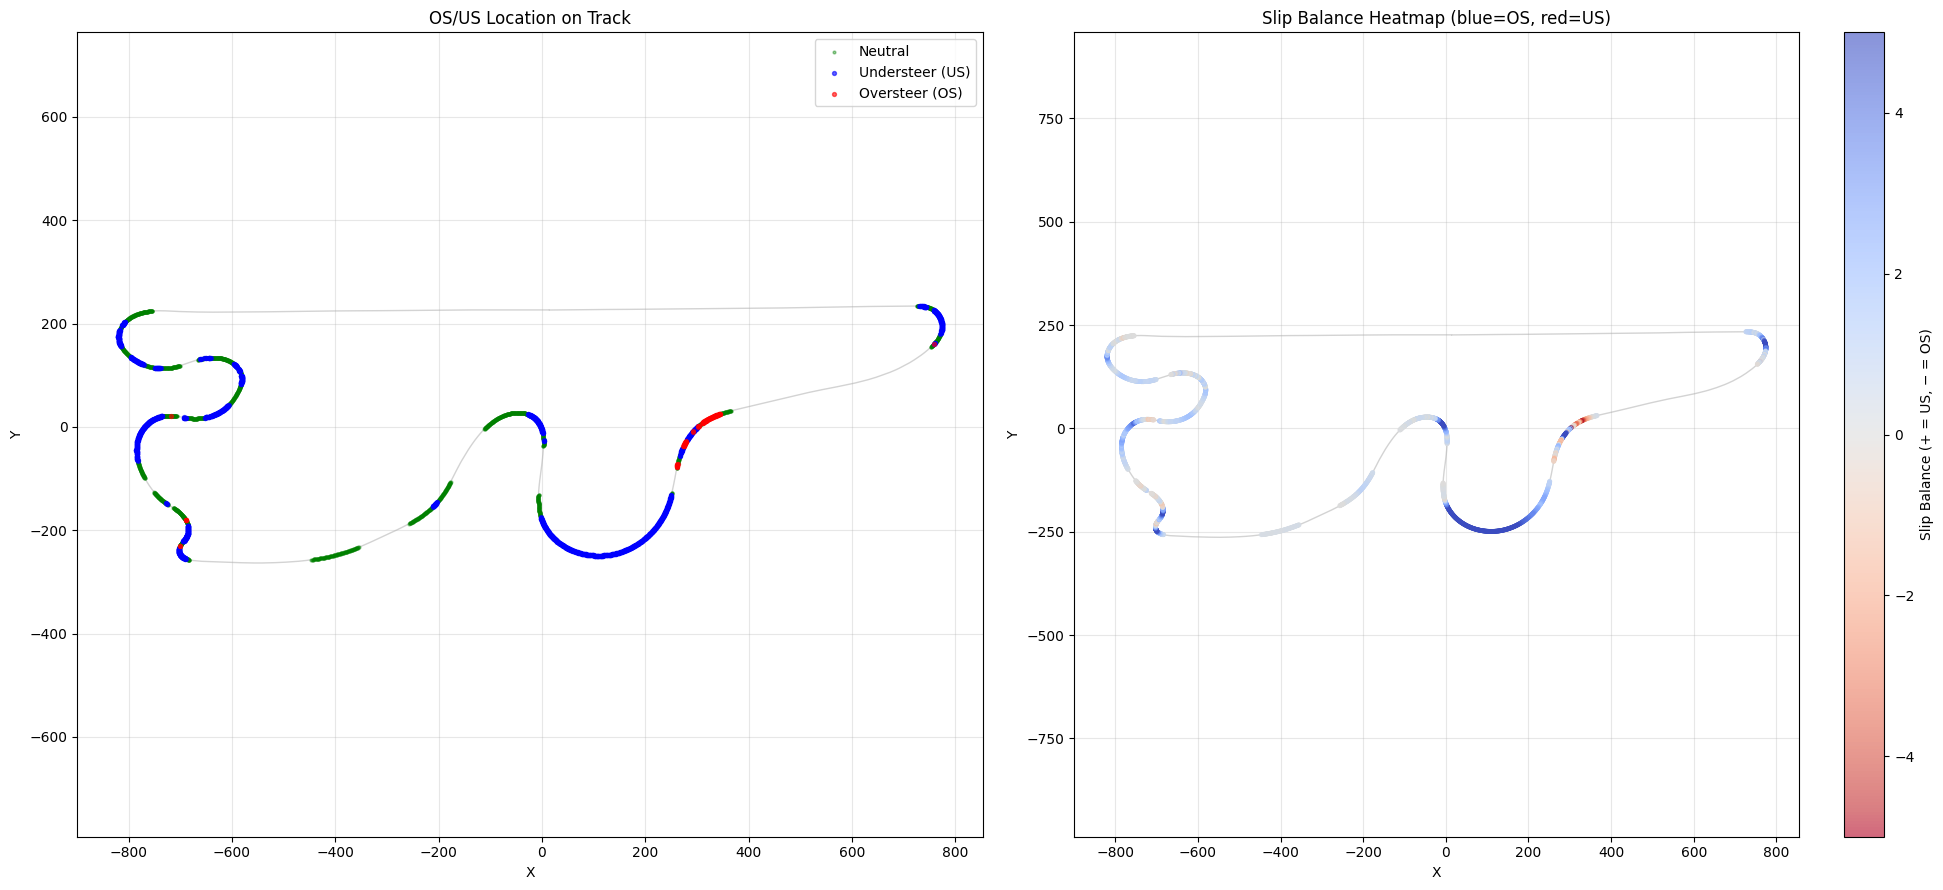

コーナリング中のサンプル数: 4139
  Understeer: 1877 (45.3%)
  Oversteer:  113 (2.7%)
  Neutral:    2149 (51.9%)


In [28]:
# === OS/US発生箇所のトラックマップ可視化 ===
# アンダーステア: フロントのスリップアングルがリアより大きい
# オーバーステア: リアのスリップアングルがフロントより大きい

# フロント・リアの平均スリップアングル（絶対値）
df6c = df6.copy()
df6c['Front_Slip'] = (df6c['Tire Slip Angle FL'].abs() + df6c['Tire Slip Angle FR'].abs()) / 2
df6c['Rear_Slip'] = (df6c['Tire Slip Angle RL'].abs() + df6c['Tire Slip Angle RR'].abs()) / 2
df6c['Slip_Balance'] = df6c['Front_Slip'] - df6c['Rear_Slip']  # 正=US, 負=OS

# 閾値（小さいスリップは直線走行なので除外）
min_slip = 1.5  # 最低スリップアングル（旋回中のみ対象）
balance_thresh = 1.0  # OS/US判定の閾値

is_cornering = (df6c['Front_Slip'] > min_slip) | (df6c['Rear_Slip'] > min_slip)
is_us = is_cornering & (df6c['Slip_Balance'] > balance_thresh)
is_os = is_cornering & (df6c['Slip_Balance'] < -balance_thresh)
is_neutral = is_cornering & ~is_us & ~is_os

# --- プロット1: トラックマップ上にOS/USをカラー表示 ---
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# 左: カテゴリカル表示
ax = axes[0]
ax.plot(df6c['Car Coord X'], df6c['Car Coord Y'], color='lightgray', linewidth=1, zorder=1)
ax.scatter(df6c.loc[is_neutral, 'Car Coord X'], df6c.loc[is_neutral, 'Car Coord Y'],
           c='green', s=4, alpha=0.4, label='Neutral', zorder=2)
ax.scatter(df6c.loc[is_us, 'Car Coord X'], df6c.loc[is_us, 'Car Coord Y'],
           c='blue', s=8, alpha=0.6, label='Understeer (US)', zorder=3)
ax.scatter(df6c.loc[is_os, 'Car Coord X'], df6c.loc[is_os, 'Car Coord Y'],
           c='red', s=8, alpha=0.6, label='Oversteer (OS)', zorder=3)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('OS/US Location on Track')
ax.axis('equal')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# 右: 連続値としてスリップバランスを表示
ax2 = axes[1]
ax2.plot(df6c['Car Coord X'], df6c['Car Coord Y'], color='lightgray', linewidth=1, zorder=1)
sc = ax2.scatter(df6c.loc[is_cornering, 'Car Coord X'], df6c.loc[is_cornering, 'Car Coord Y'],
                 c=df6c.loc[is_cornering, 'Slip_Balance'], cmap='coolwarm_r',
                 vmin=-5, vmax=5, s=6, alpha=0.6, zorder=2)
plt.colorbar(sc, ax=ax2, label='Slip Balance (+ = US, − = OS)')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_title('Slip Balance Heatmap (blue=OS, red=US)')
ax2.axis('equal')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# サマリー
print(f"コーナリング中のサンプル数: {is_cornering.sum()}")
print(f"  Understeer: {is_us.sum()} ({is_us.sum()/is_cornering.sum()*100:.1f}%)")
print(f"  Oversteer:  {is_os.sum()} ({is_os.sum()/is_cornering.sum()*100:.1f}%)")
print(f"  Neutral:    {is_neutral.sum()} ({is_neutral.sum()/is_cornering.sum()*100:.1f}%)")

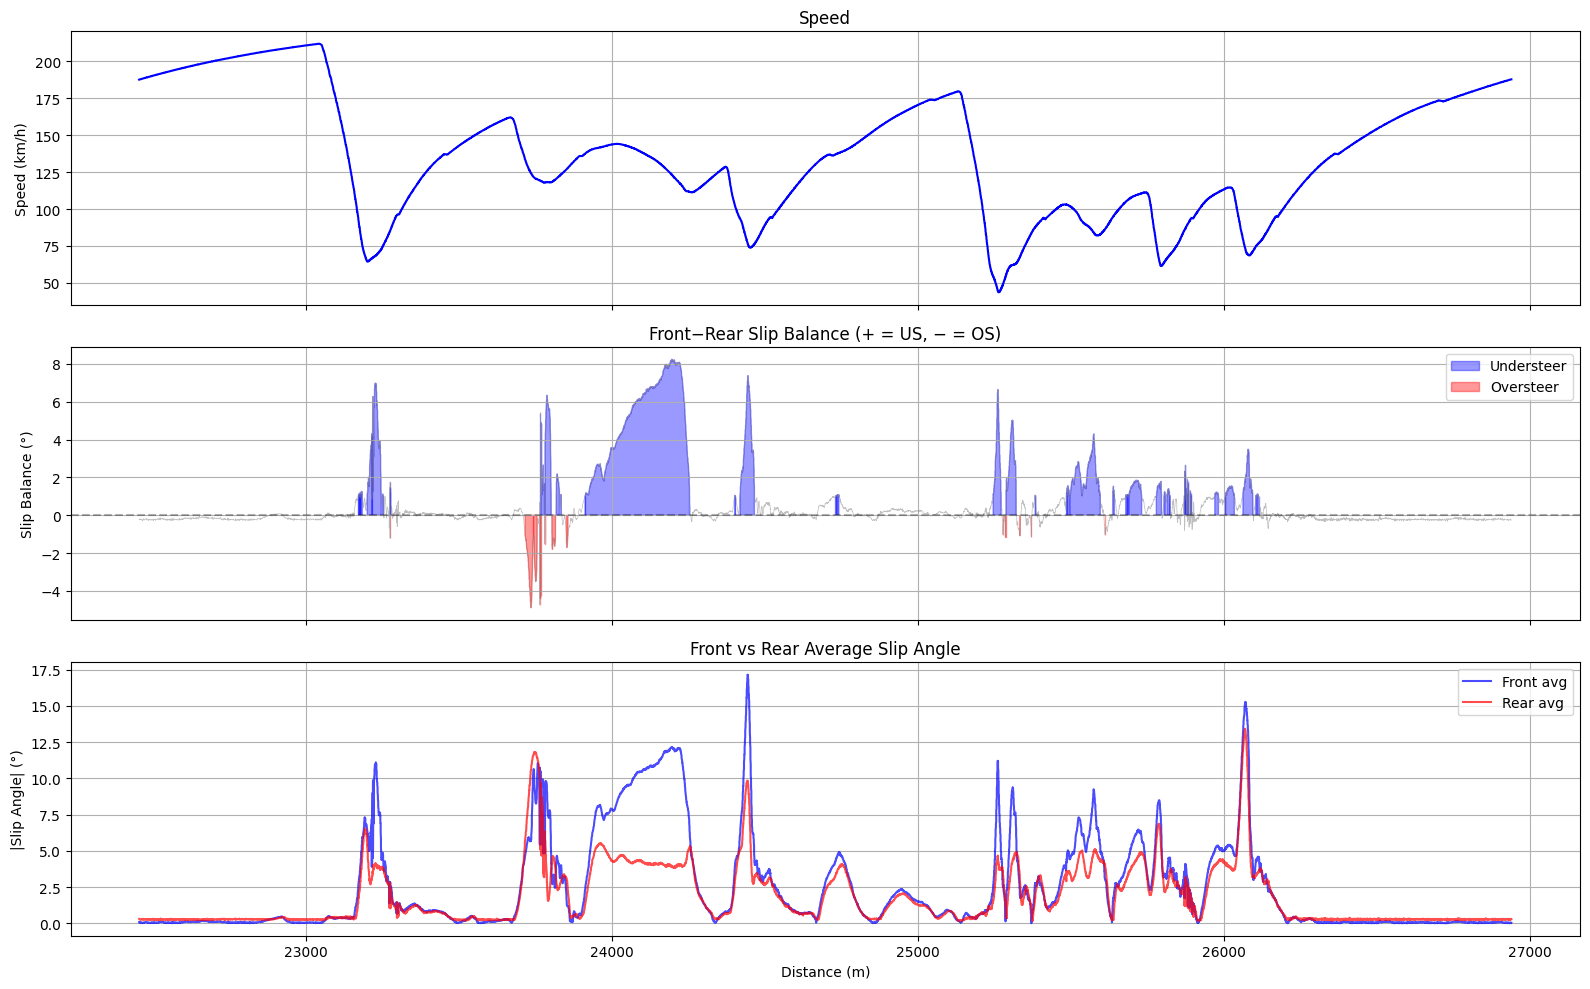

In [29]:
# === OS/USバランスの距離ベース詳細 ===
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

axes[0].plot(df6c['Corr Dist'], df6c['Corr Speed'], color='blue')
axes[0].set_ylabel('Speed (km/h)')
axes[0].set_title('Speed')
axes[0].grid(True)

# スリップバランス
axes[1].plot(df6c['Corr Dist'], df6c['Slip_Balance'], color='gray', alpha=0.5, linewidth=0.5)
axes[1].fill_between(df6c['Corr Dist'], df6c['Slip_Balance'], 0,
                     where=df6c['Slip_Balance'] > balance_thresh,
                     color='blue', alpha=0.4, label='Understeer')
axes[1].fill_between(df6c['Corr Dist'], df6c['Slip_Balance'], 0,
                     where=df6c['Slip_Balance'] < -balance_thresh,
                     color='red', alpha=0.4, label='Oversteer')
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.3)
axes[1].set_ylabel('Slip Balance (°)')
axes[1].set_title('Front−Rear Slip Balance (+ = US, − = OS)')
axes[1].legend()
axes[1].grid(True)

# 個別スリップアングル
axes[2].plot(df6c['Corr Dist'], df6c['Front_Slip'], label='Front avg', color='blue', alpha=0.7)
axes[2].plot(df6c['Corr Dist'], df6c['Rear_Slip'], label='Rear avg', color='red', alpha=0.7)
axes[2].set_ylabel('|Slip Angle| (°)')
axes[2].set_xlabel('Distance (m)')
axes[2].set_title('Front vs Rear Average Slip Angle')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [44]:
# === コーナー自動検出（9コーナー版） ===
def uniform_filter(arr, size):
    """scipy不要の簡易均一フィルタ"""
    kernel = np.ones(size) / size
    return np.convolve(arr, kernel, mode='same')

df6c = df6.copy()
df6c['Front_Slip'] = (df6c['Tire Slip Angle FL'].abs() + df6c['Tire Slip Angle FR'].abs()) / 2
df6c['Rear_Slip'] = (df6c['Tire Slip Angle RL'].abs() + df6c['Tire Slip Angle RR'].abs()) / 2
df6c['Slip_Balance'] = df6c['Front_Slip'] - df6c['Rear_Slip']

# ステアリング角の絶対値をスムージングしてコーナー区間を検出
steer_smooth = uniform_filter(df6c['Steering Angle'].abs().values, size=30)
df6c['Steer_Smooth'] = steer_smooth

# --- Step 1: コーナー区間をステアリング閾値で検出 ---
corner_thresh = 6
is_corner = steer_smooth > corner_thresh

corner_groups = (is_corner != np.roll(is_corner, 1)).cumsum()
corner_groups[~is_corner] = 0

corners_raw = []
for gid in np.unique(corner_groups):
    if gid == 0:
        continue
    mask = corner_groups == gid
    indices = df6c.index[mask]
    if len(indices) < 20:
        continue
    corners_raw.append((indices[0], indices[-1]))

# --- Step 2: マイルドなステアリング区間を除外 ---
filtered_raw = []
for s, e in corners_raw:
    max_steer = df6c.loc[s:e, 'Steering Angle'].abs().max()
    if max_steer > 15:  # ステアリング15°以上のみ有効コーナーとして扱う
        filtered_raw.append((s, e))

print(f"有効Raw corners: {len(filtered_raw)} (閾値 max|steer| > 15°で{len(corners_raw)-len(filtered_raw)}個除外)")
for i, (s, e) in enumerate(filtered_raw):
    seg = df6c.loc[s:e]
    avg = seg['Steering Angle'].mean()
    print(f"  [{i}] dist {seg['Corr Dist'].iloc[0]:.0f}–{seg['Corr Dist'].iloc[-1]:.0f}m, "
          f"{'R' if avg > 0 else 'L'} (avg={avg:.1f}°), speed {seg['Corr Speed'].min():.0f}–{seg['Corr Speed'].max():.0f}")

# --- Step 3: Dunlopシケイン区間(filtered[5])をDunlop + T13に分割 ---
# Dunlopシケインは右→左の複合コーナー。シケイン後の加速区間で分割し、
# 後半の右コーナー部分をT13とする。
# 速度の2番目の谷（シケイン脱出後のT13進入ブレーキ）を分割点にする。
dunlop_s, dunlop_e = filtered_raw[5]
seg_dunlop = df6c.loc[dunlop_s:dunlop_e]
speed_smooth_d = uniform_filter(seg_dunlop['Corr Speed'].values, 20)
speed_diff_d = np.diff(speed_smooth_d)

# 速度の谷を検出
valleys = []
for j in range(1, len(speed_diff_d)):
    if speed_diff_d[j] > 0 and speed_diff_d[j-1] < 0:
        idx = dunlop_s + j
        valleys.append((idx, df6c.loc[idx, 'Corr Dist'], df6c.loc[idx, 'Corr Speed']))

print(f"\nDunlop区間内の速度谷: {len(valleys)}箇所")
for idx, d, spd in valleys:
    print(f"  idx={idx}, dist={d:.0f}m, speed={spd:.0f} km/h")

# 2番目の速度谷でDunlop/T13を分割
if len(valleys) >= 2:
    split_idx = valleys[1][0]
else:
    # フォールバック: 区間の中間点
    split_idx = dunlop_s + (dunlop_e - dunlop_s) // 2

split_dist = df6c.loc[split_idx, 'Corr Dist']
print(f"Dunlop/T13 分割点: idx={split_idx}, dist={split_dist:.0f}m")

# --- Step 4: 9コーナーの配列を構築 ---
# filtered_raw: [0]=T1, [1]=Coca-Cola, [2]=100R, [3]=Hairpin, [4]=300R,
#               [5]=Dunlop+T13, [6]=GR GT(L), [7]=Final(R)
corners_9 = []
corners_9.extend(filtered_raw[:5])              # T1, Coca-Cola, 100R, Hairpin, 300R
corners_9.append((dunlop_s, split_idx))          # Dunlop (シケイン: R+L)
corners_9.append((split_idx + 1, dunlop_e))      # T13 (R)
corners_9.append(filtered_raw[6])                 # GR GT (L)
corners_9.append(filtered_raw[7])                 # Final (R)

# --- Step 5: ブレーキ開始地点を含むようにT1/Dunlopの開始を拡張 ---
def find_brake_start(df, corner_start_idx, search_dist=400, brake_thresh=5):
    """コーナー開始前のブレーキ開始地点を探す"""
    corner_dist = df.loc[corner_start_idx, 'Corr Dist']
    pre_mask = (df['Corr Dist'] >= corner_dist - search_dist) & (df.index < corner_start_idx)
    pre_seg = df[pre_mask]
    if len(pre_seg) == 0:
        return None
    brake_on = (pre_seg['Brake Pos'] > brake_thresh).values
    brake_start = None
    for j in range(len(brake_on) - 1, -1, -1):
        if brake_on[j]:
            brake_start = pre_seg.index[j]
        else:
            if brake_start is not None:
                break
    return brake_start

# T1(index 0) と Dunlop(index 5) のブレーキ開始地点を検出して拡張
brake_extend = {}
for ci in [0, 5]:
    raw_s = corners_9[ci][0]
    brake_idx = find_brake_start(df6c, raw_s)
    if brake_idx is not None:
        brake_extend[ci] = brake_idx
        cname = ["T1", "Coca-Cola", "100R", "Hairpin", "300R", "Dunlop"][ci]
        print(f"  {cname}: ブレーキ開始 dist={df6c.loc[brake_idx, 'Corr Dist']:.0f}m "
              f"(元: {df6c.loc[raw_s, 'Corr Dist']:.0f}m, {raw_s - brake_idx}samples前)")

# corners_9 のT1/Dunlopの開始をブレーキ開始地点に拡張
for ci, brake_idx in brake_extend.items():
    corners_9[ci] = (brake_idx, corners_9[ci][1])

# --- Step 5b: マージン付きコーナー境界を計算（隣接コーナーと重ならないよう制限）---
margin = 100
corners = []
for i, (s, e) in enumerate(corners_9):
    if i > 0:
        prev_e = corners_9[i-1][1]
        gap = s - prev_e
        start_margin = min(margin, gap // 2)
    else:
        start_margin = margin

    if i < len(corners_9) - 1:
        next_s = corners_9[i+1][0]
        gap = next_s - e
        end_margin = min(margin, gap // 2)
    else:
        end_margin = margin

    start_idx = max(df6c.index[0], s - start_margin)
    end_idx = min(df6c.index[-1], e + end_margin)
    corners.append((start_idx, end_idx))

# --- Step 6: コーナー名 ---
fsw_names = [
    "T1", "Coca-Cola", "100R",
    "Hairpin", "300R", "Dunlop",
    "T13", "GR GT", "Final"
]

print(f"\n検出されたコーナー数: {len(corners)}")
print(f"{'#':<4} {'Corner':<14} {'Dist Range':<22} {'Min Spd':>8} {'Max Spd':>8} {'Max|Steer|':>11} {'Dir':>6} {'Samples':>8}")
print("-" * 82)
for i, (s, e) in enumerate(corners):
    seg = df6c.loc[s:e]
    dist_s = seg['Corr Dist'].iloc[0]
    dist_e = seg['Corr Dist'].iloc[-1]
    min_speed = seg['Corr Speed'].min()
    max_speed = seg['Corr Speed'].max()
    max_steer = seg['Steering Angle'].abs().max()
    avg_steer = seg['Steering Angle'].mean()
    direction = "R" if avg_steer > 0 else "L"
    cname = fsw_names[i] if i < len(fsw_names) else f"Corner {i+1}"
    print(f"{i+1:<4} {cname:<14} {dist_s:>8.0f}–{dist_e:<8.0f}m  {min_speed:>7.0f} {max_speed:>7.0f}   {max_steer:>9.0f}°  {direction:>4}  {e-s:>7}")

有効Raw corners: 8 (閾値 max|steer| > 15°で1個除外)
  [0] dist 23154–23368m, R (avg=45.5°), speed 64–118
  [1] dist 23684–23872m, L (avg=-13.1°), speed 118–157
  [2] dist 23898–24302m, R (avg=69.0°), speed 111–144
  [3] dist 24384–24600m, L (avg=-40.5°), speed 74–121
  [4] dist 24670–24791m, R (avg=17.1°), speed 131–143
  [5] dist 25220–25616m, R (avg=25.6°), speed 44–103
  [6] dist 25631–25899m, L (avg=-36.5°), speed 61–111
  [7] dist 25920–26187m, R (avg=35.2°), speed 69–115

Dunlop区間内の速度谷: 2箇所
  idx=4536, dist=25265m, speed=44 km/h
  idx=5013, dist=25416m, speed=93 km/h
Dunlop/T13 分割点: idx=5013, dist=25416m
  T1: ブレーキ開始 dist=23051m (元: 23154m, 136samples前)
  Dunlop: ブレーキ開始 dist=25139m (元: 25220m, 132samples前)

検出されたコーナー数: 9
#    Corner         Dist Range              Min Spd  Max Spd  Max|Steer|    Dir  Samples
----------------------------------------------------------------------------------
1    T1                22954–23427   m       64     212         140°     R      877
2    Coca-Cola 

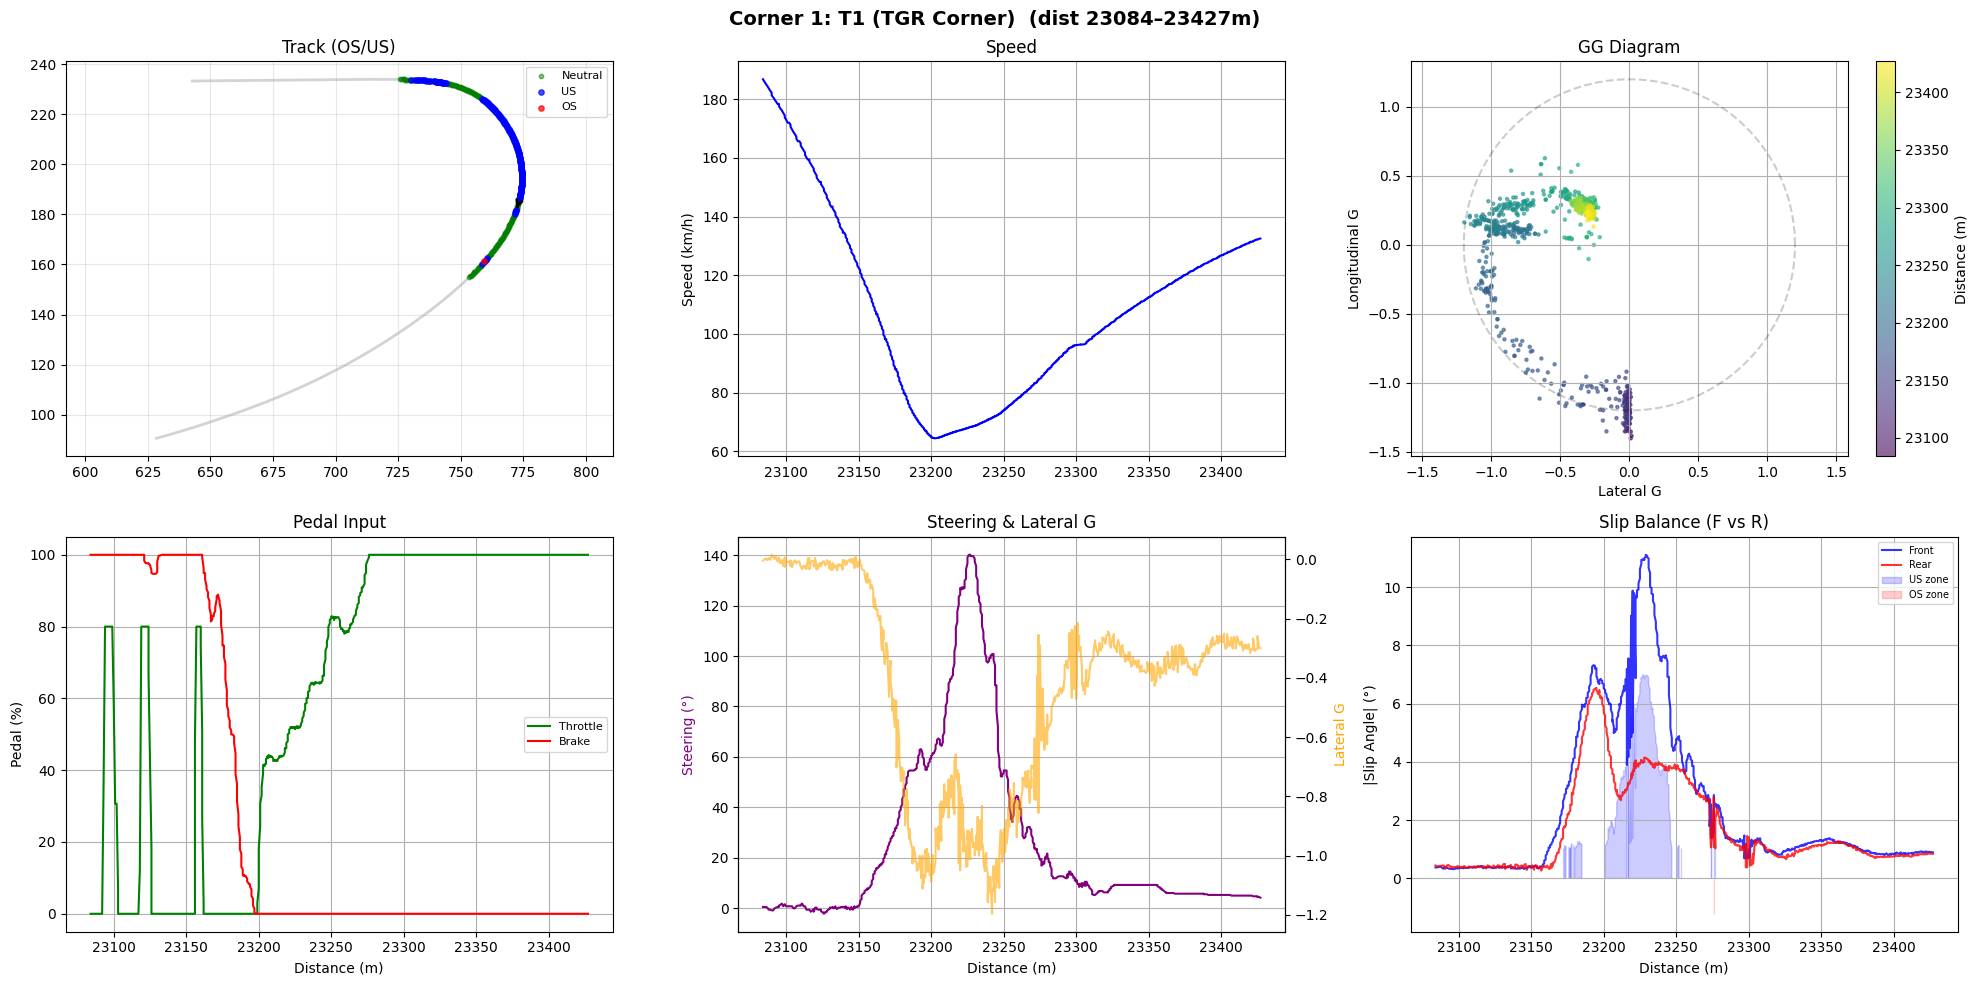

  [T1 (TGR Corner)] Min Speed: 64 km/h | US: 51% | OS: 0% | Max |Steer|: 140° | Max Brake: 100%



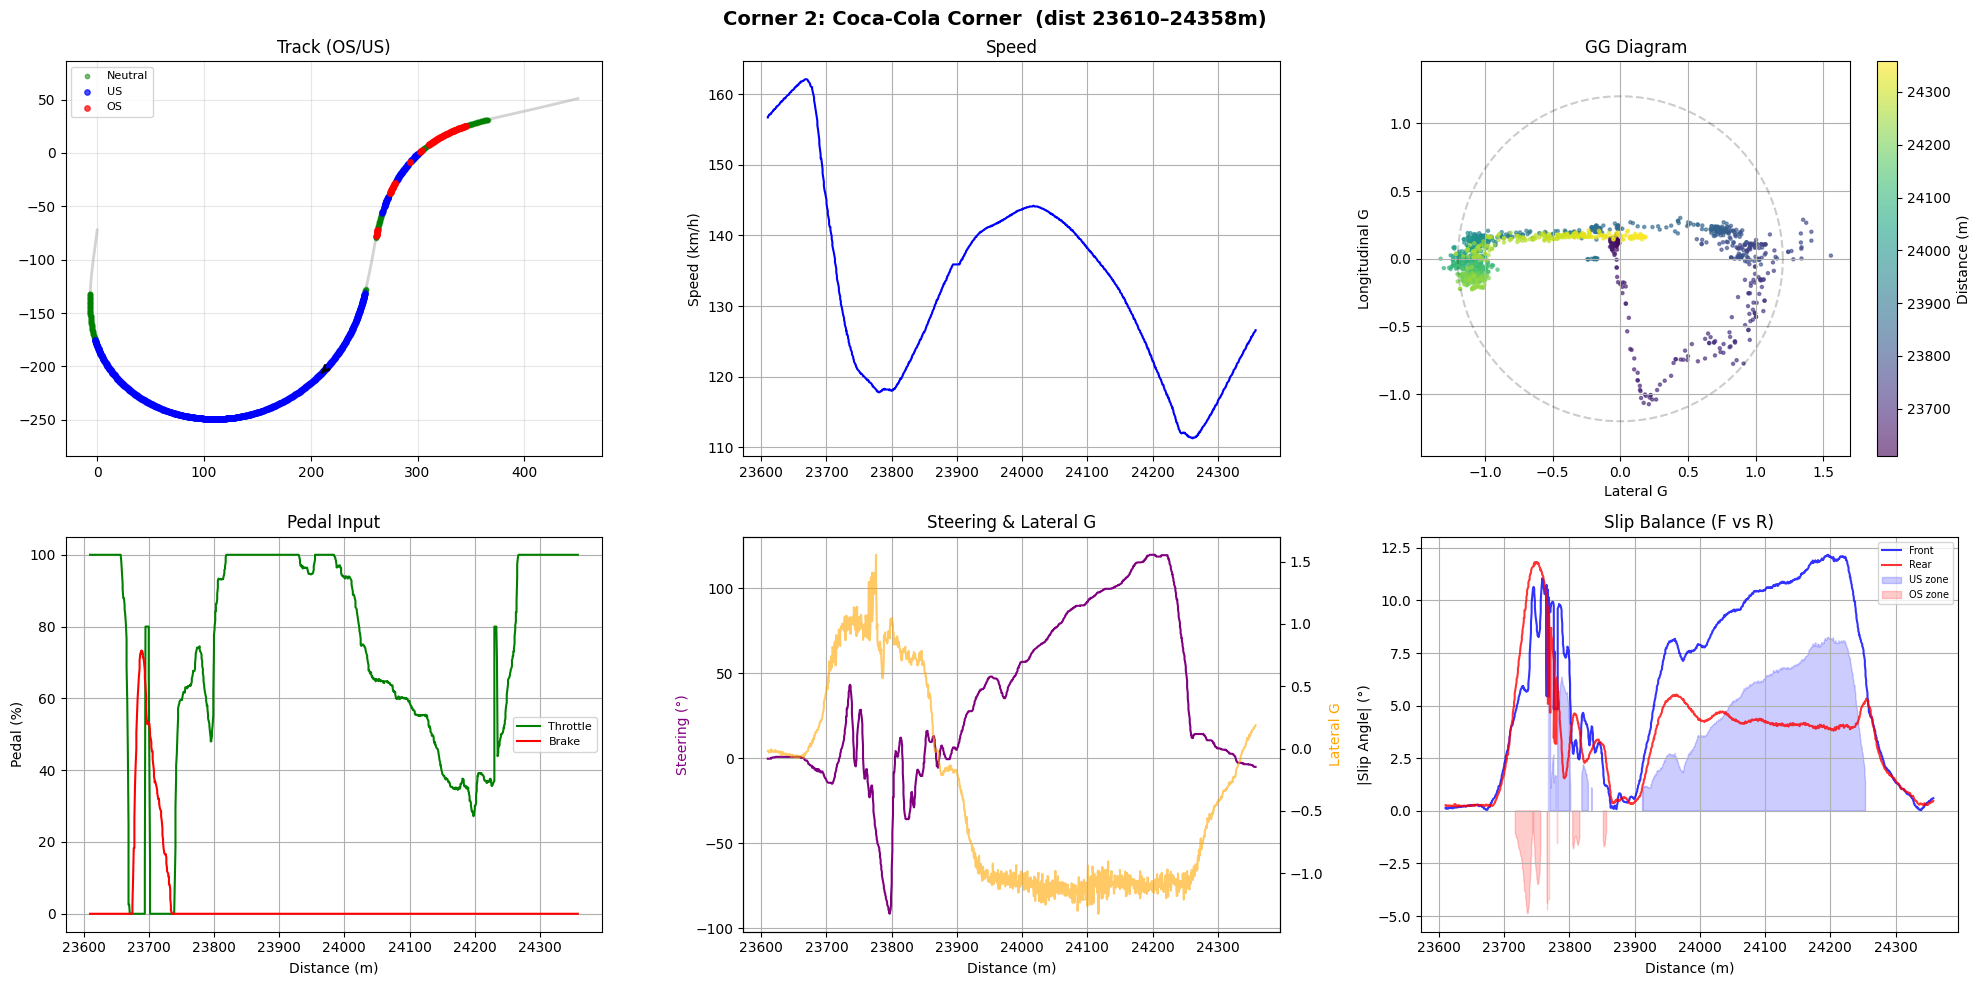

  [Coca-Cola Corner] Min Speed: 111 km/h | US: 68% | OS: 11% | Max |Steer|: 120° | Max Brake: 73%



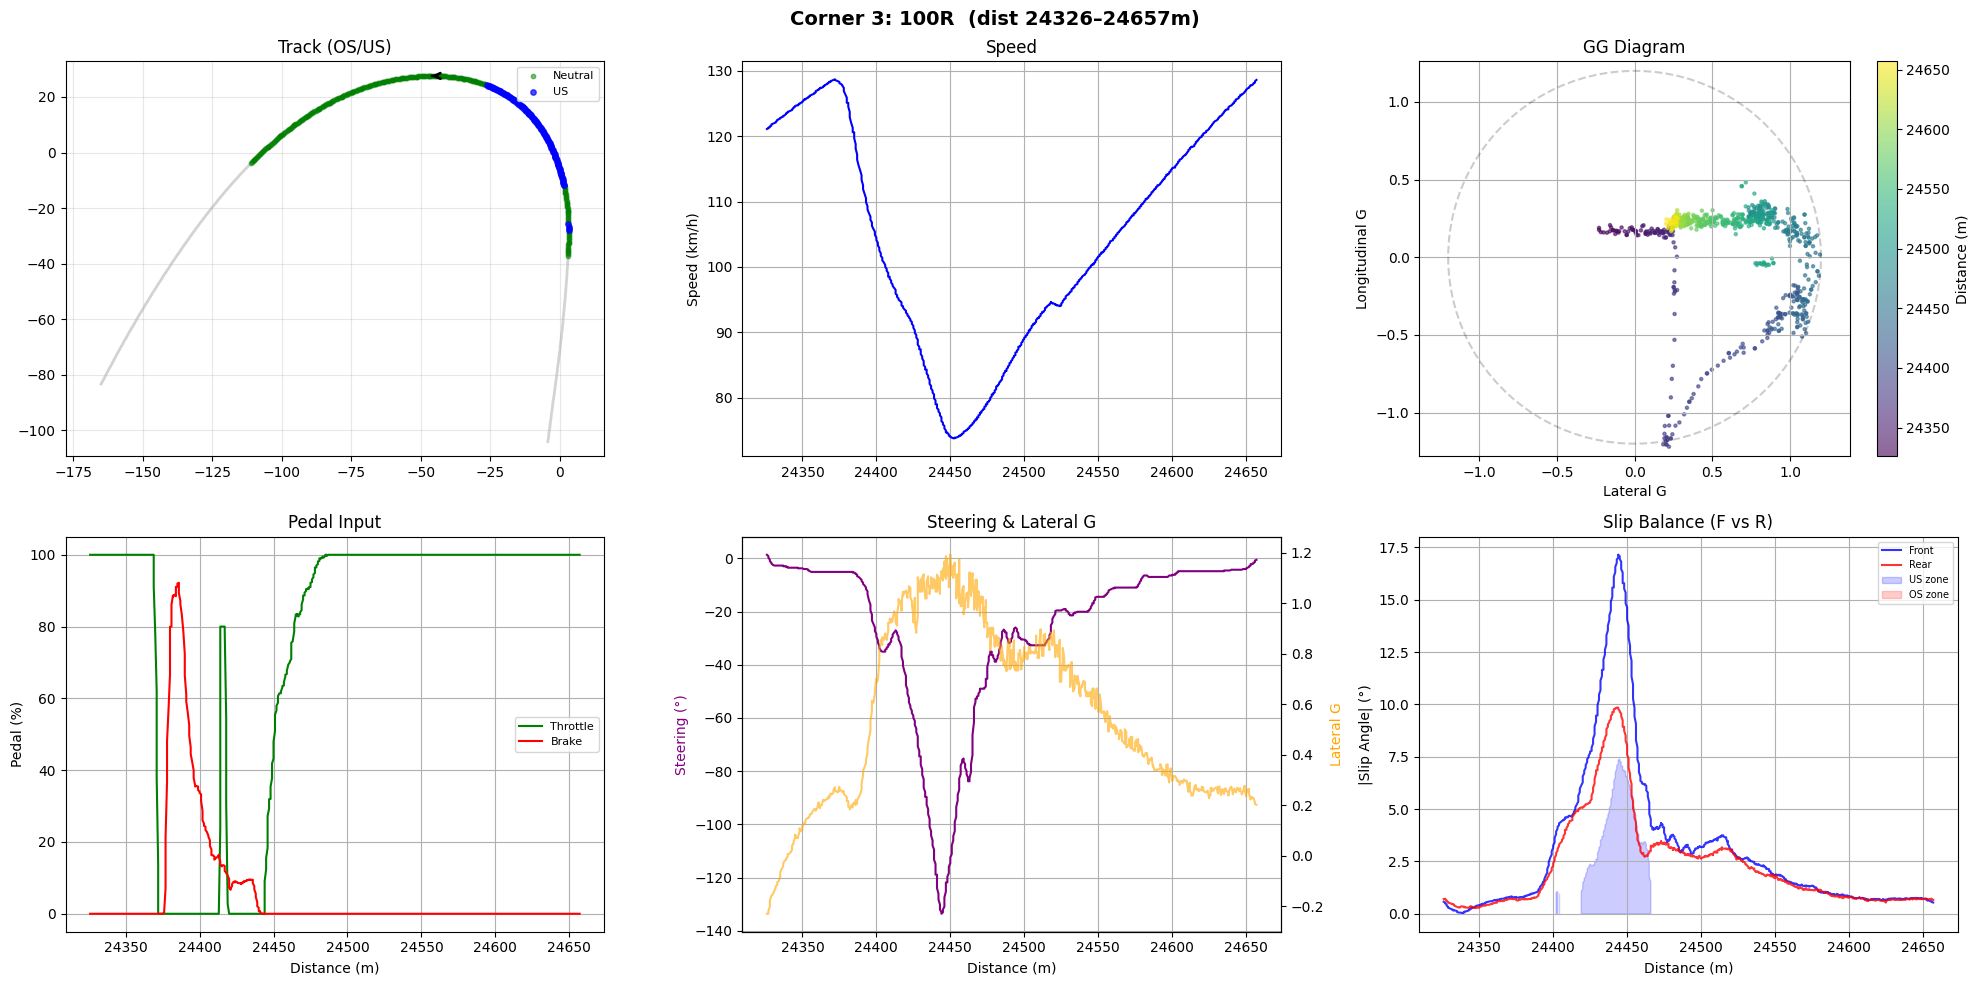

  [100R] Min Speed: 74 km/h | US: 33% | OS: 0% | Max |Steer|: 134° | Max Brake: 92%



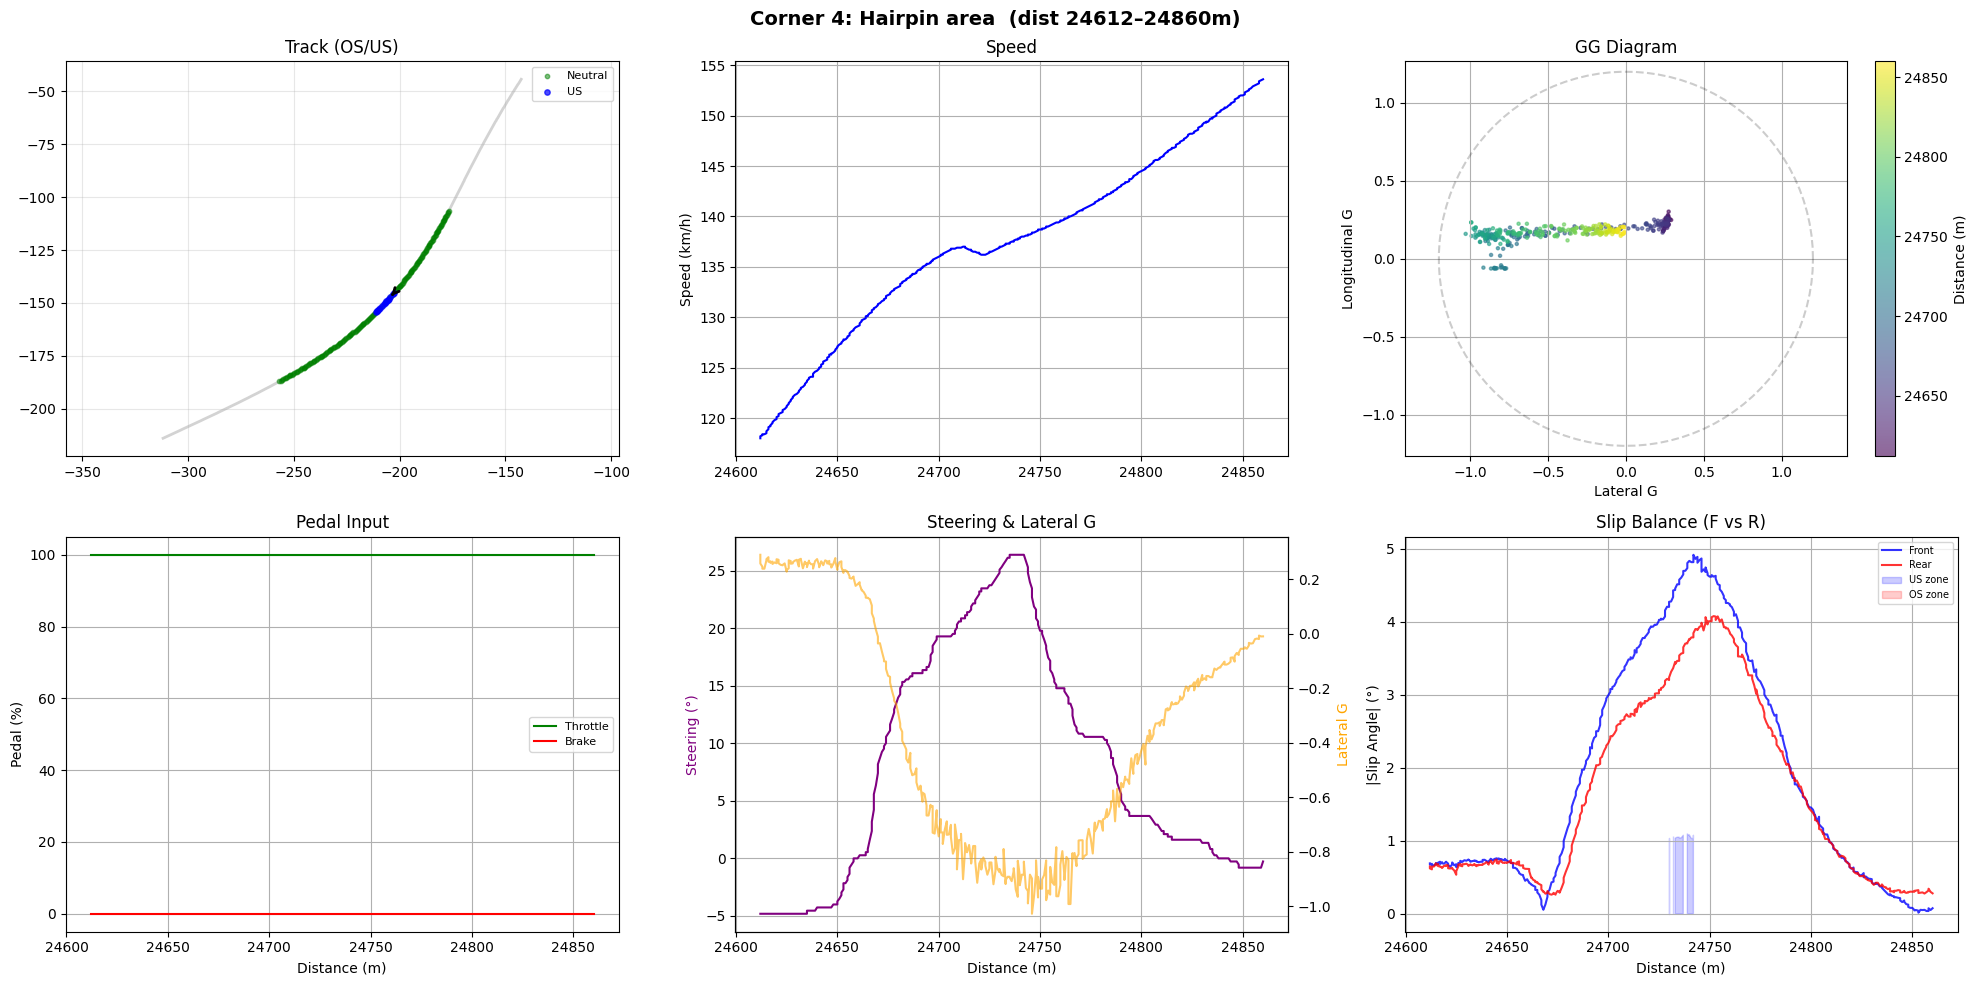

  [Hairpin area] Min Speed: 118 km/h | US: 9% | OS: 0% | Max |Steer|: 26° | Max Brake: 0%



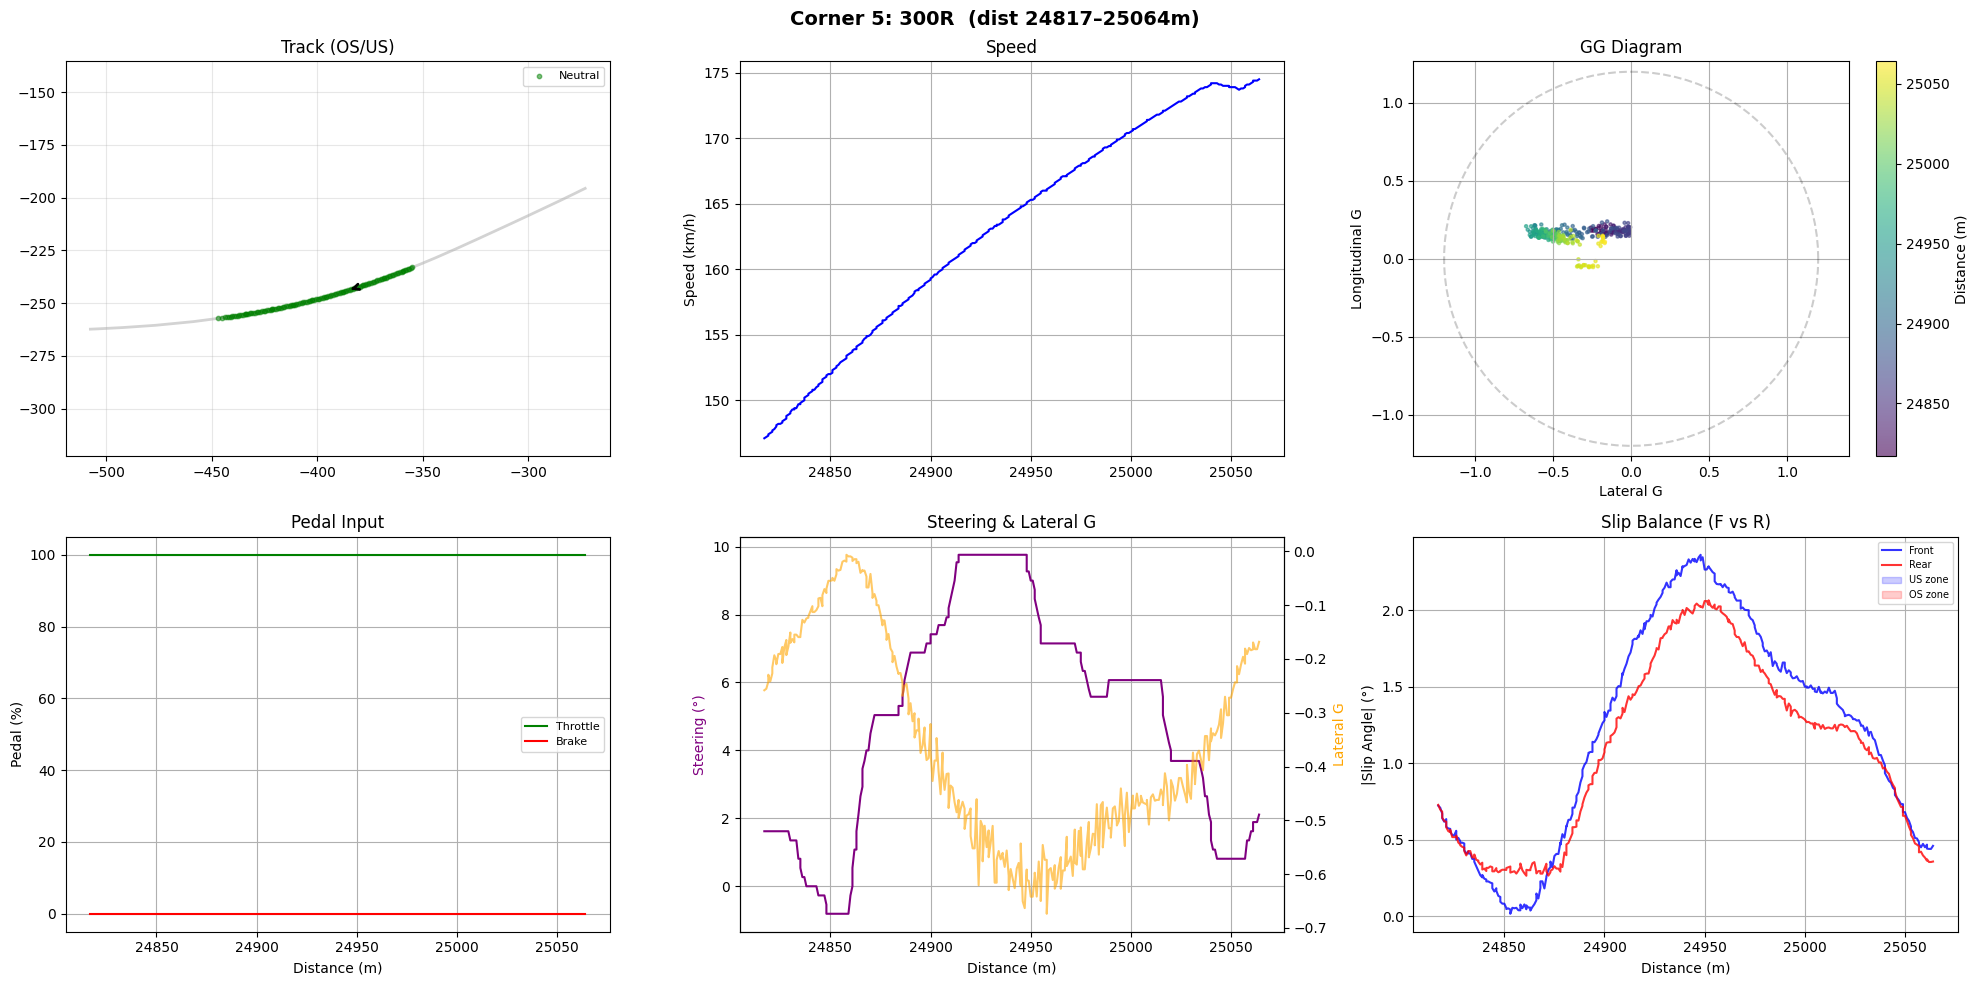

  [300R] Min Speed: 147 km/h | US: 0% | OS: 0% | Max |Steer|: 10° | Max Brake: 0%



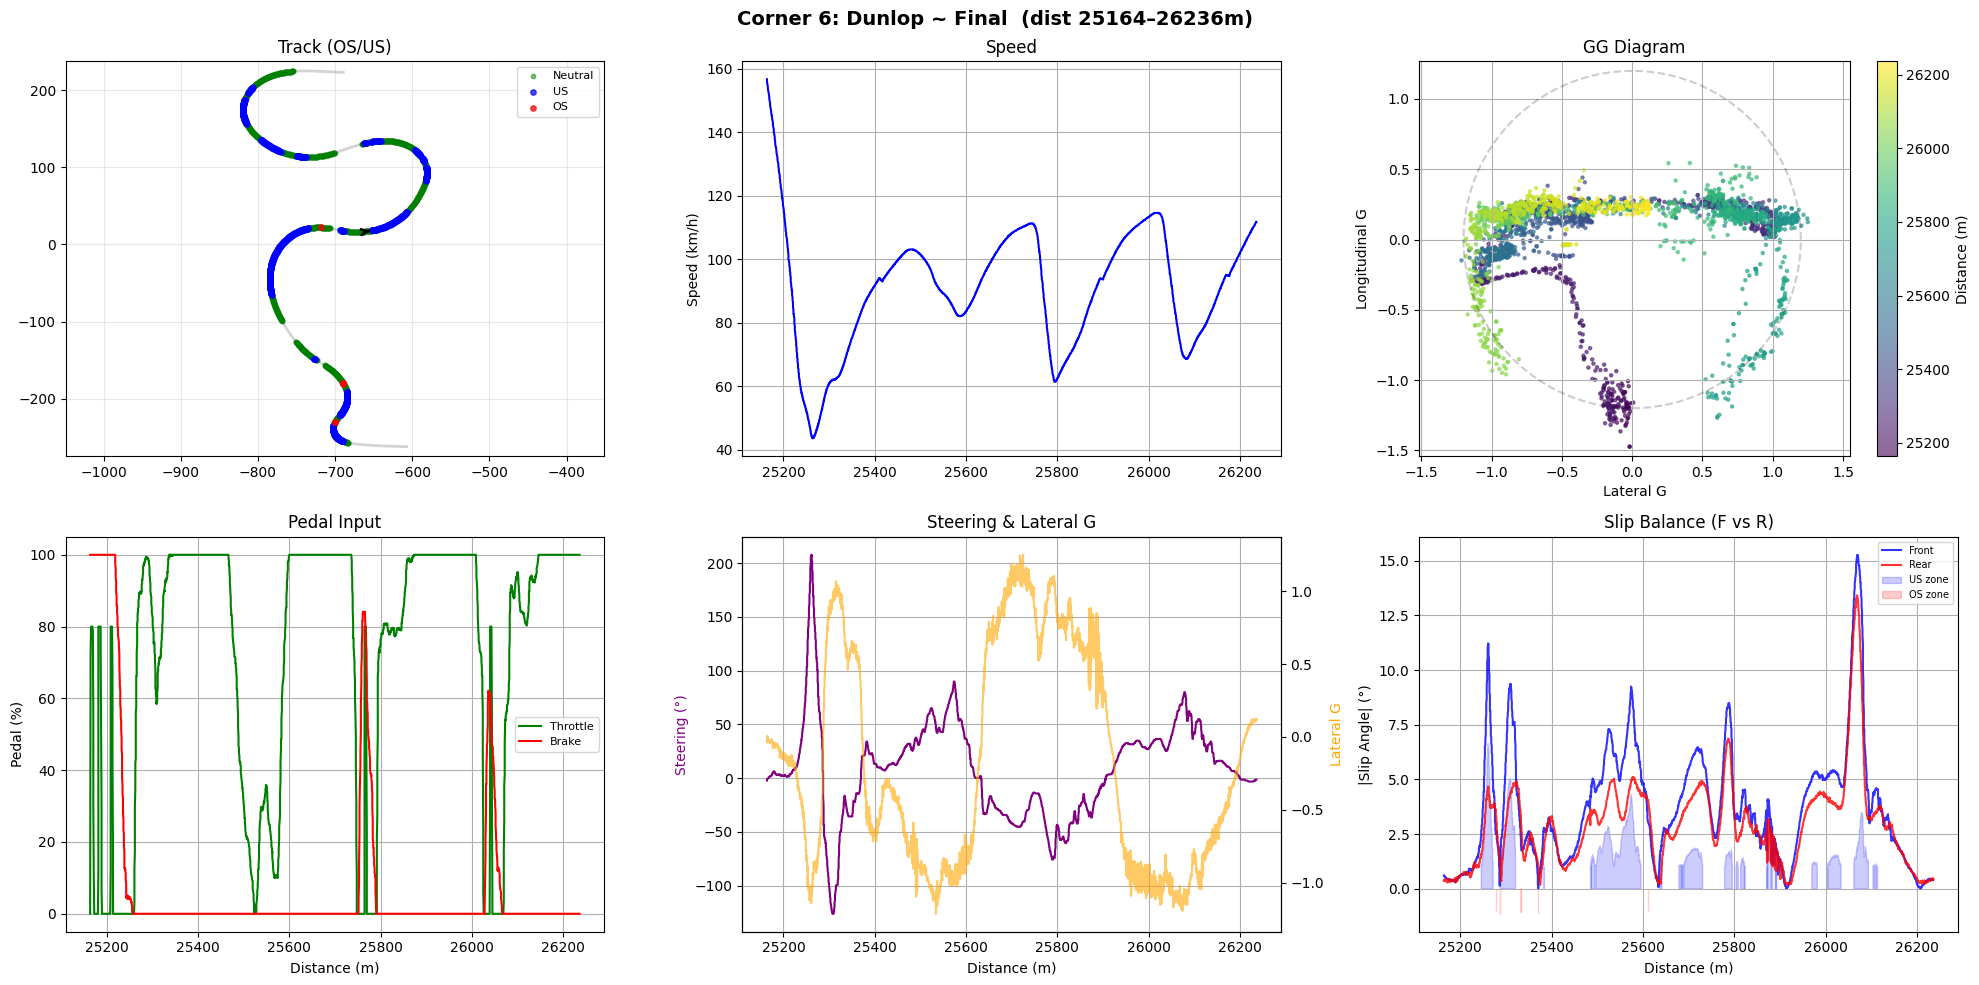

  [Dunlop ~ Final] Min Speed: 44 km/h | US: 43% | OS: 0% | Max |Steer|: 208° | Max Brake: 100%



In [31]:
# === コーナーごとの拡大分析 ===
min_slip = 1.5
balance_thresh = 1.0

for i, (s, e) in enumerate(corners):
    cname = fsw_names[i] if i < len(fsw_names) else f"Corner {i+1}"
    seg = df6c.loc[s:e].copy()

    fig, axes = plt.subplots(2, 3, figsize=(20, 10))
    fig.suptitle(f'Corner {i+1}: {cname}  (dist {seg["Corr Dist"].iloc[0]:.0f}–{seg["Corr Dist"].iloc[-1]:.0f}m)',
                 fontsize=14, fontweight='bold')

    # (0,0) トラックマップ + OS/US
    ax = axes[0, 0]
    front_slip = seg['Front_Slip']
    rear_slip = seg['Rear_Slip']
    slip_bal = seg['Slip_Balance']
    is_corn = (front_slip > min_slip) | (rear_slip > min_slip)
    is_us = is_corn & (slip_bal > balance_thresh)
    is_os = is_corn & (slip_bal < -balance_thresh)
    is_neut = is_corn & ~is_us & ~is_os

    ax.plot(seg['Car Coord X'], seg['Car Coord Y'], color='lightgray', linewidth=2, zorder=1)
    if is_neut.any():
        ax.scatter(seg.loc[is_neut, 'Car Coord X'], seg.loc[is_neut, 'Car Coord Y'],
                   c='green', s=10, alpha=0.5, label='Neutral', zorder=2)
    if is_us.any():
        ax.scatter(seg.loc[is_us, 'Car Coord X'], seg.loc[is_us, 'Car Coord Y'],
                   c='blue', s=15, alpha=0.7, label='US', zorder=3)
    if is_os.any():
        ax.scatter(seg.loc[is_os, 'Car Coord X'], seg.loc[is_os, 'Car Coord Y'],
                   c='red', s=15, alpha=0.7, label='OS', zorder=3)
    # 進行方向の矢印
    mid = len(seg) // 2
    ax.annotate('', xy=(seg['Car Coord X'].iloc[mid+5], seg['Car Coord Y'].iloc[mid+5]),
                xytext=(seg['Car Coord X'].iloc[mid], seg['Car Coord Y'].iloc[mid]),
                arrowprops=dict(arrowstyle='->', color='black', lw=2))
    ax.set_title('Track (OS/US)')
    ax.axis('equal')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # (0,1) 速度
    ax = axes[0, 1]
    ax.plot(seg['Corr Dist'], seg['Corr Speed'], color='blue', linewidth=1.5)
    ax.set_ylabel('Speed (km/h)')
    ax.set_title('Speed')
    ax.grid(True)

    # (0,2) GGダイアグラム（このコーナーのみ）
    ax = axes[0, 2]
    sc = ax.scatter(seg['CG Accel Lateral'], seg['CG Accel Longitudinal'],
                    c=seg['Corr Dist'], cmap='viridis', s=5, alpha=0.6)
    plt.colorbar(sc, ax=ax, label='Distance (m)')
    theta = np.linspace(0, 2*np.pi, 100)
    ax.plot(1.2*np.cos(theta), 1.2*np.sin(theta), 'k--', alpha=0.2)
    ax.set_xlabel('Lateral G')
    ax.set_ylabel('Longitudinal G')
    ax.set_title('GG Diagram')
    ax.axis('equal')
    ax.grid(True)

    # (1,0) ペダル入力
    ax = axes[1, 0]
    ax.plot(seg['Corr Dist'], seg['Throttle Pos'], color='green', label='Throttle', linewidth=1.5)
    ax.plot(seg['Corr Dist'], seg['Brake Pos'], color='red', label='Brake', linewidth=1.5)
    ax.set_ylabel('Pedal (%)')
    ax.set_xlabel('Distance (m)')
    ax.set_title('Pedal Input')
    ax.legend(fontsize=8)
    ax.grid(True)

    # (1,1) ステアリング + 横G
    ax = axes[1, 1]
    ax.plot(seg['Corr Dist'], seg['Steering Angle'], color='purple', label='Steering', linewidth=1.5)
    ax2 = ax.twinx()
    ax2.plot(seg['Corr Dist'], seg['CG Accel Lateral'], color='orange', alpha=0.6, label='Lat G')
    ax.set_ylabel('Steering (°)', color='purple')
    ax2.set_ylabel('Lateral G', color='orange')
    ax.set_xlabel('Distance (m)')
    ax.set_title('Steering & Lateral G')
    ax.grid(True)

    # (1,2) スリップバランス
    ax = axes[1, 2]
    ax.plot(seg['Corr Dist'], seg['Front_Slip'], color='blue', label='Front', alpha=0.8)
    ax.plot(seg['Corr Dist'], seg['Rear_Slip'], color='red', label='Rear', alpha=0.8)
    ax.fill_between(seg['Corr Dist'], seg['Slip_Balance'], 0,
                    where=seg['Slip_Balance'] > balance_thresh,
                    color='blue', alpha=0.2, label='US zone')
    ax.fill_between(seg['Corr Dist'], seg['Slip_Balance'], 0,
                    where=seg['Slip_Balance'] < -balance_thresh,
                    color='red', alpha=0.2, label='OS zone')
    ax.set_ylabel('|Slip Angle| (°)')
    ax.set_xlabel('Distance (m)')
    ax.set_title('Slip Balance (F vs R)')
    ax.legend(fontsize=7)
    ax.grid(True)

    plt.tight_layout()
    plt.show()

    # サマリー出力
    us_pct = is_us.sum() / max(is_corn.sum(), 1) * 100
    os_pct = is_os.sum() / max(is_corn.sum(), 1) * 100
    print(f"  [{cname}] Min Speed: {seg['Corr Speed'].min():.0f} km/h | "
          f"US: {us_pct:.0f}% | OS: {os_pct:.0f}% | "
          f"Max |Steer|: {seg['Steering Angle'].abs().max():.0f}° | "
          f"Max Brake: {seg['Brake Pos'].max():.0f}%")
    print()

比較対象ラップ: 6  (Best: Lap 7 = 131.96s)
  Lap 2: 137.82s 
  Lap 3: 133.40s 
  Lap 4: 133.72s 
  Lap 5: 133.79s 
  Lap 6: 133.42s 
  Lap 7: 131.96s <-- BEST


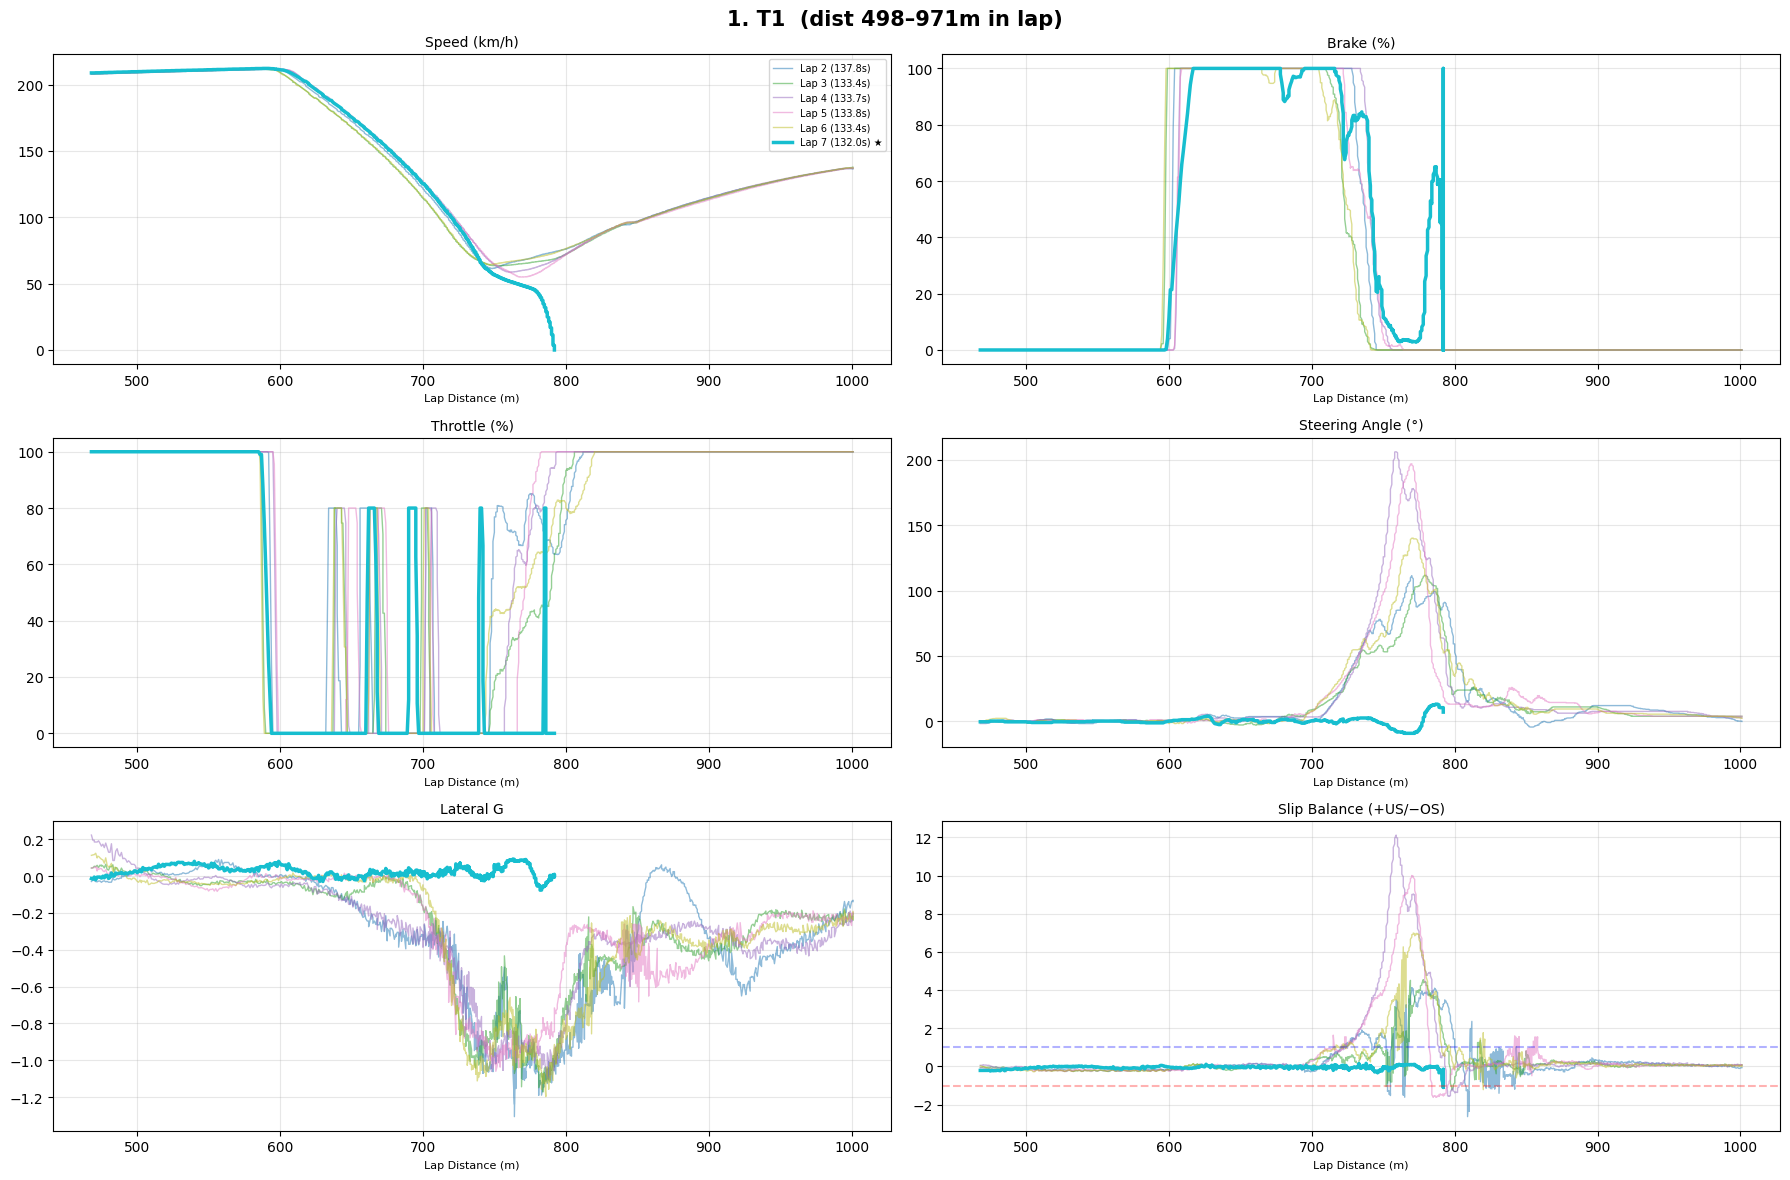

  Lap        Time  MinSpd   BrkPt  MaxSteer   US%   OS%
  --------------------------------------------------
  Lap 2    137.8s     61    602m      111°   23%    3%
  Lap 3    133.4s     64    597m      112°   13%    1%
  Lap 4    133.7s     59    605m      206°   22%    3%
  Lap 5    133.8s     55    605m      197°   22%    4%
  Lap 6    133.4s     64    595m      140°   18%    0%
  Lap 7    132.0s      0    600m       13°    0%    1% ★



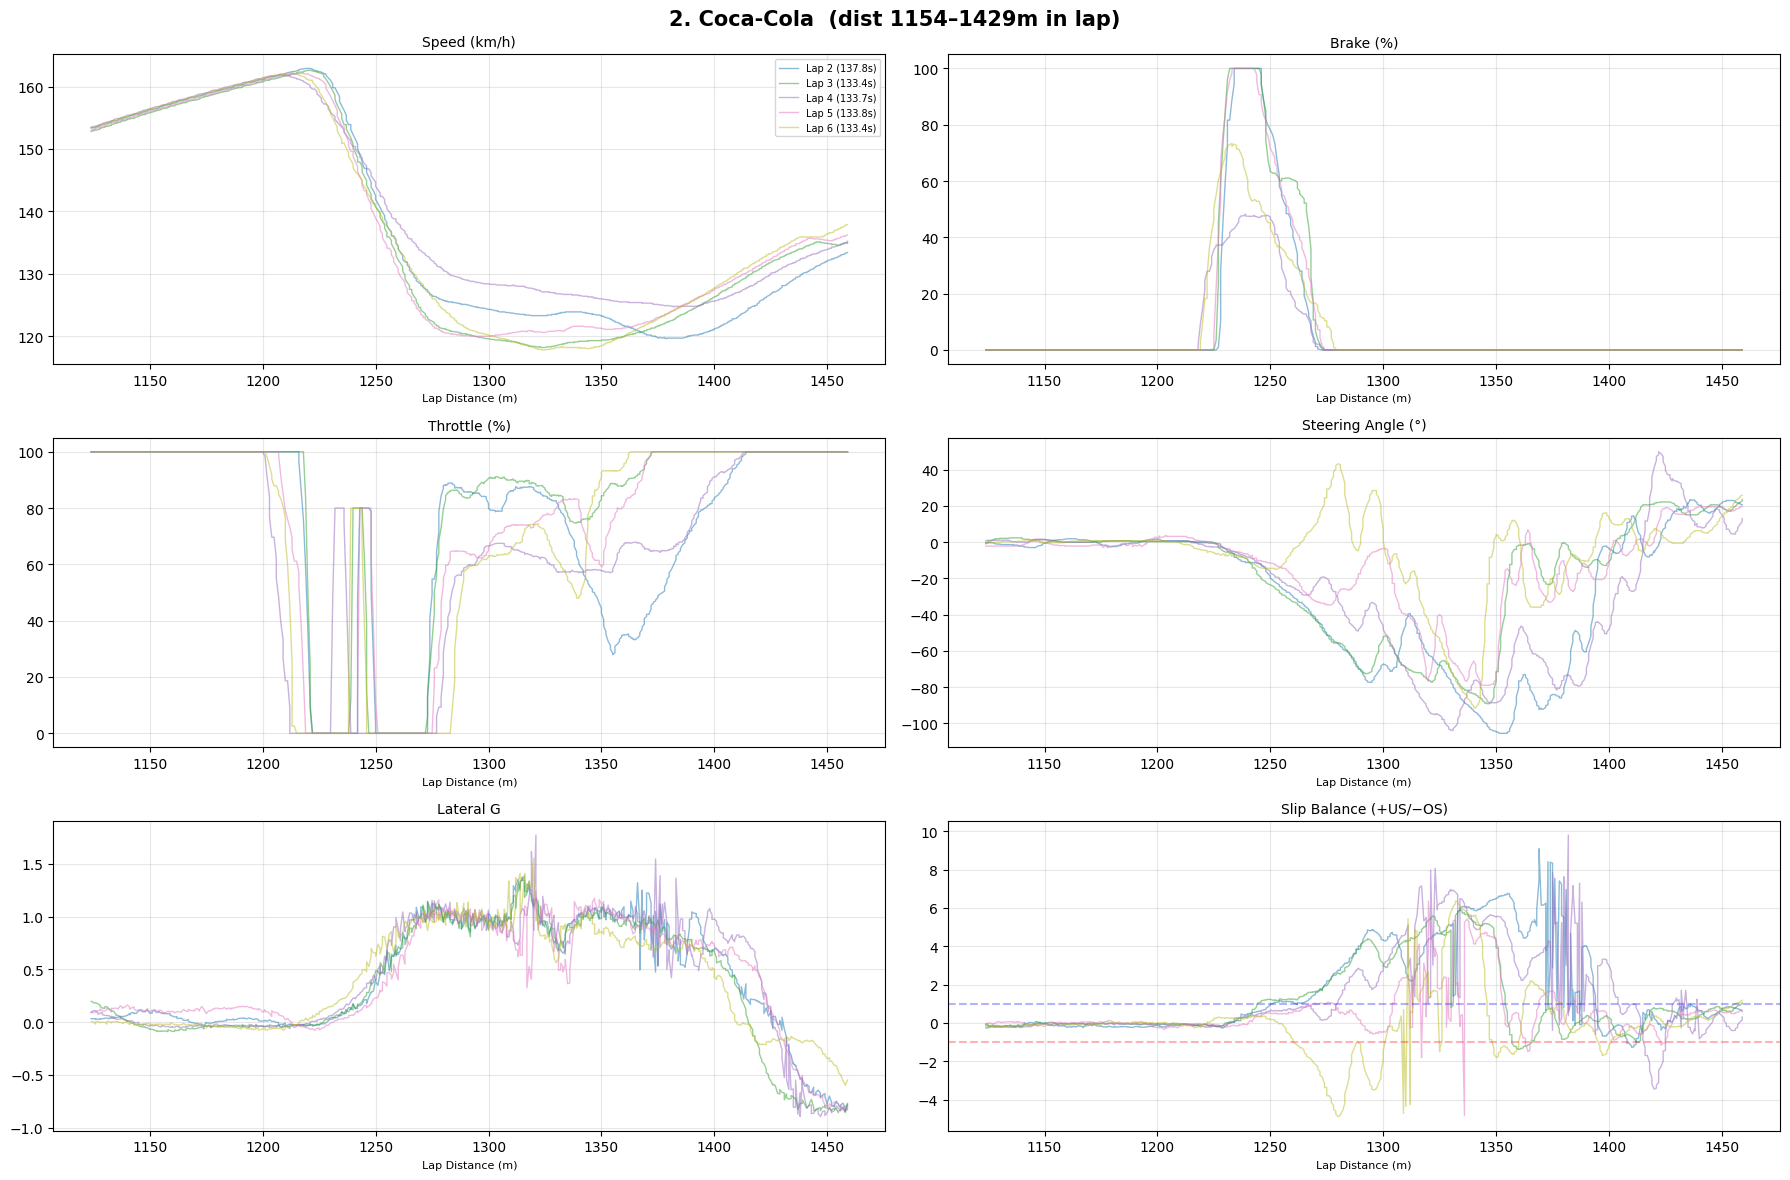

  Lap        Time  MinSpd   BrkPt  MaxSteer   US%   OS%
  --------------------------------------------------
  Lap 2    137.8s    120   1228m      105°   44%    1%
  Lap 3    133.4s    118   1227m       89°   36%    3%
  Lap 4    133.7s    125   1219m      104°   40%    3%
  Lap 5    133.8s    120   1225m       79°   19%    2%
  Lap 6    133.4s    118   1220m       92°   16%   20%



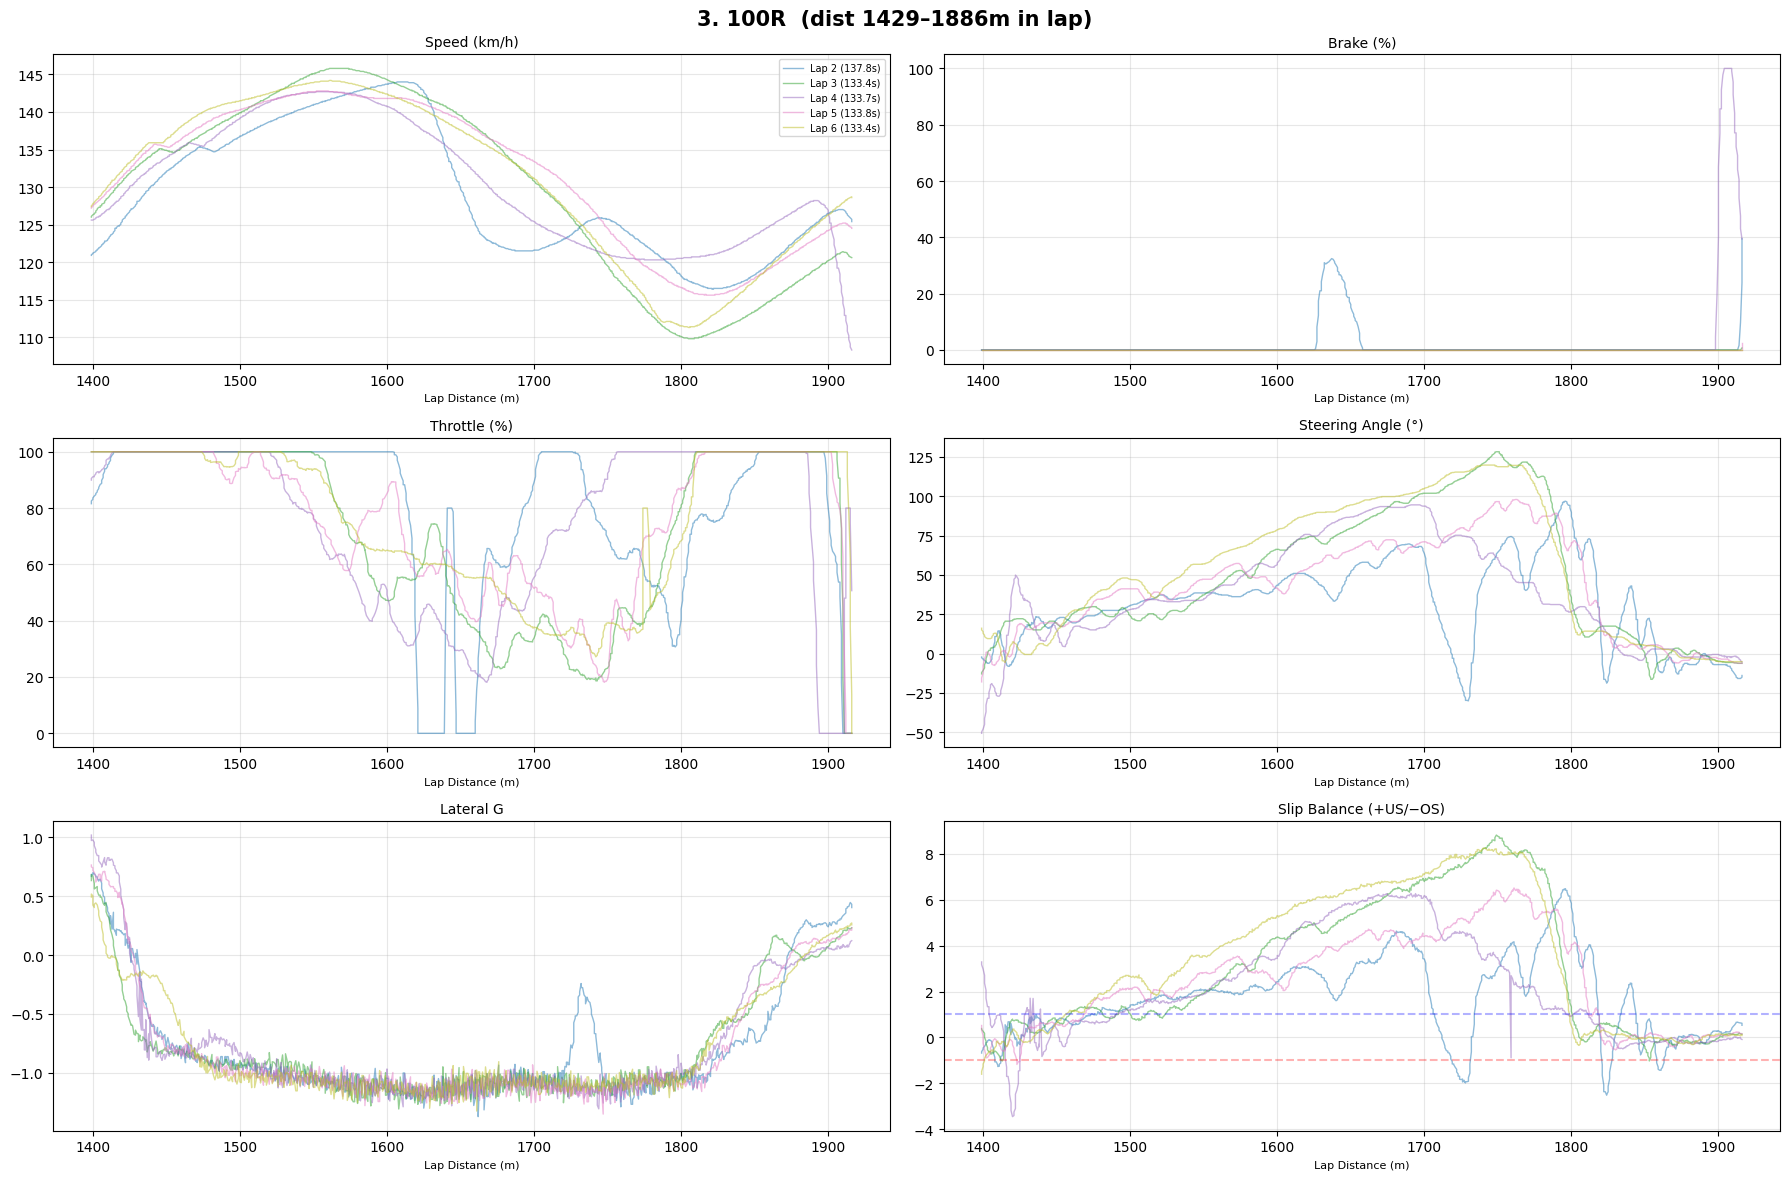

  Lap        Time  MinSpd   BrkPt  MaxSteer   US%   OS%
  --------------------------------------------------
  Lap 2    137.8s    116   1627m       97°   62%    6%
  Lap 3    133.4s    110    nanm      128°   59%    0%
  Lap 4    133.7s    108   1899m       94°   62%    2%
  Lap 5    133.8s    116    nanm       98°   66%    0%
  Lap 6    133.4s    111    nanm      120°   64%    1%



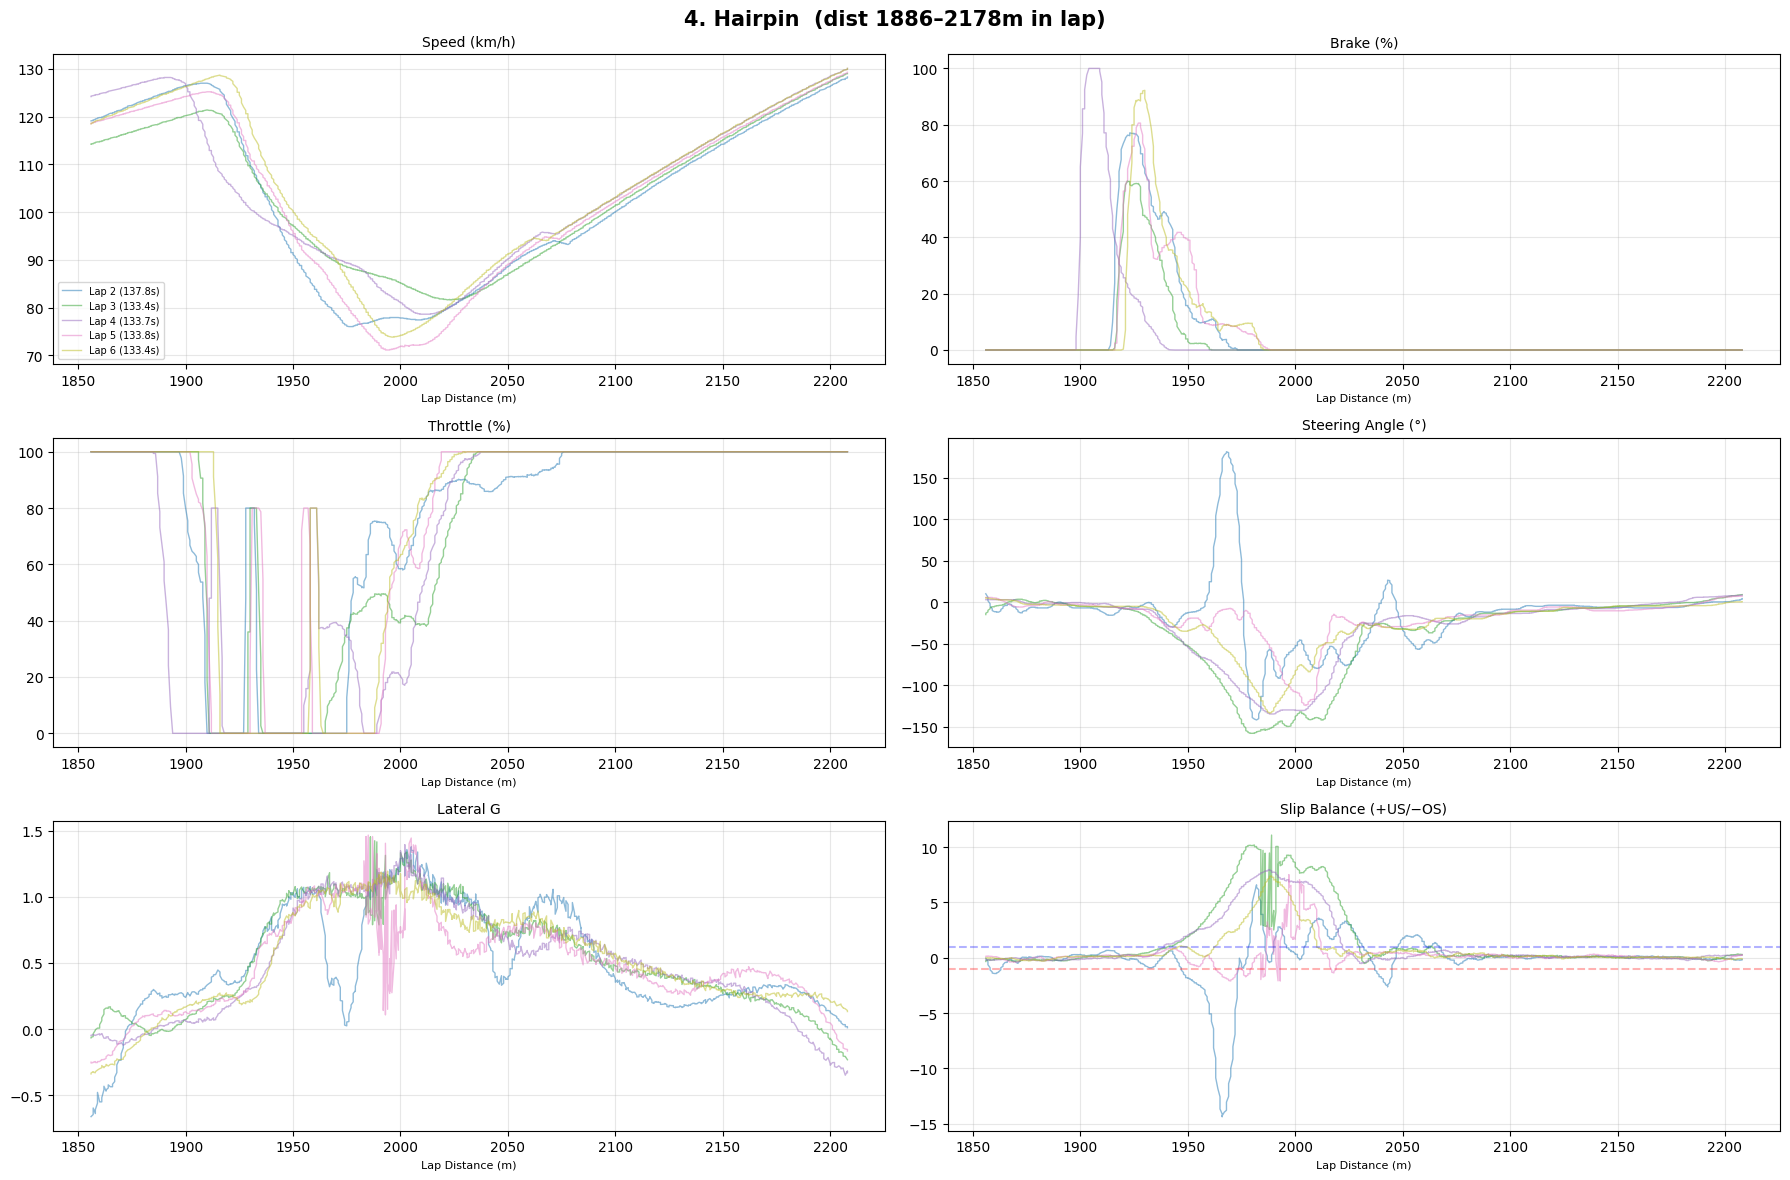

  Lap        Time  MinSpd   BrkPt  MaxSteer   US%   OS%
  --------------------------------------------------
  Lap 2    137.8s     76   1915m      181°   20%   13%
  Lap 3    133.4s     82   1917m      158°   29%    0%
  Lap 4    133.7s     79   1899m      135°   28%    0%
  Lap 5    133.8s     71   1917m      124°    9%    7%
  Lap 6    133.4s     74   1921m      134°   18%    0%



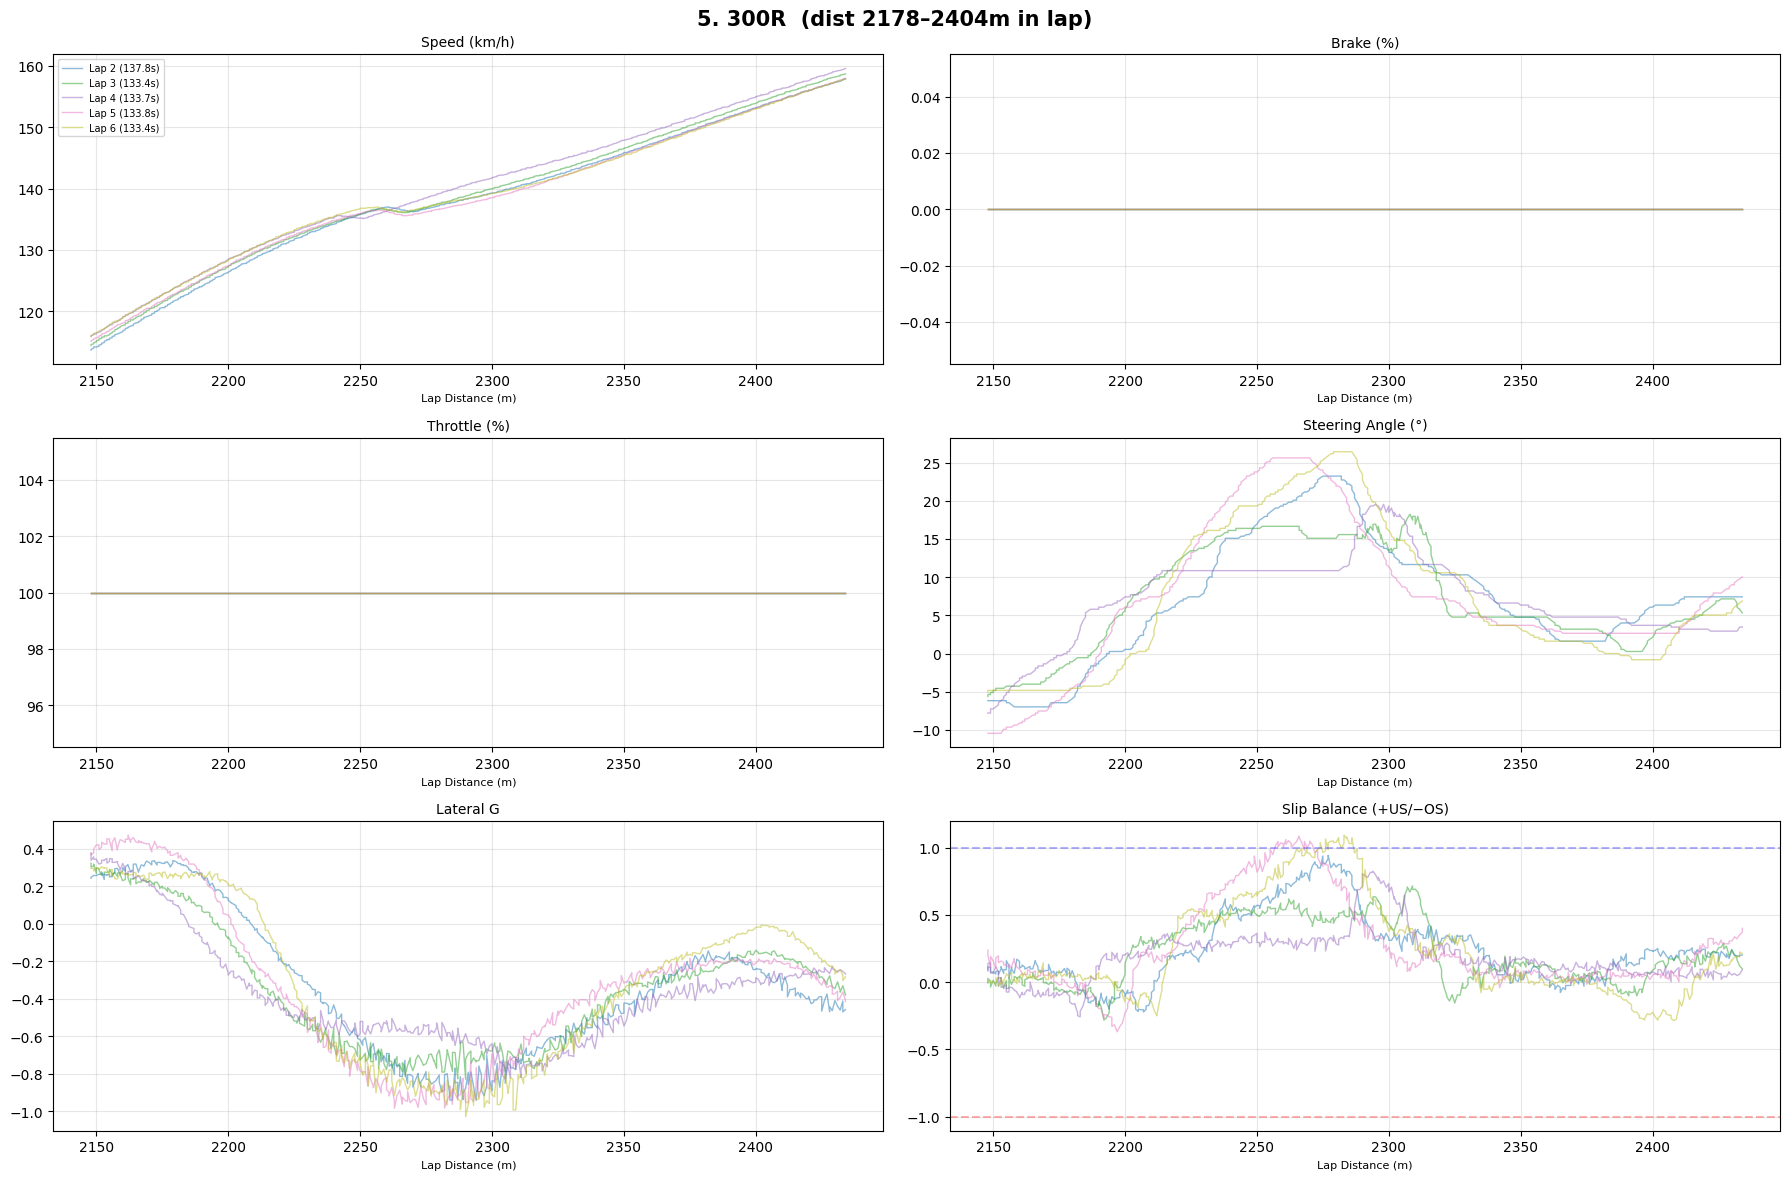

  Lap        Time  MinSpd   BrkPt  MaxSteer   US%   OS%
  --------------------------------------------------
  Lap 2    137.8s    114    nanm       23°    0%    0%
  Lap 3    133.4s    114    nanm       18°    0%    0%
  Lap 4    133.7s    116    nanm       20°    0%    0%
  Lap 5    133.8s    115    nanm       26°    5%    0%
  Lap 6    133.4s    116    nanm       26°    4%    0%



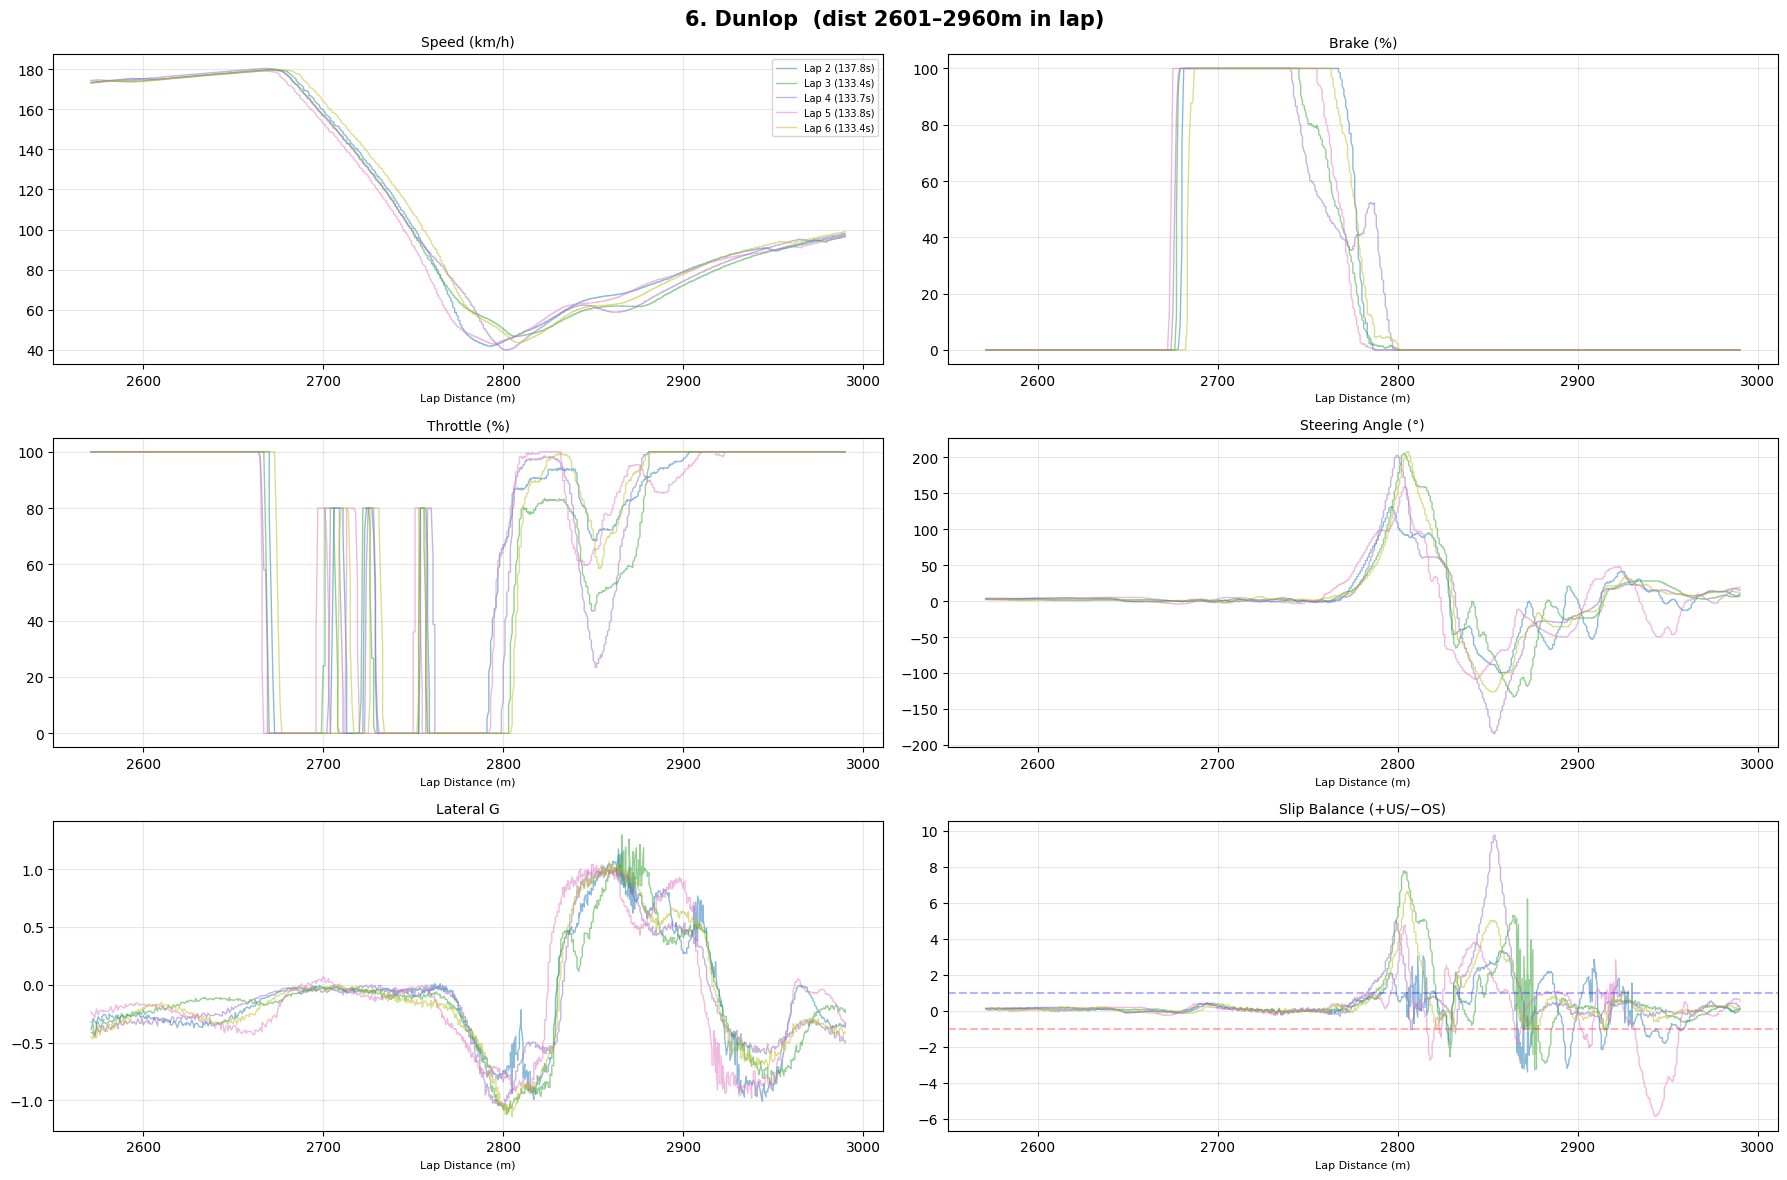

  Lap        Time  MinSpd   BrkPt  MaxSteer   US%   OS%
  --------------------------------------------------
  Lap 2    137.8s     42   2679m      131°   22%   10%
  Lap 3    133.4s     47   2677m      205°   25%    5%
  Lap 4    133.7s     40   2675m      202°   23%    0%
  Lap 5    133.8s     43   2673m      159°   21%   11%
  Lap 6    133.4s     44   2683m      208°   24%    1%



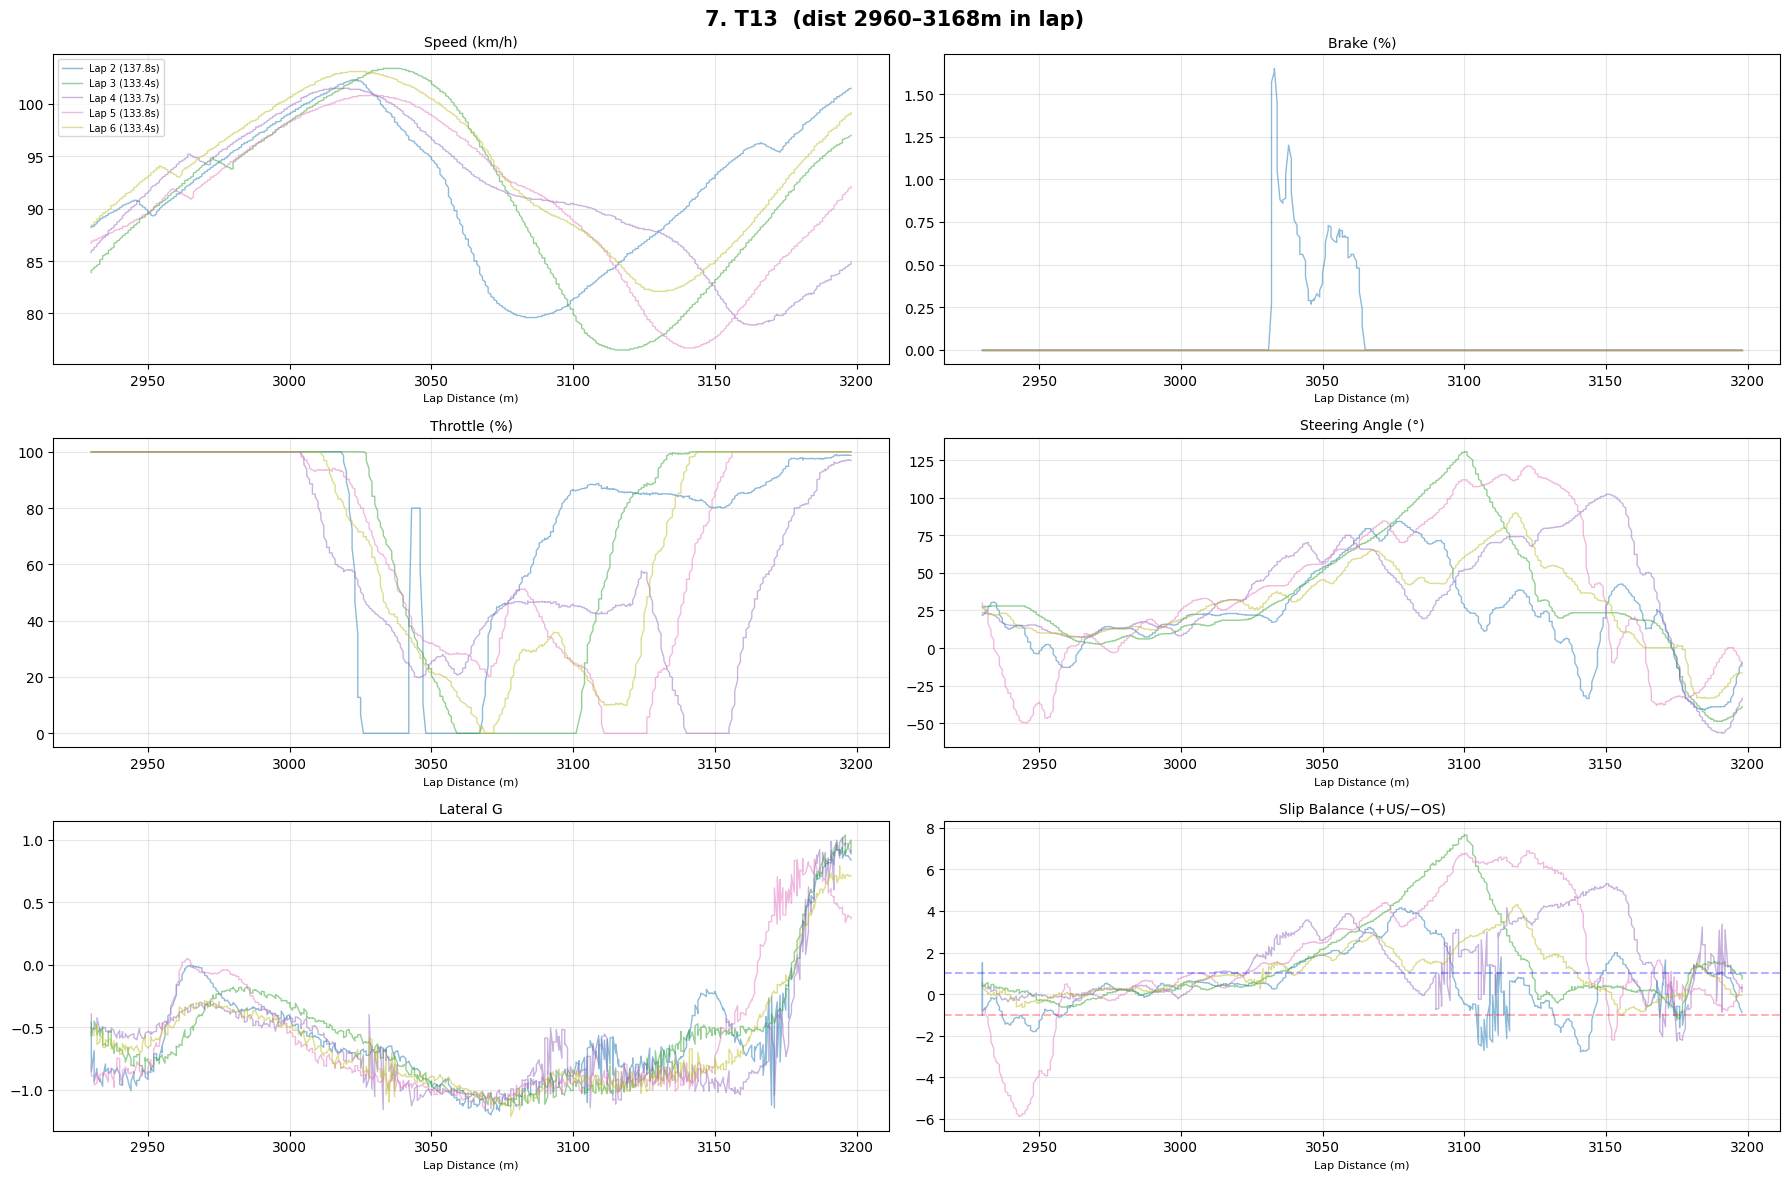

  Lap        Time  MinSpd   BrkPt  MaxSteer   US%   OS%
  --------------------------------------------------
  Lap 2    137.8s     80    nanm       84°   30%   16%
  Lap 3    133.4s     76    nanm      131°   40%    0%
  Lap 4    133.7s     79    nanm      102°   54%    2%
  Lap 5    133.8s     77    nanm      121°   48%   11%
  Lap 6    133.4s     82    nanm       90°   43%    0%



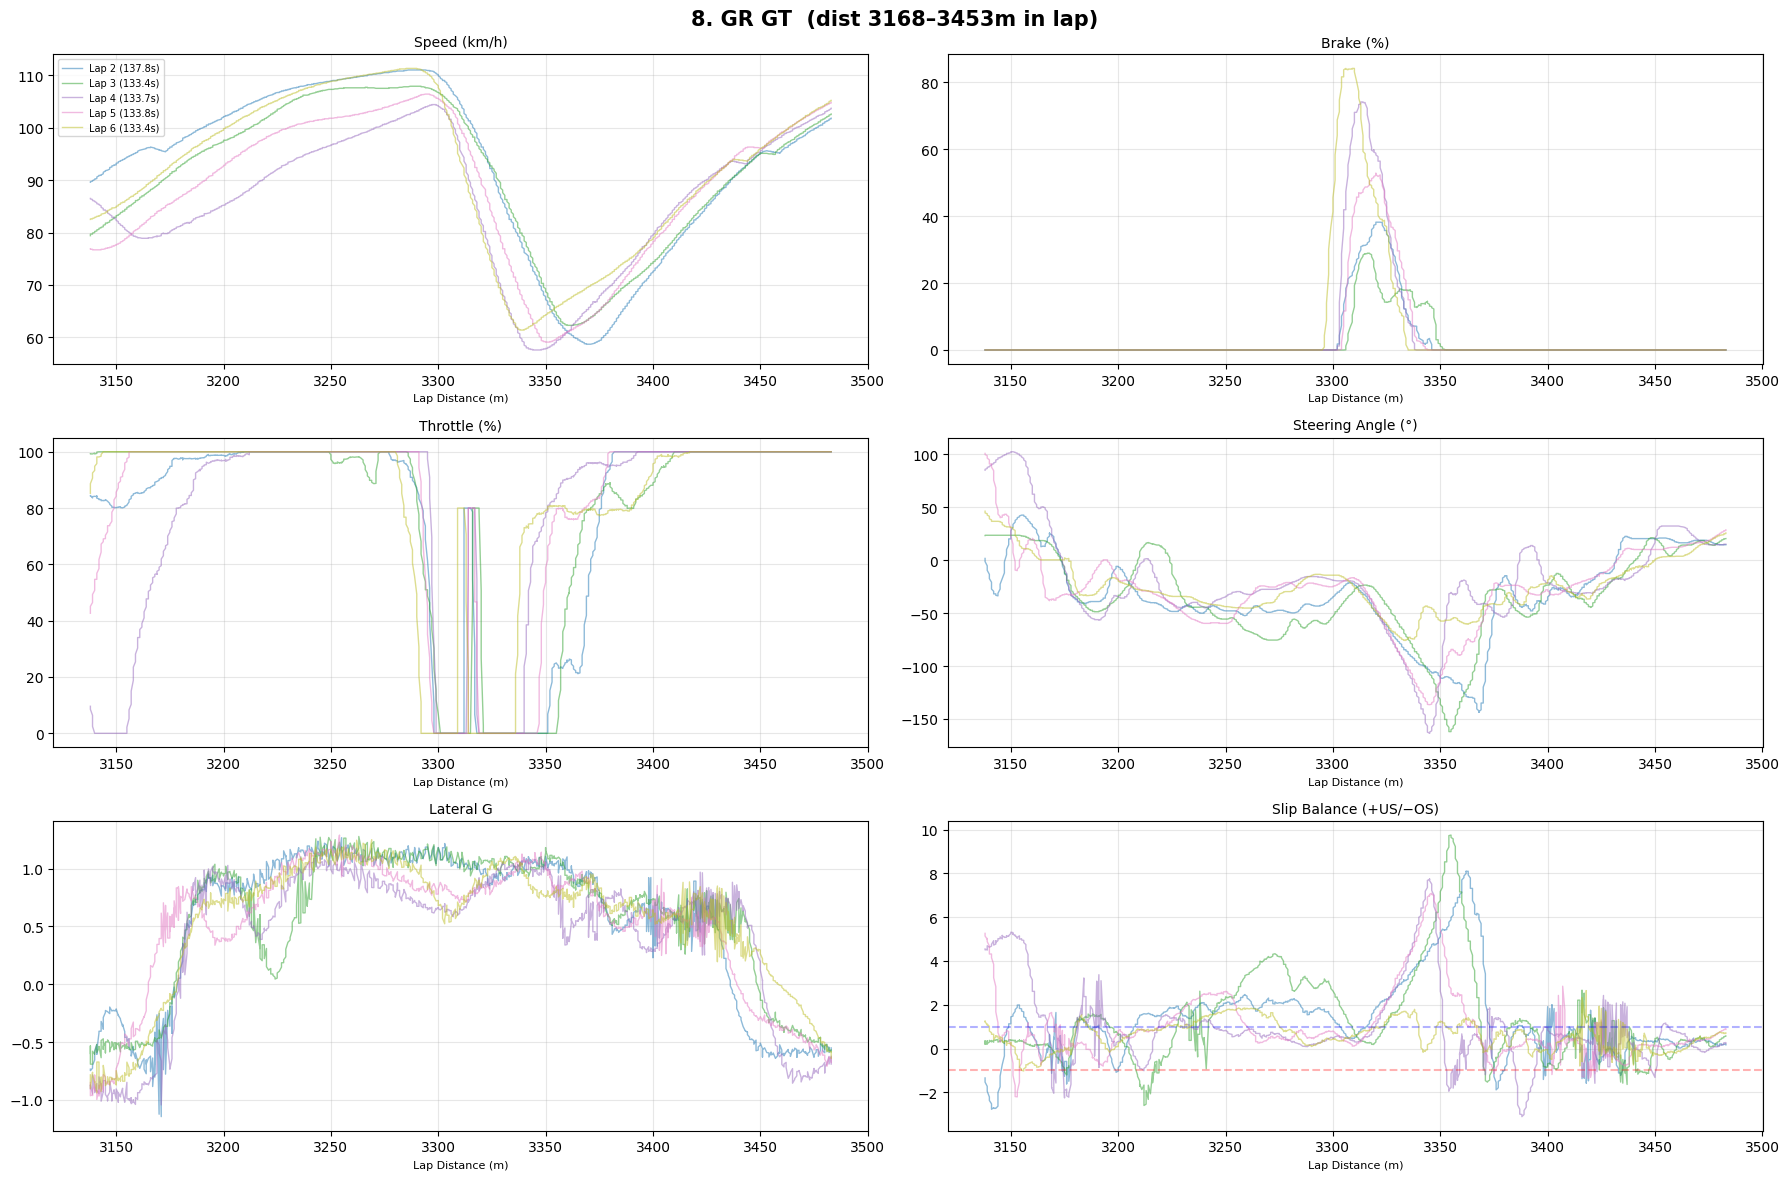

  Lap        Time  MinSpd   BrkPt  MaxSteer   US%   OS%
  --------------------------------------------------
  Lap 2    137.8s     59   3304m      144°   50%    7%
  Lap 3    133.4s     62   3308m      162°   45%    6%
  Lap 4    133.7s     58   3303m      164°   34%    8%
  Lap 5    133.8s     59   3305m      137°   33%    2%
  Lap 6    133.4s     61   3297m       76°   28%    0%



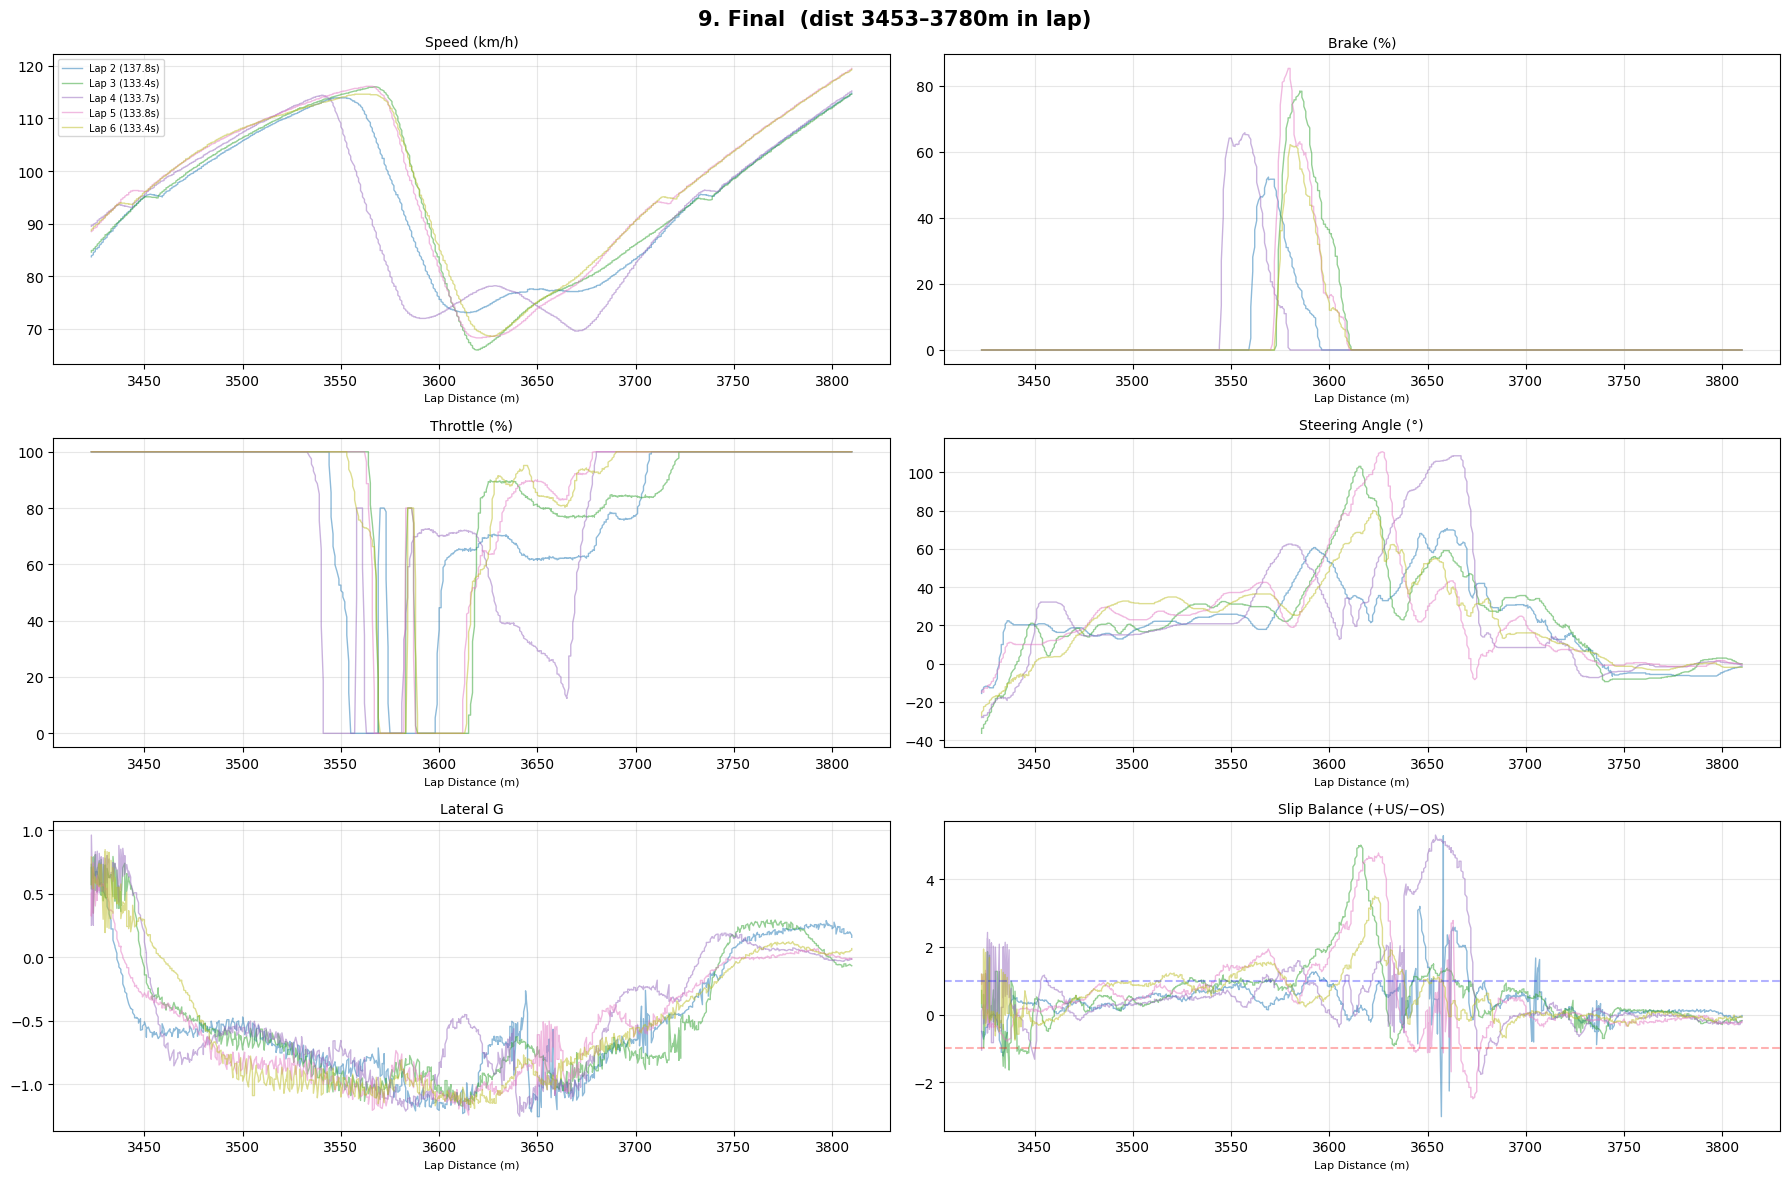

  Lap        Time  MinSpd   BrkPt  MaxSteer   US%   OS%
  --------------------------------------------------
  Lap 2    137.8s     73   3560m       71°   10%    1%
  Lap 3    133.4s     66   3573m      103°   24%    2%
  Lap 4    133.7s     70   3545m      109°   24%    2%
  Lap 5    133.8s     68   3572m      111°   24%    4%
  Lap 6    133.4s     69   3573m       80°   23%    0%

全コーナー横断サマリー: ベストラップ vs 平均
Corner       Best MinSpd  Avg MinSpd   Diff  Best BrkPt   Avg BrkPt
-----------------------------------------------------------------
T1                    0         61   -61        600m        601m


In [46]:
# === 全9コーナー ラップ間比較分析 ===

# Lap 6 のラップ内相対距離でコーナー区間を定義
lap6_dist_start = df6['Corr Dist'].iloc[0]
corner_rel = []  # (rel_start, rel_end) for each corner
for cs, ce in corners:
    rel_s = df6c.loc[cs, 'Corr Dist'] - lap6_dist_start
    rel_e = df6c.loc[ce, 'Corr Dist'] - lap6_dist_start
    corner_rel.append((rel_s, rel_e))

# 有効ラップを抽出（ラップタイム 130–200s）
target_laps = {}
for name, lap_df in laps.items():
    lt = lap_df['Last Lap Time'].iloc[-1]
    if 130 < lt < 200:
        lap_df = lap_df.copy()
        lap_df['Lap_Dist'] = lap_df['Corr Dist'] - lap_df['Corr Dist'].iloc[0]
        lap_df['Front_Slip'] = (lap_df['Tire Slip Angle FL'].abs() + lap_df['Tire Slip Angle FR'].abs()) / 2
        lap_df['Rear_Slip'] = (lap_df['Tire Slip Angle RL'].abs() + lap_df['Tire Slip Angle RR'].abs()) / 2
        lap_df['Slip_Balance'] = lap_df['Front_Slip'] - lap_df['Rear_Slip']
        target_laps[name] = (lap_df, lt)

best_lap_name = min(target_laps, key=lambda k: target_laps[k][1])
print(f"比較対象ラップ: {len(target_laps)}  (Best: {best_lap_name} = {target_laps[best_lap_name][1]:.2f}s)")
for name, (_, lt) in target_laps.items():
    print(f"  {name}: {lt:.2f}s {'<-- BEST' if name == best_lap_name else ''}")

# カラーマップ
lap_colors = {}
cmap = plt.cm.tab10
for i, name in enumerate(target_laps.keys()):
    lap_colors[name] = cmap(i / max(len(target_laps)-1, 1))

# === コーナーごとのラップ間比較 ===
summary_rows = []

for ci in range(len(corners)):
    cname = fsw_names[ci]
    rel_s, rel_e = corner_rel[ci]
    extra = 30  # 区間前後のマージン

    # 各ラップからこのコーナー区間を抽出
    valid = {}
    for name, (lap_df, lt) in target_laps.items():
        mask = (lap_df['Lap_Dist'] >= rel_s - extra) & (lap_df['Lap_Dist'] <= rel_e + extra)
        seg = lap_df[mask]
        if len(seg) > 10:
            valid[name] = (seg, lt)

    if len(valid) < 2:
        print(f"\n[{cname}] 比較可能なラップが不足 ({len(valid)})")
        continue

    # --- チャート: 3x2 ---
    fig, axes = plt.subplots(3, 2, figsize=(18, 12))
    fig.suptitle(f'{ci+1}. {cname}  (dist {rel_s:.0f}–{rel_e:.0f}m in lap)', fontsize=15, fontweight='bold')

    for name, (seg, lt) in valid.items():
        c = lap_colors[name]
        is_best = (name == best_lap_name)
        lw = 2.5 if is_best else 1.0
        alpha = 1.0 if is_best else 0.5
        label = f"{name} ({lt:.1f}s)" + (" ★" if is_best else "")
        d = seg['Lap_Dist']

        axes[0, 0].plot(d, seg['Corr Speed'], color=c, lw=lw, alpha=alpha, label=label)
        axes[0, 1].plot(d, seg['Brake Pos'], color=c, lw=lw, alpha=alpha, label=label)
        axes[1, 0].plot(d, seg['Throttle Pos'], color=c, lw=lw, alpha=alpha, label=label)
        axes[1, 1].plot(d, seg['Steering Angle'], color=c, lw=lw, alpha=alpha, label=label)
        axes[2, 0].plot(d, seg['CG Accel Lateral'], color=c, lw=lw, alpha=alpha, label=label)
        axes[2, 1].plot(d, seg['Slip_Balance'], color=c, lw=lw, alpha=alpha, label=label)

    titles = ['Speed (km/h)', 'Brake (%)', 'Throttle (%)',
              'Steering Angle (°)', 'Lateral G', 'Slip Balance (+US/−OS)']
    for i, ax in enumerate(axes.flat):
        ax.set_title(titles[i], fontsize=10)
        ax.grid(True, alpha=0.3)
        ax.set_xlabel('Lap Distance (m)', fontsize=8)
    axes[0, 0].legend(fontsize=7, loc='best')

    # Slip Balance にUS/OSゾーン表示
    axes[2, 1].axhline(y=1.0, color='blue', ls='--', alpha=0.3)
    axes[2, 1].axhline(y=-1.0, color='red', ls='--', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # --- サマリー ---
    print(f"  {'Lap':<8} {'Time':>6} {'MinSpd':>7} {'BrkPt':>7} {'MaxSteer':>9} {'US%':>5} {'OS%':>5}")
    print(f"  {'-'*50}")
    for name, (seg, lt) in valid.items():
        min_spd = seg['Corr Speed'].min()
        brk = seg[seg['Brake Pos'] > 5]
        brk_pt = brk['Lap_Dist'].iloc[0] if len(brk) > 0 else float('nan')
        max_st = seg['Steering Angle'].abs().max()
        us = (seg['Slip_Balance'] > 1.0).mean() * 100
        os = (seg['Slip_Balance'] < -1.0).mean() * 100
        marker = " ★" if name == best_lap_name else ""
        print(f"  {name:<8} {lt:>5.1f}s {min_spd:>6.0f} {brk_pt:>6.0f}m {max_st:>8.0f}° {us:>4.0f}% {os:>4.0f}%{marker}")
        summary_rows.append({
            'Corner': cname, 'Lap': name, 'LapTime': lt,
            'MinSpeed': min_spd, 'BrakePt': brk_pt, 'MaxSteer': max_st,
            'US%': us, 'OS%': os
        })
    print()

# === 全コーナー横断サマリーテーブル ===
import pandas as pd
df_summary = pd.DataFrame(summary_rows)

# ベストラップ vs 他ラップのコーナー別速度差
print("=" * 70)
print("全コーナー横断サマリー: ベストラップ vs 平均")
print("=" * 70)
print(f"{'Corner':<12} {'Best MinSpd':>11} {'Avg MinSpd':>11} {'Diff':>6} {'Best BrkPt':>11} {'Avg BrkPt':>11}")
print("-" * 65)
for cname in fsw_names:
    c_data = df_summary[df_summary['Corner'] == cname]
    if len(c_data) == 0:
        continue
    best = c_data[c_data['Lap'] == best_lap_name]
    others = c_data[c_data['Lap'] != best_lap_name]
    if len(best) == 0 or len(others) == 0:
        continue
    b_spd = best['MinSpeed'].iloc[0]
    a_spd = others['MinSpeed'].mean()
    b_brk = best['BrakePt'].iloc[0]
    a_brk = others['BrakePt'].mean()
    diff = b_spd - a_spd
    print(f"{cname:<12} {b_spd:>10.0f} {a_spd:>10.0f} {diff:>+5.0f} {b_brk:>10.0f}m {a_brk:>10.0f}m")

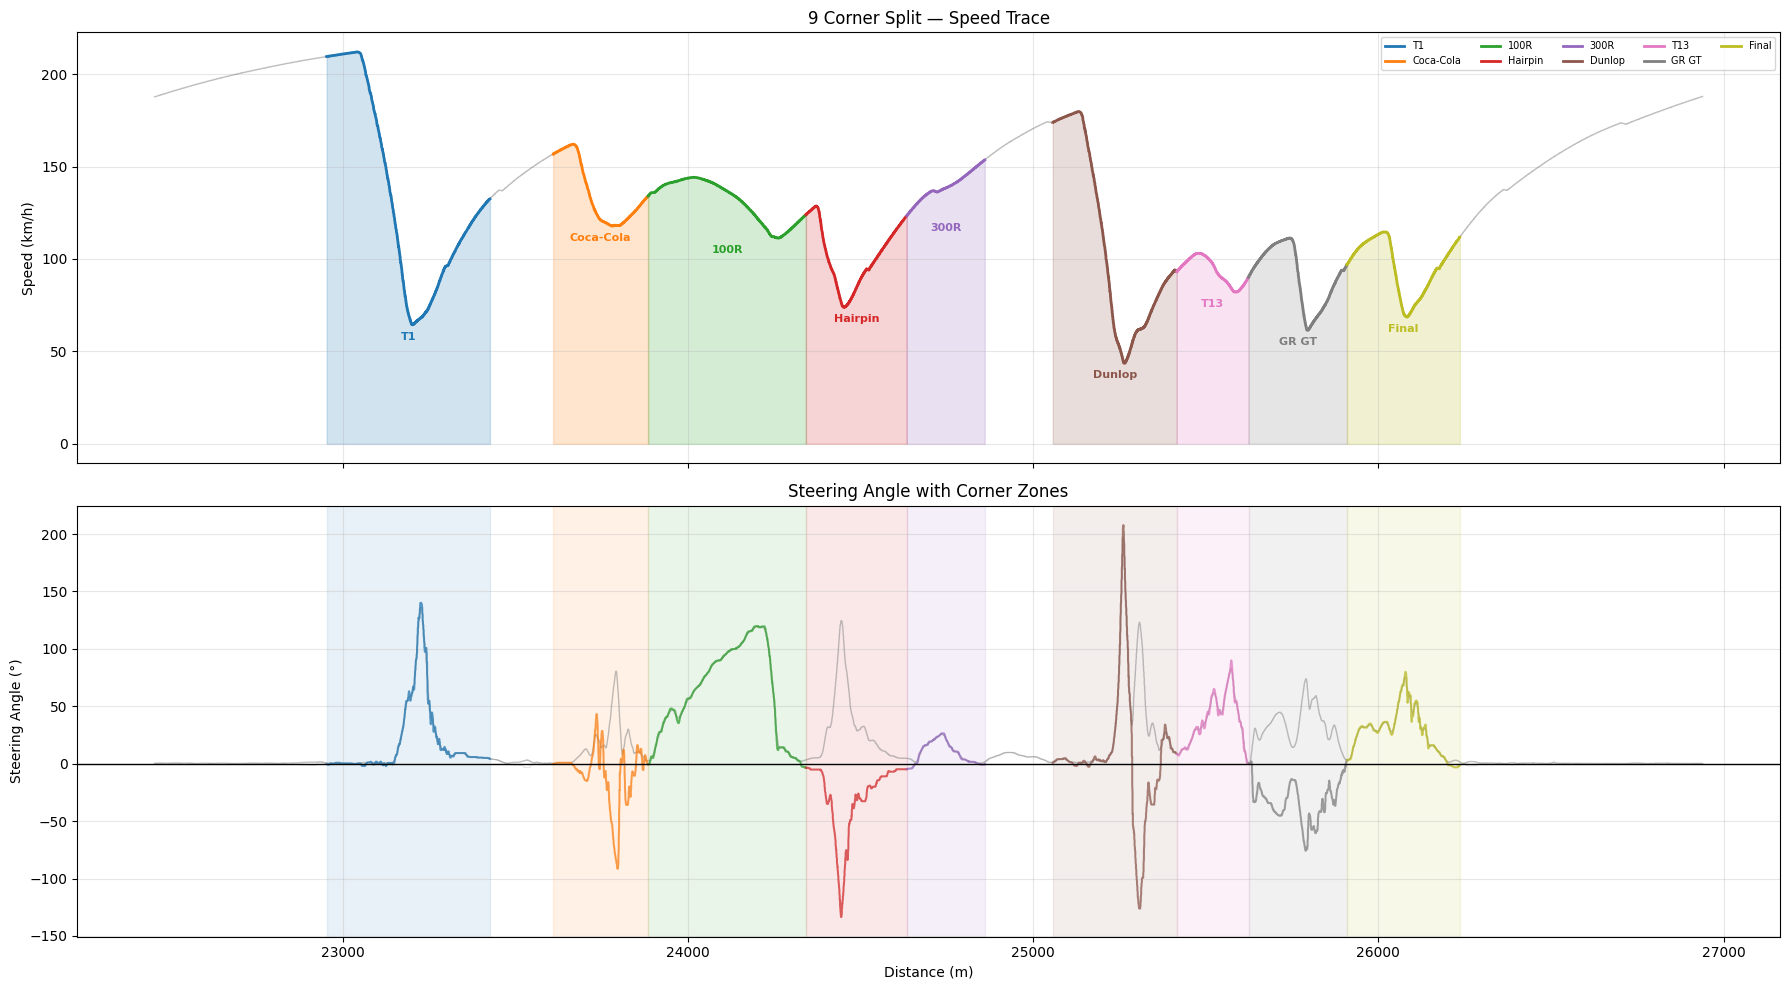

In [45]:
# === 9コーナー分割の検証チャート ===
fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)
colors9 = plt.cm.tab10(np.linspace(0, 1, 10))

# 速度トレース + コーナー区間
ax = axes[0]
ax.plot(df6c['Corr Dist'], df6c['Corr Speed'], color='gray', linewidth=1, alpha=0.5)
for i, (s, e) in enumerate(corners):
    seg = df6c.loc[s:e]
    ax.fill_between(seg['Corr Dist'], 0, seg['Corr Speed'], alpha=0.2, color=colors9[i])
    ax.plot(seg['Corr Dist'], seg['Corr Speed'], color=colors9[i], linewidth=2, label=fsw_names[i])
    mid_dist = (seg['Corr Dist'].iloc[0] + seg['Corr Dist'].iloc[-1]) / 2
    ax.text(mid_dist, seg['Corr Speed'].min() - 8, fsw_names[i], ha='center', fontsize=8,
            fontweight='bold', color=colors9[i])
ax.set_ylabel('Speed (km/h)')
ax.set_title('9 Corner Split — Speed Trace')
ax.legend(fontsize=7, ncol=5, loc='upper right')
ax.grid(True, alpha=0.3)

# ステアリング + コーナー区間
ax2 = axes[1]
ax2.plot(df6c['Corr Dist'], df6c['Steering Angle'], color='gray', linewidth=0.5, alpha=0.3)
ax2.plot(df6c['Corr Dist'], df6c['Steer_Smooth'], color='gray', linewidth=1, alpha=0.5)
for i, (s, e) in enumerate(corners):
    seg = df6c.loc[s:e]
    ax2.plot(seg['Corr Dist'], seg['Steering Angle'], color=colors9[i], linewidth=1.5, alpha=0.7)
    ax2.axvspan(seg['Corr Dist'].iloc[0], seg['Corr Dist'].iloc[-1], alpha=0.1, color=colors9[i])
ax2.axhline(y=0, color='black', linewidth=1)
ax2.set_ylabel('Steering Angle (°)')
ax2.set_xlabel('Distance (m)')
ax2.set_title('Steering Angle with Corner Zones')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()